# From one-axis twisting to GHZ — the full metrology protocol

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 10 — Quantum metrology protocols*

## 1. Introduction and motivation

[33 — spin squeezing by one-axis twisting](../ch10_quantum_metrology_protocols/33_spin_squeezing_one_axis_twisting.ipynb)
stopped where the squeezing parameter stops being useful: at a twisting angle of order $N^{-2/3}$, where the
uncertainty disc has been sheared into a thin ellipse and the Wineland parameter reaches $\xi_R^2\sim N^{-2/3}$. But the
quantum Fisher information of the same evolution keeps growing long after that, and at $\chi t=\pi/2$ it reaches
$F_Q=N^2$ — the Heisenberg limit, the largest value any state of $N$ qubits can have for a collective generator.

At that point the state is a **GHZ-like cat**, a coherent superposition of two coherent spin states pointing in
opposite directions. The same interaction that produces modest, robust squeezing at short times produces, when it is
left on until $\chi t=\pi/2$, the most fragile and most sensitive state of this chapter.

This notebook follows the protocol from beginning to end:

$$\vert+x\rangle^{\otimes N}
\;\xrightarrow[\text{twist}]{\;e^{-i\mu J_z^2}\;}\;\vert\psi(\mu)\rangle
\;\xrightarrow[\text{encode}]{\;e^{-i\theta\,\mathbf n\cdot\mathbf J}\;}\;\vert\psi_\theta\rangle
\;\xrightarrow[\text{read out}]{\;\text{parity}\;}\;\hat\theta ,$$

computes what each stage is worth, and then asks the question that decides whether any of it is usable: what does noise
do?

**Road map.**

* **Section 4.** The cat state at $\mu=\pi/2$ in closed form. $e^{-i\frac{\pi}{2}J_z^2}$ multiplies the amplitude of every
  $J_z$ eigenvalue $m$ by $e^{-i\frac{\pi}{2}m^2}$. For even $N$, $m$ is an integer and $e^{-i\frac{\pi}{2}m^2}$ takes
  only two values, which recombine into the identity and the parity operator — producing a cat along $\hat x$. For odd
  $N$, $m$ is a half-integer, the phase has period $4$ in $m$, and the cat comes out along $\hat y$. Both results are
  verified by fidelity with the predicted state.
* **Section 5.** The evolution implemented twice — diagonal phases and a circuit of commuting $ZZ$ gates — and shown
  identical, as in notebook 33.
* **Section 6.** The $3\times3$ QFI matrix evaluated at every twisting angle: its largest eigenvalue is $F_Q^{\max}(\mu)$
  and its eigenvector is the axis of the cat. We identify four features — $F_Q=N$ at $\mu=0$, the squeezing regime,
  where $F_Q$ lies above the Wineland bound $N/\xi_R^2$ by the factor $V_{\min}V_{\max}/(\vert\langle\mathbf J\rangle\vert^2/4)$
  of notebook 33, Eq. (26a) ($1.19$–$1.26$ at the optimum for $N=6$–$16$, tending to $3/2$), a plateau near $N^2/2$,
  and $F_Q=N^2$ at $\mu=\pi/2$ — and measure how each scales with $N$.
* **Section 7.** At $\mu=\pi/q$ the state is a superposition of $q$ coherent states. Husimi-$Q$ maps for
  $q=2,3,4,5,6,8$.
* **Section 8.** The readout. Encoding with the optimal generator and measuring the parity $\prod_qZ_q$ gives a fringe
  of period $2\pi/N$ whose classical Fisher information is exactly $N^2$ at every phase but the two fringe extrema;
  we then sample it and estimate $\theta$ by
  maximum likelihood, reaching $\Delta\theta=1/(N\sqrt M)$.
* **Sections 9–11.** Noise. The density tensor, Trotterised as (twist step, channel step); the quantum Fisher
  information from the symmetric logarithmic derivative; an exact derivation of the cat's exponential fragility,
  $F_Q=N^2(1-2p)^{2N}$ under dephasing in the cat basis; why the axis of the noise relative to the cat matters; and the
  optimal stopping time, which under the noise strengths studied here lies in the squeezing regime, well before the cat.
* **Section 12.** A final comparison of the four protocols of this chapter at equal $N$.
* **Section 13.** The readouts actually used. The classical Fisher information of spin counting and of parity along
  the whole evolution, compared with $F_Q$ at the same state: where each readout saturates the bound and where it
  falls short.
* **Section 14.** The interaction-based (echo) readout: twist, encode, un-twist, measure $J_x$. It reaches $F_Q$ at
  every twisting angle in the noiseless limit, and at the cat time it keeps that value under detection noise that
  destroys the parity signal.

### What you will learn

*Physics*

* why a quadratic spectrum $\chi m^2$ produces exact revivals, and why the revival at $\chi t=\pi/2$ is a two-component
  cat for even $N$ and a cat along a different axis for odd $N$;
* how to read the structure of a state off a $3\times3$ matrix: eigenvalue = metrological usefulness, eigenvector = the
  direction in which the state is "large";
* why a multi-component cat gives $F_Q\approx N^2/2$ rather than $N^2$;
* why the Heisenberg-limited state is exponentially fragile — the decoherence rate of an $N$-body coherence is $N$
  times the single-qubit rate — and what the optimal compromise looks like;
* how much of $F_Q$ the readouts actually used (spin counting, parity, the interaction-based echo) capture, and why
  un-twisting before the measurement protects the cat's signal against detection errors.

*Numerical methods*

* Gauss sums and the finite Fourier analysis of $e^{-i\frac{\pi}{2}m^2}$, checked by state fidelity;
* a Trotterised open-system evolution on a rank-$2N$ density tensor, with the unitary part exact;
* the mixed-state QFI matrix as a quadratic form over generator directions, from the SLD spectrum;
* classical Fisher information of an exact outcome distribution, and maximum-likelihood estimation from sampled data.

*Implementation practice*

* `jax.jit` on a whole noisy evolution step; static channel/qubit structure and traced parameters;
* reusing derived functions across notebooks instead of re-deriving them;
* working within a time budget: pure states to $N=16$, density tensors to $N=6$.

### Prerequisites
* [29 — quantum Fisher information](../ch10_quantum_metrology_protocols/29_quantum_fisher_information.ipynb):
  $F_Q=4\,\mathrm{Var}(G)$, the $3\times3$ QFI matrix, the standard quantum and Heisenberg limits;
* [30 — QFI from the SLD](../ch10_quantum_metrology_protocols/30_qfi_from_the_sld_prepare_encode_estimate.ipynb):
  the symmetric logarithmic derivative, the mixed-state QFI, the optimal measurement, maximum-likelihood estimation;
* [31 — Ramsey interferometry](../ch10_quantum_metrology_protocols/31_ramsey_interferometry.ipynb) and
  [32 — GHZ interferometry and the Heisenberg limit](../ch10_quantum_metrology_protocols/32_ghz_interferometry_heisenberg_limit.ipynb):
  the two reference protocols; Section 3 recalls the one formula we need from each;
* [33 — spin squeezing by one-axis twisting](../ch10_quantum_metrology_protocols/33_spin_squeezing_one_axis_twisting.ipynb):
  the Hamiltonian, the exact propagator, the squeezing parameters;
* [07 — density matrices and quantum channels](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb):
  density tensors, Kraus channels.

**What comes next.** [35 — scrambling a metrological probe](../ch10_quantum_metrology_protocols/35_oat_plus_haar_scrambling.ipynb)
asks what is left of these probes after a unitary scrambles them.

**Conventions.** $J_a=\tfrac12\sum_q\sigma^a_q$; $\vert0\rangle$ is the $+1$ eigenstate of $Z$; the twisting angle is
$\mu=\chi t$ and the propagator is $e^{-i\mu J_z^2}$. SQL $=N$, Heisenberg limit $=N^2$.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels; a call needs (axes + new labels) <= 52: apply_gate on a state
                                 # N + k <= 52 (N <= 51 for k = 1), apply_gate_dm 2N + k <= 52 (N <= 25 for k = 1, 2),
                                 # apply_kraus_dm 2N + 2k + 1 <= 52 (N <= 24 for k = 1, N <= 23 for k = 2)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Engine recap and notebook helpers

From the engine: the state constructors, `apply_gate` and `apply_kraus_dm`, the two-qubit rotation `rzz`, the Kraus
channels, `spin_moments`, `spin_squeezing`, `collective_dense`, `qfi_mixed`, `oat_evolve` and `sample_bitstrings`.
The symmetric-logarithmic-derivative routines of notebook 30 and the Husimi-$Q$ machinery of notebook 33 are
re-created below.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP: the functions of quantum_engine.py (SmoQ.jax) used in this notebook.
# Each one is derived, with its mathematics and an independent check, in notebook 08b
# (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z
SDG = S.conj().T
ZZ = jnp.kron(Z, Z)
def rpp(theta, PP):
    """Two-qubit Pauli rotation  exp(-i theta PP/2)  for any product PP of two Pauli matrices (XX, YY, ZZ, XY, ...).

    Because (P x Q)^2 = 1 the same closed form as for single-qubit rotations holds:
        exp(-i theta PP/2) = cos(theta/2) 1_4 - i sin(theta/2) PP.
    These are the native entangling gates of trapped ions (XX) and the building blocks
    of Trotterised spin-chain evolution.
    """
    return jnp.cos(theta / 2) * jnp.eye(4, dtype=CDTYPE) - 1j * jnp.sin(theta / 2) * PP

def rzz(theta):
    """exp(-i theta Z(x)Z / 2)  -- diagonal: diag(e^{-i t/2}, e^{+i t/2}, e^{+i t/2}, e^{-i t/2})."""
    return rpp(theta, ZZ)


# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)

def apply_kraus_dm(rho, kraus, qubits):
    """Quantum channel in Kraus form:  rho -> sum_m K_m rho K_m^dagger,   sum_m K_m^dag K_m = 1.

    EINSUM TRANSLATION  (N=2, channel on qubit 0; g = Kraus index, summed!)
        "gea,gfc,abcd->ebfd"   with operands  K, K^*, rho      [a=ket0, b=ket1, c=bra0, d=bra1; e, f = new ket0, bra0]
    All Kraus branches are summed INSIDE one einsum -- no Python loop over m.
    `kraus` has shape (M, 2^k, 2^k).
    """
    qubits = tuple(int(q) for q in qubits)
    k, N = len(qubits), rho.ndim // 2
    K = jnp.asarray(kraus, dtype=rho.dtype).reshape((-1,) + (2,) * (2 * k))
    n = rho.ndim
    inp = list(_LETTERS[:n])
    new_k, new_b, m = _LETTERS[n:n + k], _LETTERS[n + k:n + 2 * k], _LETTERS[n + 2 * k]
    out = inp.copy()
    for a, b, q in zip(new_k, new_b, qubits):
        out[q], out[N + q] = a, b
    ket_old = "".join(inp[q] for q in qubits)
    bra_old = "".join(inp[N + q] for q in qubits)
    sub = f"{m}{new_k}{ket_old},{m}{new_b}{bra_old},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, K, jnp.conj(K), rho)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)

def ghz_state(N):
    """GHZ state (|0...0> + |1...1>)/sqrt(2): two non-zero entries of the rank-N tensor."""
    psi = jnp.zeros((2,) * N, dtype=CDTYPE)
    return psi.at[(0,) * N].set(1 / jnp.sqrt(2.0)).at[(1,) * N].set(1 / jnp.sqrt(2.0))

def to_dm(psi):
    """Pure state -> density TENSOR  rho[s..; s'..] = psi[s..] psi^*[s'..]   (rank 2N).
    An outer product: einsum "ab,AB->abAB" -- here via the equivalent tensordot(axes=0)."""
    return jnp.tensordot(psi, jnp.conj(psi), axes=0)

def dm_matrix(rho):
    """View a rank-2N density tensor as an ordinary 2^N x 2^N matrix (a reshape, no copy of meaning)."""
    d = int(round(np.sqrt(rho.size)))
    return rho.reshape(d, d)


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def purity(rho_mat):
    """Tr(rho^2): 1 for pure states, 1/d for the maximally mixed state in dimension d."""
    return jnp.real(jnp.trace(rho_mat @ rho_mat))


# ----------------------------------------------------------------------------
# 6. Measurements (Born rule, collapse, sampling)
# ----------------------------------------------------------------------------
_BASIS_ROT = {"Z": I2, "X": H, "Y": H @ SDG}  # U maps the eigenbasis of the Pauli to |0>,|1>:  P = U^dag Z U
def sample_bitstrings(key, psi, shots, bases=None):
    """Sample `shots` outcomes of measuring ALL qubits (no collapse bookkeeping needed).

    MATH   p(s) = |psi[s]|^2 ; optional per-qubit bases string like 'XZY' rotates first.
    IMPLEMENTATION   `jax.random.categorical` draws flat indices from log-probabilities; the bits are
    unpacked with shifts:  s_q = (i >> (N-1-q)) & 1   (qubit 0 = most significant bit).
    Returns an int array of shape (shots, N).
    """
    N = psi.ndim
    if bases is not None:
        for q, b in enumerate(bases):
            psi = apply_gate(psi, _BASIS_ROT[b], [q])
    logp = jnp.log(jnp.clip(jnp.abs(psi.reshape(-1)) ** 2, 1e-300, None))
    idx = jax.random.categorical(key, logp, shape=(shots,))
    return (idx[:, None] >> jnp.arange(N - 1, -1, -1)[None, :]) & 1


# ----------------------------------------------------------------------------
# 7. Noise channels (Kraus operators): density matrix and quantum-trajectory forms
# ----------------------------------------------------------------------------
def kraus_depolarizing(p):
    """Depolarising channel  rho -> (1-p) rho + (p/3)(X rho X + Y rho Y + Z rho Z).
    Kraus: sqrt(1-p) 1, sqrt(p/3) X, sqrt(p/3) Y, sqrt(p/3) Z.   Bloch vector shrinks by 1 - 4p/3."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p / 3) * X, jnp.sqrt(p / 3) * Y, jnp.sqrt(p / 3) * Z])

def kraus_dephasing(p):
    """Dephasing (phase-flip) channel  rho -> (1-p) rho + p Z rho Z : coherences rho_01 -> (1-2p) rho_01."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p) * Z])

def kraus_bit_flip(p):
    """Bit-flip channel  rho -> (1-p) rho + p X rho X."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p) * X])

def kraus_amplitude_damping(g):
    """Amplitude damping (T1 decay |1> -> |0> with probability g):
        K0 = [[1,0],[0,sqrt(1-g)]]   (no decay -- but the amplitude of |1> shrinks: 'no click' is information)
        K1 = [[0,sqrt(g)],[0,0]]     (decay event = sqrt(g) sigma^-)."""
    K0 = jnp.array([[1, 0], [0, jnp.sqrt(1 - g)]], dtype=CDTYPE)
    K1 = jnp.array([[0, jnp.sqrt(g)], [0, 0]], dtype=CDTYPE)
    return jnp.stack([K0, K1])


# ----------------------------------------------------------------------------
# 11. Collective spins, spin squeezing, quantum Fisher information
# ----------------------------------------------------------------------------
def apply_collective(psi, P, qubits=None):
    """(sum_q P_q)|psi> for a single-qubit operator P -- N einsums, O(N 2^N).  Note: NO factor 1/2 here;
    the collective spin is J_a = (1/2) sum_q sigma^a_q."""
    qubits = range(psi.ndim) if qubits is None else qubits
    out = jnp.zeros_like(psi)
    for q in qubits:
        out = out + apply_gate(psi, P, [q])
    return out

def qfi_mixed(rho_mat, G_mat, tol=1e-12):
    """QFI of a MIXED state (symmetric-logarithmic-derivative formula), rho = sum_m l_m |m><m|:
        F_Q = 2 sum_{m,n : l_m+l_n>0} (l_m - l_n)^2/(l_m + l_n) |<m|G|n>|^2       (G = generator, e.g. J).
    Reduces to 4 Var(G) for pure states.  Dense eigendecomposition -> use on small / reduced states."""
    lam, v = jnp.linalg.eigh(rho_mat)
    G = v.conj().T @ G_mat @ v
    num = (lam[:, None] - lam[None, :]) ** 2
    den = lam[:, None] + lam[None, :]
    return 2 * jnp.sum(jnp.where(den > tol, num / jnp.where(den > tol, den, 1.0), 0.0) * jnp.abs(G) ** 2)

def collective_dense(P, n):
    """Dense J = (1/2) sum_q P_q on n qubits (input of `qfi_mixed`), built from the matrix-free action
    on the basis vectors (vmap), exactly like `dense_hamiltonian`."""
    eye = jnp.eye(2 ** n, dtype=CDTYPE).reshape((2 ** n,) + (2,) * n)
    return 0.5 * jax.vmap(lambda e: apply_collective(e, P).reshape(-1))(eye).T

def spin_moments(psi):
    """Mean collective spin <J_a> (shape 3) and symmetrised covariance matrix
        C_ab = (1/2)<J_a J_b + J_b J_a> - <J_a><J_b>          (shape 3x3).
    Trick: |phi_a> = J_a|psi>  =>  <J_a J_b> = <phi_a|phi_b>, and its real part is the symmetrised moment."""
    phis = [0.5 * apply_collective(psi, P) for P in (X, Y, Z)]
    mean = jnp.stack([jnp.real(jnp.vdot(psi, p)) for p in phis])
    second = jnp.stack([jnp.stack([jnp.real(jnp.vdot(a, b)) for b in phis]) for a in phis])
    return mean, second - jnp.outer(mean, mean)

def spin_squeezing(psi):
    """Wineland spin-squeezing parameter
        xi^2_R = N * min_{n_perp} Var(J_{n_perp}) / |<J>|^2 .
    xi^2 < 1: phase sensitivity beyond the standard quantum limit (and the state is entangled).
    Implementation: project the 3x3 covariance onto the plane perpendicular to the mean spin and take
    the smaller eigenvalue of the resulting 2x2 matrix."""
    N = psi.ndim
    mean, cov = spin_moments(psi)
    L = jnp.linalg.norm(mean)
    n = mean / L
    a = jnp.where(jnp.abs(n[2]) < 0.9, jnp.array([0.0, 0.0, 1.0]), jnp.array([1.0, 0.0, 0.0]))
    e1 = jnp.cross(n, a)
    e1 = e1 / jnp.linalg.norm(e1)
    e2 = jnp.cross(n, e1)
    B = jnp.stack([e1, e2])
    vmin = jnp.linalg.eigvalsh(B @ cov @ B.T)[0]
    return N * vmin / L ** 2

def oat_evolve(psi, chi_t):
    """One-axis twisting  exp(-i chi t J_z^2)  applied EXACTLY.
    J_z is diagonal in the computational basis with eigenvalue m(s) = sum_q (1/2 - s_q), so the evolution
    multiplies each amplitude by a phase exp(-i chi t m^2): O(2^N), no Trotter error, no gates.
    m(s) is assembled by BROADCASTING N arrays of shape (1,..,2,..,1) -- a tensor-network-free way of
    writing a sum over sites.   [Note: chi sum_{i<j} Z_i Z_j = 2 chi J_z^2 - chi N/2.]"""
    N = psi.ndim
    m = sum(jnp.array([0.5, -0.5]).reshape([2 if a == q else 1 for a in range(N)]) for q in range(N))
    return psi * jnp.exp(-1j * chi_t * m ** 2)


In [3]:
# ==============================================================================
# PLOT STYLE + small helpers used throughout this notebook
# ==============================================================================
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]   # colour-blind-friendly, fixed order
MARKERS = ["o", "s", "^", "D", "v", "P"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})


def max_abs(a):
    """Largest absolute entry of an array, as a Python float."""
    return float(jnp.max(jnp.abs(jnp.asarray(a))))


def pauli_direction(n):
    """Single-qubit matrix n.sigma = n_x X + n_y Y + n_z Z for a unit vector n."""
    n = jnp.asarray(n, dtype=CDTYPE)
    return n[0] * X + n[1] * Y + n[2] * Z


def collective_rotation(psi, angle, n):
    """exp(-i angle n.J) with n.J = (1/2) sum_q (n.sigma)_q, applied to a pure state.

    MATH   n.J is a SUM of commuting single-qubit terms, so the exponential factorises EXACTLY:
               exp(-i angle n.J) = prod_q [ cos(angle/2) 1 - i sin(angle/2) (n.sigma) ]_q .
           (Using (n.sigma)^2 = 1 for a unit vector n.)
    COST   N single-qubit einsums, O(N 2^N).   JAX: `n` and `angle` are traced, qubit indices static.
    """
    c, s = jnp.cos(angle / 2), jnp.sin(angle / 2)
    U = c * I2 - 1j * s * pauli_direction(n)
    for q in range(psi.ndim):
        psi = apply_gate(psi, U, [q])
    return psi


def qfi_matrix(psi):
    """3x3 QFI matrix of a PURE state over the collective generators (J_x, J_y, J_z)  [notebook 29].

    MATH   Fcal[a,b] = 4 * ( (1/2)<J_a J_b + J_b J_a> - <J_a><J_b> );   F_Q(n) = n^T Fcal n .
    COST   three matrix-free applications of J_a: O(N 2^N).
    """
    _, cov = spin_moments(psi)
    return 4.0 * cov


def optimal_direction(psi):
    """Best generator direction and the QFI it delivers: (F_max, n_opt) = top eigenpair of Fcal."""
    w, v = jnp.linalg.eigh(qfi_matrix(psi))
    return w[-1], v[:, -1]


def fix_sign(n):
    """Fix the arbitrary global sign of an eigenvector: make its largest component positive."""
    n = np.asarray(n)
    return n * np.sign(n[int(np.argmax(np.abs(n)))])


print("helpers ready")

helpers ready


## 3. The protocol, and what we already know

### 3.1 The pipeline

Every experiment in this chapter has the same three stages, and the notebooks differ only in how they fill them in.

| stage | Ramsey (nb 31) | GHZ (nb 32) | this notebook |
|---|---|---|---|
| prepare | $\vert+x\rangle^{\otimes N}$ | $\left(\vert0\rangle^{\otimes N}+\vert1\rangle^{\otimes N}\right)/\sqrt2$ | $e^{-i\mu J_z^2}\vert+x\rangle^{\otimes N}$ |
| encode | $e^{-i\theta J_z}$ | $e^{-i\theta J_z}$ | $e^{-i\theta\,\mathbf n\cdot\mathbf J}$, $\mathbf n$ optimal |
| read out | population imbalance | parity in the $X$ basis | parity in the $Z$ basis |
| ideal $F_Q$ | $N$ | $N^2$ | $N$ to $N^2$, depending on $\mu$ |

Three facts are carried over, each stated here in the form we need and derived in the notebook indicated.

**(a) Quantum Cramér–Rao bound** (notebook 29). For $M$ repetitions of a protocol whose prepared state has quantum
Fisher information $F_Q$ with respect to the encoding generator,

$$\Delta\theta\;\ge\;\frac{1}{\sqrt{M\,F_Q}},$$

with equality for the optimal measurement. For a pure state and a unitary encoding $F_Q=4\,\mathrm{Var}(G)$, and for a
collective generator $G=\mathbf n\cdot\mathbf J$ this is the quadratic form $F_Q(\mathbf n)=\mathbf n^{\mathsf T}\mathcal F\mathbf n$
with $\mathcal F_{ab}=4C_{ab}$; the best direction is the top eigenvector of $\mathcal F$.

**(b) Ramsey and GHZ** (notebooks 31, 32). A coherent spin state reaches $\Delta\theta=1/\sqrt{NM}$ — the standard
quantum limit; a GHZ state encoded with $J_z$ and read out with the parity $\prod_qX_q$ reaches $\Delta\theta=1/(N\sqrt M)$
— the Heisenberg limit. The GHZ fringe has period $2\pi/N$, so the phase is only determined modulo $2\pi/N$ unless one
already knows it that well.

**(c) One-axis twisting** (notebook 33; Kitagawa and Ueda 1993). $H=\chi J_z^2$ is diagonal in the computational
basis: with $m(s)=\sum_q(\tfrac12-s_q)$,

$$e^{-i\mu J_z^2}\,\psi[s]=e^{-i\mu\,m(s)^2}\,\psi[s],$$

which is the engine's `oat_evolve` — exact, $O(2^N)$, no Trotter error. Equivalently it is a circuit of $N(N-1)/2$
commuting $R_{ZZ}(\mu)$ gates times a global phase, since $\sum_{i<j}Z_iZ_j=2J_z^2-N/2$. Starting from
$\vert+x\rangle^{\otimes N}$ the state squeezes, with the best Wineland parameter (Wineland *et al.* 1994)
$\xi_R^2$ at $\mu_{\rm opt}\sim N^{-2/3}$, and then oversqueezes.

### 3.2 Why something special must happen at $\mu=\pi/2$

The spectrum of $J_z^2$ is $\{m^2\}$ with $m$ integer ($N$ even) or half-integer ($N$ odd). For integer $m$, $m^2$ is an
integer, so $e^{-i\mu m^2}$ is $2\pi$-periodic in $\mu$: the evolution has an exact revival at $\mu=2\pi$, and the
dynamics never dephases permanently. At the *half* period, $\mu=\pi$, one has $e^{-i\pi m^2}=(-1)^{m^2}=(-1)^m$, a phase
that depends on $m$ only through its parity — this is a *unitary that acts like a single collective rotation*, so the
state at $\mu=\pi$ is again a coherent spin state. At the quarter period, $\mu=\pi/2$, the phase $e^{-i\frac{\pi}{2}m^2}$
takes exactly **two** values, and a two-valued function of $m$ is a superposition of exactly two "rotation-like"
operators. That is the origin of the cat. Atomic cat states generated by a $J_z^2$-type interaction were analysed by
Agarwal, Puri and Singh (1997), and Mølmer and Sørensen (1999) proposed the same quadratic evolution, about $\hat x$,
to prepare GHZ states of trapped ions.

Section 4 turns this counting argument into an exact identity.

## 4. The cat state at $\mu=\pi/2$

### 4.1 Even $N$: a cat along $\hat x$

For $N$ even, $m=\tfrac12(N-2k)=\tfrac{N}{2}-k$ is an **integer**. For integer $m$,

$$m^2\equiv\begin{cases}0\pmod 4,& m\text{ even}\\ 1\pmod 4,& m\text{ odd}\end{cases}
\qquad\Longrightarrow\qquad
e^{-i\frac{\pi}{2}m^2}=\begin{cases}1,& m\text{ even}\\ -i,& m\text{ odd.}\end{cases}$$

A function of $m$ taking the value $u$ on even $m$ and $v$ on odd $m$ is $\tfrac{u+v}{2}+\tfrac{u-v}{2}(-1)^m$. With
$u=1$, $v=-i$,

$$e^{-i\frac{\pi}{2}m^2}=\frac{1-i}{2}+\frac{1+i}{2}\,(-1)^m
 =\frac{e^{-i\pi/4}}{\sqrt2}+\frac{e^{+i\pi/4}}{\sqrt2}\,(-1)^m . \tag{1}$$

Now identify the operator $(-1)^{J_z}$. With $m=\tfrac{N}{2}-k$ and $k$ = number of qubits in $\vert1\rangle$,

$$(-1)^m=(-1)^{N/2}(-1)^{-k}=(-1)^{N/2}(-1)^{k}=(-1)^{N/2}\prod_{q}Z_q,$$

because $\prod_qZ_q$ has eigenvalue $(-1)^k$ on the basis state with $k$ ones. Substituting into Eq. (1),

$$e^{-i\frac{\pi}{2}J_z^2}
 =\frac{e^{-i\pi/4}}{\sqrt2}\,\mathbb 1+\frac{e^{+i\pi/4}}{\sqrt2}\,(-1)^{N/2}\prod_qZ_q . \tag{2}$$

Equation (2) is an operator identity for even $N$: the twisting propagator at $\mu=\pi/2$ is a superposition of the
identity and a single collective spin flip. Applying it to $\vert+x\rangle^{\otimes N}$ and using
$\prod_qZ_q\vert+x\rangle^{\otimes N}=\vert-x\rangle^{\otimes N}$ (each $Z$ maps $\vert+x\rangle$ to $\vert-x\rangle$):

$$\boxed{\;e^{-i\frac{\pi}{2}J_z^2}\vert+x\rangle^{\otimes N}
 =\frac{1}{\sqrt2}\left(e^{-i\pi/4}\vert+x\rangle^{\otimes N}
  +(-1)^{N/2}e^{+i\pi/4}\vert-x\rangle^{\otimes N}\right)\;}\qquad(N\text{ even}). \tag{3}$$

This is a **GHZ state in the $x$ basis**: two coherent spin states pointing at opposite poles of the $x$ axis, in a
coherent superposition with a relative phase $\pm i$. Up to the local basis change that maps $\hat x$ to $\hat z$
(a Hadamard on every qubit), it is exactly the state of notebook 32.

### 4.2 Odd $N$: a cat along $\hat y$

For $N$ odd, $m$ is a **half-integer**: write $m=\ell+\tfrac12$ with $\ell$ an integer. Then

$$m^2=\ell^2+\ell+\tfrac14=\ell(\ell+1)+\tfrac14,$$

and $\ell(\ell+1)$ is the product of two consecutive integers, hence always even. So $m^2-\tfrac14$ is an even integer
and $e^{-i\frac{\pi}{2}m^2}=e^{-i\pi/8}(-1)^{\ell(\ell+1)/2}$ again takes only two values, $\pm e^{-i\pi/8}$. But which
sign occurs follows the pattern $+,-,-,+$ for $m=\tfrac12,\tfrac32,\tfrac52,\tfrac72$, which is not the parity of $m$
(and $(-1)^m=e^{i\pi m}=\pm i$ is not even a sign for half-integer $m$), so the decomposition of Eq. (1) does not
carry over. Instead, examine the periodicity. For half-integer $m$,

$$\frac{e^{-i\frac{\pi}{2}(m+2)^2}}{e^{-i\frac{\pi}{2}m^2}}=e^{-i\frac{\pi}{2}(4m+4)}=e^{-2\pi i m}e^{-2\pi i}=-1,$$

using $e^{-2\pi i m}=-1$ for half-integer $m$. So the phase has period $4$ in $m$ and changes sign under $m\to m+2$. A
function with these two properties can be written with only the two "odd" Fourier modes of period $4$,

$$e^{-i\frac{\pi}{2}m^2}=c_+e^{+i\frac{\pi}{2}m}+c_-e^{-i\frac{\pi}{2}m}.$$

Fixing $c_\pm$ from $m=\pm\tfrac12$: both give $e^{-i\pi/8}$, and the two equations
$c_+e^{i\pi/4}+c_-e^{-i\pi/4}=e^{-i\pi/8}$ and $c_+e^{-i\pi/4}+c_-e^{i\pi/4}=e^{-i\pi/8}$ force $c_+=c_-=c$ and then
$2c\cos(\pi/4)=e^{-i\pi/8}$, i.e. $c=e^{-i\pi/8}/\sqrt2$. (Check at $m=\tfrac32$: the left side is
$e^{-i9\pi/8}=e^{+i7\pi/8}$ and the right side is $2c\cos(3\pi/4)=-e^{-i\pi/8}=e^{i7\pi/8}$.) Therefore

$$e^{-i\frac{\pi}{2}J_z^2}=\frac{e^{-i\pi/8}}{\sqrt2}\left(e^{+i\frac{\pi}{2}J_z}+e^{-i\frac{\pi}{2}J_z}\right)
\qquad(N\text{ odd}). \tag{4}$$

The two terms are ordinary rotations about $\hat z$ by $\mp\pi/2$, which carry $\hat x$ to $\mp\hat y$:

$$e^{-i\frac{\pi}{2}J_z}\vert+x\rangle^{\otimes N}=e^{-iN\pi/4}\vert+y\rangle^{\otimes N},\qquad
  e^{+i\frac{\pi}{2}J_z}\vert+x\rangle^{\otimes N}=e^{+iN\pi/4}\vert-y\rangle^{\otimes N},$$

since $e^{-i\frac{\pi}{4}\sigma^z}\vert+x\rangle=e^{-i\pi/4}(\vert0\rangle+i\vert1\rangle)/\sqrt2=e^{-i\pi/4}\vert+y\rangle$.
Hence

$$\boxed{\;e^{-i\frac{\pi}{2}J_z^2}\vert+x\rangle^{\otimes N}
 =\frac{e^{-i\pi/8}}{\sqrt2}\left(e^{+iN\pi/4}\vert-y\rangle^{\otimes N}+e^{-iN\pi/4}\vert+y\rangle^{\otimes N}\right)\;}
 \qquad(N\text{ odd}). \tag{5}$$

Same structure, different axis: for odd $N$ the cat lies along $\hat y$, rotated by $90^\circ$ from the even case. The
reason is the half-integer spectrum — the same reason a spin-$1/2$ needs a $4\pi$ rotation to return to itself.

### 4.3 Fidelity and global phase of Eqs. (3) and (5)

Equations (3) and (5) are exact statements about a specific state vector. We check them by fidelity,
$F=\vert\langle\psi_{\rm predicted}\vert\psi_{\rm simulated}\rangle\vert^2$, which must be $1$ to machine precision —
and we also check the overlap itself, which must be exactly $1$, i.e. even the *global phase* of Eqs. (3) and (5) is
right.

In [4]:
# ==============================================================================
# STEP 1: the predicted cat state, and its fidelity with the simulated one
# ==============================================================================
def predicted_cat(N):
    """The right-hand side of Eq. (3) (N even) or Eq. (5) (N odd), built as a product-state superposition.

    MATH  N even:  (e^{-i pi/4} |+x>^N + (-1)^{N/2} e^{+i pi/4} |-x>^N)/sqrt(2)
          N odd :  (e^{-i pi/8}/sqrt2)( e^{+i N pi/4} |-y>^N + e^{-i N pi/4} |+y>^N )
    The engine's product_state uses 'r' for the +1 eigenstate of Y and 'l' for the -1 one.
    """
    if N % 2 == 0:
        return (jnp.exp(-1j * jnp.pi / 4) * product_state("+" * N)
                + (-1) ** (N // 2) * jnp.exp(1j * jnp.pi / 4) * product_state("-" * N)) / jnp.sqrt(2.0)
    return jnp.exp(-1j * jnp.pi / 8) / jnp.sqrt(2.0) * (
        jnp.exp(1j * N * jnp.pi / 4) * product_state("l" * N)
        + jnp.exp(-1j * N * jnp.pi / 4) * product_state("r" * N))


print(f"{'N':>4s} {'parity':>7s} | {'fidelity with Eq. (3)/(5)':>26s} {'overlap (with phase)':>26s} "
      f"{'F_Q max':>9s} {'N^2':>6s} {'cat axis':>22s}")
for N in range(4, 12):
    psi_cat = oat_evolve(product_state("+" * N), np.pi / 2)
    pred = predicted_cat(N)
    ov = complex(jnp.vdot(pred, psi_cat))
    fmax, nopt = optimal_direction(psi_cat)
    print(f"{N:4d} {'even' if N % 2 == 0 else 'odd':>7s} | {abs(ov) ** 2:26.14f} "
          f"{f'{ov.real:+.10f}{ov.imag:+.1e}i':>26s} {float(fmax):9.4f} {N ** 2:6d} "
          f"{np.array2string(fix_sign(nopt), precision=3, floatmode='fixed'):>22s}")
    assert abs(abs(ov) ** 2 - 1.0) < 1e4 * TOL
    assert abs(ov - 1.0) < 1e4 * TOL                     # the global phase too: a fidelity check alone would miss it
    assert abs(float(fmax) - N ** 2) < 1e-6 * N ** 2
    axis = np.array([1.0, 0.0, 0.0]) if N % 2 == 0 else np.array([0.0, 1.0, 0.0])
    assert abs(abs(float(np.dot(np.array(nopt), axis))) - 1.0) < 1e-6   # cat axis: x for even N, y for odd N

   N  parity |  fidelity with Eq. (3)/(5)       overlap (with phase)   F_Q max    N^2               cat axis


   4    even |           1.00000000000000     +1.0000000000+6.1e-17i   16.0000     16    [1.000 0.000 0.000]


   5     odd |           1.00000000000000     +1.0000000000+7.6e-17i   25.0000     25 [-0.000e+00  1.000e+00  2.350e-16]


   6    even |           1.00000000000000     +1.0000000000+9.2e-17i   36.0000     36    [1.000 0.000 0.000]


   7     odd |           1.00000000000000     +1.0000000000+1.2e-16i   49.0000     49 [0.000e+00 1.000e+00 1.110e-16]


   8    even |           1.00000000000000     +1.0000000000+1.2e-16i   64.0000     64    [1.000 0.000 0.000]


   9     odd |           1.00000000000000     +1.0000000000+2.2e-16i   81.0000     81 [0.000e+00 1.000e+00 3.331e-16]


  10    even |           0.99999999999999     +1.0000000000+1.5e-16i  100.0000    100    [1.000 0.000 0.000]


  11     odd |           0.99999999999999     +1.0000000000+2.6e-16i  121.0000    121 [-0.000e+00  1.000e+00  2.220e-16]


Every fidelity is $1$ to fourteen digits, and every overlap is $1+O(10^{-16})i$: Eqs. (3) and (5) reproduce the simulated state
*including* its global phase, and the cell asserts the overlap itself as well as its modulus. The quantum Fisher
information in the optimal direction is exactly $N^2$ — the Heisenberg limit — and the optimal direction read off the
$3\times3$ QFI matrix is $\hat x$ for even $N$ and $\hat y$ for odd $N$ (also asserted), exactly the axes the
derivation predicts.

> **Physics insight.** Equation (2) says that at $\mu=\pi/2$ the many-body propagator collapses to
> $\alpha\mathbb 1+\beta\prod_qZ_q$ — a superposition of "do nothing" and "flip every spin". This is why the resulting
> entanglement involves all $N$ qubits but is *of the simplest possible kind*: the two branches are orthogonal product
> states on both sides of any cut, so the state has Schmidt rank $2$ with equal weights across every bipartition, i.e.
> exactly one bit of entanglement entropy — far below the $\min(N_A,N_B)$ bits a cut allows — while carrying $F_Q=N^2$. Metrological usefulness is not
> entanglement entropy (notebook 29, Section 13).

## 5. The same state from a circuit of commuting $ZZ$ gates

Nothing above depends on how the propagator is implemented, but the experiment does. Using
$J_z^2=\tfrac{N}{4}+\tfrac12\sum_{i<j}Z_iZ_j$,

$$e^{-i\mu J_z^2}=e^{-i\mu N/4}\prod_{i<j}e^{-i\frac{\mu}{2}Z_iZ_j}=e^{-i\mu N/4}\prod_{i<j}R_{ZZ}(\mu)_{ij},$$

with $R_{ZZ}(\theta)=e^{-i\theta Z\otimes Z/2}$ the engine's `rzz`. All the $Z_iZ_j$ are diagonal, hence mutually
commuting, so the factorisation is an identity: the Trotter error is exactly zero and the gate order is irrelevant.
At $\mu=\pi/2$ each gate is $R_{ZZ}(\pi/2)=\left(\mathbb 1-iZ\otimes Z\right)/\sqrt2$, a maximally entangling
two-qubit gate — the cat is built from $N(N-1)/2$ of them.

In [5]:
# ==============================================================================
# STEP 2: diagonal evolution versus the ZZ-gate circuit
# ==============================================================================
def oat_circuit(psi, mu):
    """exp(-i mu J_z^2) as a circuit of N(N-1)/2 commuting ZZ gates plus a global phase.

    MATH   exp(-i mu J_z^2) = exp(-i mu N/4) prod_{i<j} rzz(mu)_{ij},   rzz(th) = exp(-i th ZZ/2).
    COST   O(N^2) gates of O(2^N) each;  the diagonal version costs O(2^N) in total.
    ERROR  exactly zero -- the terms commute, so the factorisation is an identity, not a Trotter step.
    """
    N = psi.ndim
    gate = rzz(mu)
    for i in range(N):
        for j in range(i + 1, N):
            psi = apply_gate(psi, gate, [i, j])
    return jnp.exp(-1j * mu * N / 4) * psi


print(f"{'N':>4s} {'mu':>8s} | {'max |diagonal - circuit|':>25s} {'fidelity circuit vs Eq. (3)/(5)':>32s}")
for N in (5, 8, 9):
    for mu in (0.3, np.pi / 4, np.pi / 2):
        psi0 = product_state("+" * N)
        e = max_abs(oat_evolve(psi0, mu) - oat_circuit(psi0, mu))
        is_cat = abs(mu - np.pi / 2) < 1e-12
        f = (f"{abs(complex(jnp.vdot(predicted_cat(N), oat_circuit(psi0, mu)))) ** 2:.14f}"
             if is_cat else "-  (not the cat time)")
        print(f"{N:4d} {mu:8.5f} | {e:25.3e} {f:>32s}")
        assert e < 1e4 * TOL

   N       mu |  max |diagonal - circuit|  fidelity circuit vs Eq. (3)/(5)


   5  0.30000 |                 1.678e-16            -  (not the cat time)
   5  0.78540 |                 1.388e-17            -  (not the cat time)
   5  1.57080 |                 1.495e-16                 1.00000000000000


   8  0.30000 |                 9.646e-17            -  (not the cat time)
   8  0.78540 |                 3.104e-17            -  (not the cat time)


   8  1.57080 |                 8.520e-17                 1.00000000000000


   9  0.30000 |                 1.538e-16            -  (not the cat time)
   9  0.78540 |                 5.551e-17            -  (not the cat time)
   9  1.57080 |                 4.221e-17                 1.00000000000000


The two implementations agree to $10^{-15}$, and the circuit version reaches the predicted cat with fidelity $1$. The
circuit is $O(N^2)$ times more expensive to simulate and is the only one a real device can run.

## 6. Tracking the cat: the QFI matrix along the whole evolution

### 6.1 What the $3\times3$ matrix tells us

For a collective generator $G=\mathbf n\cdot\mathbf J$ and a pure state, notebook 29 derived

$$F_Q(\mathbf n)=\mathbf n^{\mathsf T}\mathcal F\,\mathbf n,\qquad
  \mathcal F_{ab}=4\left[\tfrac12\langle J_aJ_b+J_bJ_a\rangle-\langle J_a\rangle\langle J_b\rangle\right],$$

so maximising over the sphere of directions is a $3\times3$ eigenvalue problem. Evaluated at every twisting angle this
gives two curves: $F_Q^{\max}(\mu)=\lambda_{\max}(\mathcal F)$, the best metrological performance the state can offer,
and $\mathbf n_{\rm opt}(\mu)$, the direction that offers it. For a cat state $\mathbf n_{\rm opt}$ *is* the axis joining
the two lobes, because that is the direction in which the two branches are maximally distinguishable.

### 6.2 Four features to look for

1. $\mu=0$: a coherent spin state, $F_Q^{\max}=N$ (the standard quantum limit), $\mathbf n_{\rm opt}$ anywhere
   perpendicular to $\hat x$.
2. The squeezing regime, $\mu\lesssim N^{-2/3}$: $F_Q^{\max}$ at the squeezing optimum grows like $N^{5/3}$ —
   faster than the SQL, slower than Heisenberg — with slowly decaying corrections (derived below).
3. A broad **plateau** over most of the evolution, where the state is a superposition of several coherent states. We
   will measure its height relative to $N^2$.
4. $\mu=\pi/2$: $F_Q^{\max}=N^2$ exactly, by Section 4.

**Feature 2 in detail.** Notebook 33 derived the bound $F_Q^{\max}\ge N/\xi_R^2$ (Pezzè and Smerzi 2009) and the asymptotic
optimum $\xi_R^2\simeq\tfrac12(3/N)^{2/3}$ at $\mu_{\rm opt}\simeq3^{1/6}N^{-2/3}$, so
$N/\xi_R^2\simeq2\cdot3^{-2/3}N^{5/3}\approx0.96\,N^{5/3}$. A lower bound alone does not fix the exponent of $F_Q$;
the anti-squeezed variance does. For a pure state $F_Q^{\max}=4V_+$, with $V_+$ the larger eigenvalue of the
transverse covariance (notebook 33, Section 9.5): $V_+=\tfrac N4\big[1+\tfrac{N-1}{4}\big(A+\sqrt{A^2+B^2}\big)\big]$
with $A=1-\cos^{N-2}2\mu\simeq2N\mu^2$ and $B=4\sin\mu\cos^{N-2}\mu\simeq4\mu$. At $\mu_{\rm opt}$ one has
$B/A\sim N^{-1/3}\to0$, hence $V_+\simeq\tfrac N4(1+N^2\mu^2)$ and

$$F_Q^{\max}(\mu_{\rm opt})\simeq N+3^{1/3}N^{5/3},\qquad
  \frac{F_Q^{\max}}{N/\xi_R^2}\;\longrightarrow\;\frac{3^{1/3}}{2\cdot3^{-2/3}}=\frac32 .$$

Both quantities grow like $N^{5/3}$ asymptotically, but the corrections are of relative order $N^{-1/3}$ and decay very
slowly. Step 4 below measures both.

In [6]:
# ==============================================================================
# STEP 3: F_Q^max and the optimal direction at every twisting angle
# ==============================================================================
# PARAMETERS ------------------------------------------------------------------
N_TRACK = (8, 12, 16)                         # sizes for the QFI-versus-time scan
MU_TRACK = np.linspace(0.0, np.pi / 2, 121)   # the whole evolution
# -----------------------------------------------------------------------------


@partial(jax.jit, static_argnums=0)
def track_step(N, mu):
    """(F_Q^max, n_opt, xi_R^2) of exp(-i mu J_z^2)|+x>^N -- one spin_moments call, O(N 2^N)."""
    psi = oat_evolve(product_state("+" * N), mu)
    mean, cov = spin_moments(psi)
    w, v = jnp.linalg.eigh(4.0 * cov)
    return w[-1], v[:, -1], spin_squeezing(psi)


track, t0 = {}, time.time()
for N in N_TRACK:
    out = [track_step(N, float(m)) for m in MU_TRACK]
    track[N] = (np.array([float(o[0]) for o in out]),
                np.array([np.array(o[1]) for o in out]),
                np.array([float(o[2]) for o in out]))
print(f"(scanned {len(N_TRACK)} sizes x {len(MU_TRACK)} twisting angles in {time.time() - t0:.1f} s)\n")

print(f"{'N':>4s} | {'F(0)':>8s} {'F(pi/2)':>10s} {'N^2':>7s} | {'plateau F/N^2':>14s} {'1/2+1/(2N)':>11s} "
      f"{'max F/N^2 in (0.1,0.4)pi':>25s} | {'n_opt at pi/2':>22s}")
plateau = {}
for N in N_TRACK:
    F, nvec, _ = track[N]
    sel = (MU_TRACK > 0.20 * np.pi) & (MU_TRACK < 0.40 * np.pi)
    plateau[N] = float(np.median(F[sel] / N ** 2))
    sel2 = (MU_TRACK > 0.10 * np.pi) & (MU_TRACK < 0.40 * np.pi)
    print(f"{N:4d} | {F[0]:8.4f} {F[-1]:10.4f} {N ** 2:7d} | {plateau[N]:14.4f} {0.5 + 0.5 / N:11.4f} "
          f"{float(np.max(F[sel2] / N ** 2)):25.4f} | "
          f"{np.array2string(fix_sign(nvec[-1]), precision=3, floatmode='fixed'):>22s}")
    assert abs(F[0] - N) < 1e-6 * N and abs(F[-1] - N ** 2) < 1e-6 * N ** 2

(scanned 3 sizes x 121 twisting angles in 34.2 s)

   N |     F(0)    F(pi/2)     N^2 |  plateau F/N^2  1/2+1/(2N)  max F/N^2 in (0.1,0.4)pi |          n_opt at pi/2
   8 |   8.0000    64.0000      64 |         0.5769      0.5625                    0.6716 |    [1.000 0.000 0.000]
  12 |  12.0000   144.0000     144 |         0.5428      0.5417                    0.5869 |    [1.000 0.000 0.000]
  16 |  16.0000   256.0000     256 |         0.5313      0.5312                    0.5572 |    [1.000 0.000 0.000]


In [7]:
# ==============================================================================
# STEP 4: the squeezing-regime growth of F_Q with N  (feature 2)
# ==============================================================================
def refine_argmin(x, y):
    """Parabolic refinement of a discrete minimum on an EQUALLY SPACED abscissa (notebook 33).

    MATH   x* = x_i - (h/2)(y_{i+1}-y_{i-1}) / (y_{i+1} - 2 y_i + y_{i-1}),  i = argmin(y).
    A grid of 21 points locates a minimum only to half a spacing, which is not enough for a
    power-law fit; the vertex of the local parabola removes most of that discretisation error.
    """
    i = int(np.argmin(y))
    if i == 0 or i == len(y) - 1:
        return float(x[i])
    h = float(x[1] - x[0])
    a, b, c = float(y[i - 1]), float(y[i]), float(y[i + 1])
    curv = c - 2 * b + a
    return float(x[i]) + (-0.5 * (c - a) / curv) * h if curv > 0 else float(x[i])


N_GROW = (6, 8, 10, 12, 14, 16)
rows_grow = []
for N in N_GROW:
    grid = np.linspace(0.45, 2.0, 21) * 3 ** (1 / 6) * N ** (-2 / 3)
    vals = np.array([[float(x) for x in track_step(N, float(m))[::2]] for m in grid])   # (F_Q, xi_R^2)
    mu_star = refine_argmin(grid, vals[:, 1])            # best Wineland squeezing, refined
    F_star, xi_star = (float(x) for x in track_step(N, mu_star)[::2])
    # notebook 33, Eq. (26a): F_Q / (N/xi_R^2) = V_min V_max / (|<J>|^2/4), from the transverse (y,z) covariance block
    mean_s, cov_s = spin_moments(oat_evolve(product_state("+" * N), mu_star))
    v_min, v_max = (float(x) for x in jnp.linalg.eigvalsh(cov_s[1:, 1:]))
    excess = v_min * v_max / (float(jnp.linalg.norm(mean_s)) ** 2 / 4)
    rows_grow.append((N, mu_star, xi_star, F_star, N / xi_star, excess))
print(f"{'N':>4s} | {'mu_opt':>8s} {'xi_R^2':>9s} {'F_Q at mu_opt':>14s} {'N/xi_R^2':>10s} "
      f"{'F/N':>8s} {'F/N^2':>8s} | {'F_Q xi_R^2/N':>13s} {'Eq.(26a) of nb 33':>18s}")
for N, m, x, F, b, ex in rows_grow:
    print(f"{N:4d} | {m:8.5f} {x:9.5f} {F:14.4f} {b:10.4f} {F / N:8.4f} {F / N ** 2:8.4f} | {F / b:13.6f} {ex:18.6f}")
    assert F >= b * (1 - 1e-8)                      # F_Q >= N/xi_R^2 (quantum Cramer-Rao bound, notebook 33)
    assert abs(F / b - ex) < 1e-8 * ex              # the gap is exactly the uncertainty-product excess
Ng = np.array([r[0] for r in rows_grow], dtype=float)
sl_F = np.polyfit(np.log(Ng), np.log([r[3] for r in rows_grow]), 1)[0]
sl_b = np.polyfit(np.log(Ng), np.log([r[4] for r in rows_grow]), 1)[0]
print(f"\npower-law fits over N = {int(Ng[0])}..{int(Ng[-1])}:")
print(f"   F_Q at the squeezing optimum ~ N^({sl_F:+.4f})      (asymptotic exponent 5/3 = {5 / 3:.4f})")
print(f"   N/xi_R^2 at the same point   ~ N^({sl_b:+.4f})")
# a single fit hides a drifting exponent: print the LOCAL slopes between consecutive sizes
lnN = np.log(Ng)
loc_F = np.diff(np.log([r[3] for r in rows_grow])) / np.diff(lnN)
loc_b = np.diff(np.log([r[4] for r in rows_grow])) / np.diff(lnN)
print("local slopes d ln(.)/d ln N between consecutive sizes:")
print("   F_Q      : " + "  ".join(f"{s:.3f}" for s in loc_F))
print("   N/xi_R^2 : " + "  ".join(f"{s:.3f}" for s in loc_b))

   N |   mu_opt    xi_R^2  F_Q at mu_opt   N/xi_R^2      F/N    F/N^2 |  F_Q xi_R^2/N  Eq.(26a) of nb 33
   6 |  0.26846   0.41632        17.0874    14.4119   2.8479   0.4746 |      1.185639           1.185639
   8 |  0.22747   0.35406        27.3229    22.5949   3.4154   0.4269 |      1.209251           1.209251
  10 |  0.20028   0.30986        39.5809    32.2727   3.9581   0.3958 |      1.226452           1.226452
  12 |  0.18046   0.27665        53.7743    43.3760   4.4812   0.3734 |      1.239725           1.239725
  14 |  0.16515   0.25067        69.8295    55.8495   4.9878   0.3563 |      1.250315           1.250315
  16 |  0.15278   0.22973        87.6392    69.6472   5.4775   0.3423 |      1.258331           1.258331

power-law fits over N = 6..16:
   F_Q at the squeezing optimum ~ N^(+1.6677)      (asymptotic exponent 5/3 = 1.6667)
   N/xi_R^2 at the same point   ~ N^(+1.6068)
local slopes d ln(.)/d ln N between consecutive sizes:
   F_Q      : 1.632  1.661  1.681  1.695  1.70

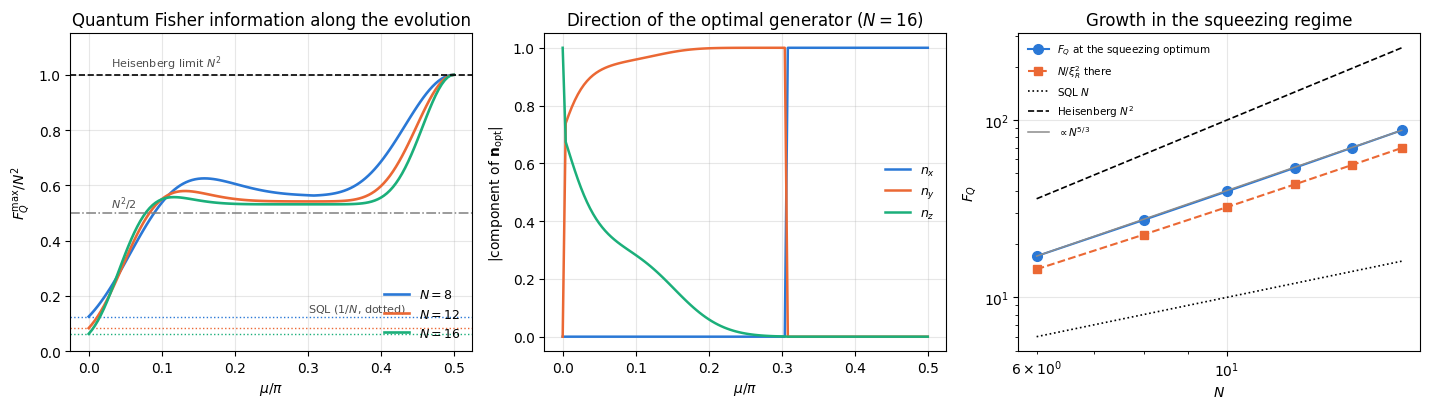

In [8]:
# ==============================================================================
# FIGURE: the metrological gain along the whole one-axis-twisting evolution
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(14.4, 4.2))

for k, N in enumerate(N_TRACK):
    F, nvec, xiR2 = track[N]
    axes[0].plot(MU_TRACK / np.pi, F / N ** 2, "-", color=PALETTE[k], lw=1.9, label=f"$N={N}$")
    axes[0].axhline(1.0 / N, color=PALETTE[k], ls=":", lw=1.0)
axes[0].axhline(1.0, color="k", ls="--", lw=1.2)
axes[0].axhline(0.5, color="0.5", ls="-.", lw=1.1)
axes[0].text(0.03, 1.03, "Heisenberg limit $N^2$", fontsize=8, color="0.3")
axes[0].text(0.03, 0.52, "$N^2/2$", fontsize=8, color="0.3")
axes[0].text(0.30, 1.0 / N_TRACK[0] + 0.02, "SQL ($1/N$, dotted)", fontsize=8, color="0.3")
axes[0].set_xlabel(r"$\mu/\pi$"); axes[0].set_ylabel(r"$F_Q^{\max}/N^2$")
axes[0].set_ylim(0, 1.15); axes[0].set_title("Quantum Fisher information along the evolution")
axes[0].legend(fontsize=9, loc="lower right")

Nb = 16
F, nvec, xiR2 = track[Nb]
for k, (lbl, comp) in enumerate([(r"$n_x$", 0), (r"$n_y$", 1), (r"$n_z$", 2)]):
    axes[1].plot(MU_TRACK / np.pi, [abs(fix_sign(v)[comp]) for v in nvec], "-", color=PALETTE[k], lw=1.8, label=lbl)
axes[1].set_xlabel(r"$\mu/\pi$"); axes[1].set_ylabel(r"$\vert$component of $\mathbf{n}_{\rm opt}\vert$")
axes[1].set_title(f"Direction of the optimal generator ($N={Nb}$)"); axes[1].legend(fontsize=9)

axes[2].loglog(Ng, [r[3] for r in rows_grow], "o-", color=PALETTE[0], ms=7,
               label=r"$F_Q$ at the squeezing optimum")
axes[2].loglog(Ng, [r[4] for r in rows_grow], "s--", color=PALETTE[1], ms=6, label=r"$N/\xi_R^2$ there")
axes[2].loglog(Ng, Ng, "k:", lw=1.2, label=r"SQL $N$")
axes[2].loglog(Ng, Ng ** 2, "k--", lw=1.2, label=r"Heisenberg $N^2$")
axes[2].loglog(Ng, Ng[0] ** (-5 / 3) * float(rows_grow[0][3]) * Ng ** (5 / 3), "-", color="0.55", lw=1.1,
               label=r"$\propto N^{5/3}$")
axes[2].set_xlabel("$N$"); axes[2].set_ylabel(r"$F_Q$")
axes[2].set_title("Growth in the squeezing regime"); axes[2].legend(fontsize=7.5)
fig.tight_layout(); plt.show()

All four features are present.

* $F_Q^{\max}(0)=N$ exactly, and $F_Q^{\max}(\pi/2)=N^2$ exactly, for all three sizes.
* Between them the curve rises fast, overshoots, and settles on a **plateau**. Measured as the median of $F_Q/N^2$ over
  $0.20\pi<\mu<0.40\pi$, the plateau is $0.577$ at $N=8$, $0.543$ at $N=12$ and $0.531$ at $N=16$ — drifting towards
  $1/2$ as $N$ grows. So the multi-component states of the middle of the evolution carry $F_Q\approx N^2/2$: half the
  Heisenberg value, which is still $N/2$ times the standard quantum limit. The reason is geometric. Model the state
  as an equal-weight superposition of $q\ge3$ non-overlapping coherent spin states pointing along equatorial unit
  vectors $\mathbf e_p$ at equally spaced azimuths. For an equatorial generator $\mathbf n\cdot\mathbf J$, lobe $p$
  contributes $\langle(\mathbf n\cdot\mathbf J)^2\rangle_p=\tfrac{N^2}{4}(\mathbf n\cdot\mathbf e_p)^2
  +\tfrac N4\big[1-(\mathbf n\cdot\mathbf e_p)^2\big]$ (its mean squared plus its own coherent-state variance), the
  mean $\langle\mathbf n\cdot\mathbf J\rangle$ vanishes, and the average of $(\mathbf n\cdot\mathbf e_p)^2=\cos^2$
  over $q\ge3$ equally spaced angles is exactly $\tfrac12$. Hence $F_Q=4\mathrm{Var}=\tfrac{N^2}{2}+\tfrac N2$, i.e.
  $F_Q/N^2=\tfrac12+\tfrac1{2N}$ — the column printed next to the plateau: $0.5625$, $0.5417$, $0.5312$ against the
  measured $0.577$, $0.543$, $0.531$. The model is close at $N=12$ and $16$; at $N=8$ the lobes still overlap.
* The middle panel tracks $\mathbf n_{\rm opt}$ at $N=16$. It starts in the $y$–$z$ plane (for a CSS every direction
  there is equally good, and the numerical eigenvector picks one), rotates towards $\hat y$ as the ellipse shears, and
  then **jumps discontinuously to $\hat x$ at $\mu\approx0.30\pi$**. The jump is not a numerical artefact: it is the
  moment at which two eigenvalues of $\mathcal F$ cross, and the *largest* eigenvalue changes branch. From there on the
  optimal generator is $J_x$, the cat axis of Eq. (3), all the way to $\mu=\pi/2$.
* In the squeezing regime the single power-law fit over $6\le N\le16$ gives $F_Q\sim N^{1.668}$, numerically within
  $0.1\%$ of the asymptotic $N^{5/3}=N^{1.667}$. This agreement is a coincidence of the fitting range, and the local
  slopes printed below the fit show it: $d\ln F_Q/d\ln N$ rises from $1.63$ ($N=6\to8$) to $1.70$ ($N=14\to16$), and
  the straight-line fit simply averages them. The analytic moments of notebook 33 (Section 9) continue the trend: the
  local slope keeps rising to about $1.75$ near $N\sim100$ and comes back down to $5/3$ only for $N\gtrsim10^5$, the
  slow $N^{-1/3}$ corrections of Section 6.2. The quantity $N/\xi_R^2$ at the same twisting angle has the smaller
  fitted exponent $1.607$, with local slopes rising from $1.56$ to $1.65$. The bound $F_Q\ge N/\xi_R^2$ is respected
  at every size (the cell asserts it) and is not tight even at the Wineland optimum: the two columns differ by $19\%$
  at $N=6$ and by $26\%$ at $N=16$, on their way to the asymptotic ratio $3/2$ derived in Section 6.2. The last two
  columns of the table show where the gap comes from: the ratio $F_Q\xi_R^2/N$ equals the excess
  $V_{\min}V_{\max}/(\vert\langle\mathbf J\rangle\vert^2/4)$ of the transverse uncertainty product over its minimum,
  notebook 33, Eq. (26a), and the cell asserts the identity to $10^{-8}$ at every size.

> **Numerical practice.** "Read the eigenvector as well as the eigenvalue." The $3\times3$ QFI matrix costs three
> applications of a collective operator, and it answers two questions at once: *how good* the state is and *what to do
> with it*. An optimisation over the sphere would have given only the first, more slowly, and with no certificate of
> global optimality.

## 7. Intermediate times: $q$-component cats

At $\mu=\pi/q$ with integer $q$ the phase $e^{-i\mu m^2}=e^{-i\pi m^2/q}$ is a periodic function of $m$ and, exactly as
in Section 4, a periodic function can be expanded in a *finite* number of Fourier modes $e^{i2\pi mp/q}$. Each mode is a
rotation about $\hat z$ by a fixed angle, so the state is a superposition of a few coherent spin states arranged
around the equator. The number of components is $q$ (for $q$ even) or $q$ with a different arrangement (for $q$ odd);
the coefficients are quadratic Gauss sums. We do not need the coefficients — we can look.

The Husimi-$Q$ function, $Q(\theta,\varphi)=\vert\langle\theta,\varphi\vert\psi\rangle\vert^2$, is the overlap of the
state with the coherent spin state pointing in each direction; it is non-negative and it is what "the distribution of
the spin direction" means. Since $\vert\theta,\varphi\rangle$ is a product state, $Q$ is a contraction of $\psi$ with
the same $2$-vector on every axis, and the whole grid of directions is one `vmap`.

  q  mu = pi/q |  lobes on the equator   F_Q^max/N^2  lobe separation 2pi/q  CSS width 1/sqrt(N)


  2    1.57080 |                     2        1.0000                 3.1416               0.2887


  3    1.04720 |                     3        0.5421                 2.0944               0.2887


  4    0.78540 |                     4        0.5426                 1.5708               0.2887


  5    0.62832 |                     5        0.5506                 1.2566               0.2887


  6    0.52360 |                     4        0.5657                 1.0472               0.2887


  8    0.39270 |                     1        0.5784                 0.7854               0.2887


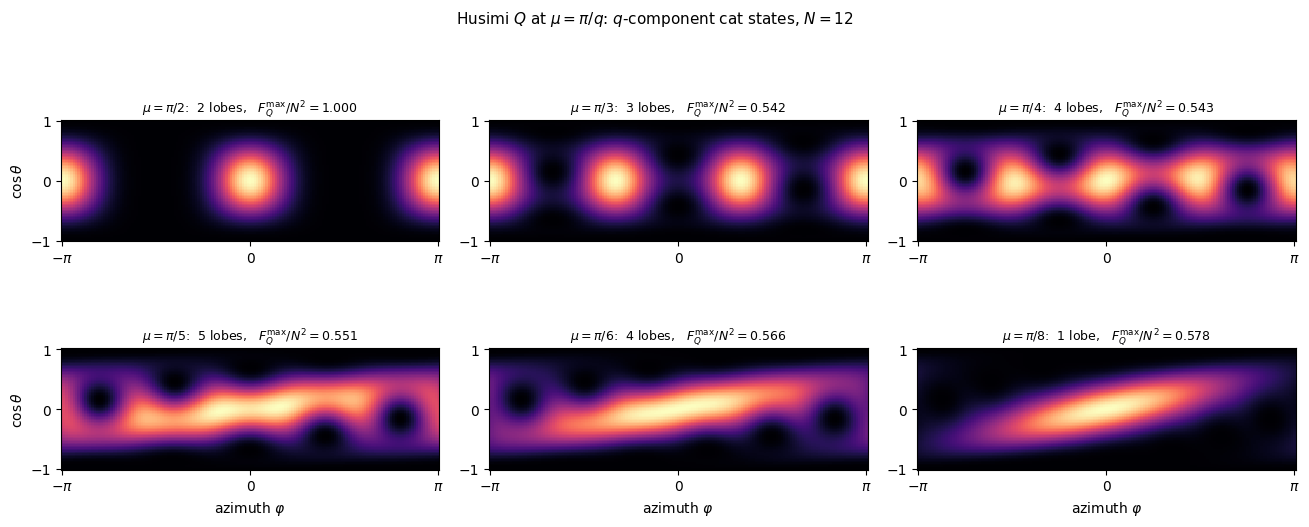

In [9]:
# ==============================================================================
# STEP 5: Husimi-Q maps of the q-component cats
# ==============================================================================
def css_overlap(psi, theta, phi):
    """<theta,phi|psi> for the coherent spin state |theta,phi> = (cos(th/2)|0> + e^{i ph} sin(th/2)|1>)^N.

    EINSUM  N=3:  "a,b,c,abc->"  with operands conj(v), conj(v), conj(v), psi.
            Implemented as N successive contractions of the leading axis: O(2^{N+1}) in total.
    """
    v = jnp.conj(jnp.stack([jnp.cos(theta / 2), jnp.exp(1j * phi) * jnp.sin(theta / 2)]).astype(CDTYPE))
    out = psi
    for _ in range(psi.ndim):
        out = jnp.tensordot(v, out, axes=([0], [0]))
    return out


def husimi_q(psi, theta_grid, phi_grid):
    """Q(theta, phi) on a 2D grid; nested vmap -> one fused program, no Python loop over grid points."""
    single = lambda th, ph: jnp.abs(css_overlap(psi, th, ph)) ** 2
    return jax.vmap(jax.vmap(single, in_axes=(0, 0)), in_axes=(0, 0))(theta_grid, phi_grid)


# PARAMETERS ------------------------------------------------------------------
N_Q = 12                     # size for the Bloch-sphere pictures
N_PHI, N_COS = 161, 81       # grid resolution (equal-area projection: azimuth x cos(theta))
# -----------------------------------------------------------------------------
phi_ax = np.linspace(-np.pi, np.pi, N_PHI)
cos_ax = np.linspace(-1.0, 1.0, N_COS)
PHI_M, COS_M = np.meshgrid(phi_ax, cos_ax)
THETA_M = jnp.asarray(np.arccos(np.clip(COS_M, -1.0, 1.0)))
PHI_J = jnp.asarray(PHI_M)
psi_q0 = product_state("+" * N_Q)

def count_equatorial_lobes(Qmap, rel=0.25):
    """Number of local maxima of Q along the equator, with periodic boundaries.

    A 'lobe' is a grid point on the cos(theta) = 0 row that is larger than both neighbours
    (cyclically) and at least `rel` times the row maximum -- the threshold suppresses the tiny
    interference ripples between well-separated components.
    """
    row = Qmap[Qmap.shape[0] // 2][:-1]              # drop the duplicated phi = +pi column
    left, right = np.roll(row, 1), np.roll(row, -1)
    return int(np.sum((row > left) & (row >= right) & (row > rel * row.max())))


fig, axes = plt.subplots(2, 3, figsize=(13.2, 5.6))
qs = [2, 3, 4, 5, 6, 8]
print(f"{'q':>3s} {'mu = pi/q':>10s} | {'lobes on the equator':>21s} {'F_Q^max/N^2':>13s} "
      f"{'lobe separation 2pi/q':>22s} {'CSS width 1/sqrt(N)':>20s}")
for ax, q in zip(axes.ravel(), qs):
    mu = np.pi / q
    psi_mu = oat_evolve(psi_q0, mu)
    Qmap = np.array(husimi_q(psi_mu, THETA_M, PHI_J))
    n_lobes = count_equatorial_lobes(Qmap)
    fq = float(optimal_direction(psi_mu)[0])
    print(f"{q:3d} {mu:10.5f} | {n_lobes:21d} {fq / N_Q ** 2:13.4f} {2 * np.pi / q:22.4f} "
          f"{1 / np.sqrt(N_Q):20.4f}")
    if q <= 5:
        assert n_lobes == q                          # resolved components: exactly q lobes (Fourier argument)
    ax.pcolormesh(phi_ax, cos_ax, Qmap, shading="auto", cmap="magma", vmin=0.0)
    ax.set_aspect("equal"); ax.grid(False)
    ax.set_title(rf"$\mu=\pi/{q}$:  {n_lobes} lobe" + ("s" if n_lobes != 1 else "")
                 + rf",   $F_Q^{{\max}}/N^2={fq / N_Q ** 2:.3f}$", fontsize=9)
    ax.set_xticks([-np.pi, 0, np.pi]); ax.set_xticklabels([r"$-\pi$", "0", r"$\pi$"])
    ax.set_yticks([-1, 0, 1])
for ax in axes[1]:
    ax.set_xlabel(r"azimuth $\varphi$")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$\cos\theta$")
fig.suptitle(f"Husimi $Q$ at $\\mu=\\pi/q$: $q$-component cat states, $N={N_Q}$", fontsize=11)
fig.tight_layout(); plt.show()

The lobe counts printed above come from the equatorial cut of each map, not from the eye: a grid point on the
$\cos\theta=0$ row counts as a lobe if it exceeds both cyclic neighbours and a quarter of the row maximum. The
azimuth is periodic, so the columns $\varphi=-\pi$ and $\varphi=+\pi$ of each map are the same meridian and the
counter drops the duplicate: the $q=2$ panel shows three bright blobs but only two distinct lobes. At $N=12$
the counter finds $2,3,4,5$ lobes for $q=2,3,4,5$ — exactly $q$, as the Fourier argument says — and then $4$ for
$q=6$ and $1$ for $q=8$.

The last two columns explain the breakdown. The components are separated by $2\pi/q$ in azimuth, while each of them is
a rotated copy of the original coherent state and therefore has an angular width $\sim1/\sqrt N=0.289$ rad, further
stretched along the shear direction. At $q=6$ the separation is $1.047$ rad, about $3.6$ lobe widths before the shear
is taken into account, and the maps at $\mu=\pi/6$ and $\mu=\pi/8$ show a sheared band with interference holes instead
of resolved components. The Fourier argument bounds the number of components; *resolving* them needs a large $N$, and
$N=12$ is enough only up to $q=5$.

The metrological price of splitting the state is in the titles. $F_Q^{\max}/N^2$ is exactly $1.000$ for the
two-component cat and sits between $0.54$ and $0.58$ for every $q\ge3$: two lobes at antipodes of the measurement axis
give the maximal spread of $\mathbf n\cdot\mathbf J$, $\pm N/2$, while lobes distributed around a circle give an
average of $\cos^2$, which is $1/2$. This is the origin of the plateau seen in Section 6, and it explains why the
plateau drifts *down* towards $1/2$ as $N$ grows: the coherent-state variance of each lobe adds the correction
$1/(2N)$ derived there, $0.5417$ at $N=12$, against the measured $0.5421$ ($q=3$) and $0.5426$ ($q=4$).

## 8. Encoding and parity readout: reaching the Heisenberg limit from data

### 8.1 The fringe

Take the cat $\vert C\rangle=\left(e^{-i\pi/4}\vert{+}\mathbf n\rangle^{\otimes N}+\eta\,e^{+i\pi/4}\vert{-}\mathbf n\rangle^{\otimes N}\right)/\sqrt2$
with $\mathbf n$ the cat axis ($\hat x$ for even $N$, $\hat y$ for odd $N$, as Section 4 proved and Section 6 confirmed
numerically) and $\eta=\pm1$: Eq. (3) has exactly this form with $\eta=(-1)^{N/2}$, and Eq. (5) has it up to a
global phase with $\eta=(-1)^{(N-1)/2}$. Encode the phase with the optimal generator $G=\mathbf n\cdot\mathbf J$. Since
$\vert\pm\mathbf n\rangle^{\otimes N}$ are eigenstates of $G$ with eigenvalues $\pm N/2$,

$$e^{-i\theta G}\vert C\rangle=\frac{1}{\sqrt2}\left(e^{-i\theta N/2}e^{-i\pi/4}\vert{+}\mathbf n\rangle^{\otimes N}
 +e^{+i\theta N/2}\eta\,e^{+i\pi/4}\vert{-}\mathbf n\rangle^{\otimes N}\right). \tag{6}$$

The two branches acquire a **relative phase $N\theta$**: the whole point of the Heisenberg limit is this factor $N$,
which comes from $N$ particles each collecting $\theta$ *coherently*.

### 8.2 Why parity reads it out

A relative phase between two orthogonal branches is invisible in any measurement that distinguishes them. It becomes
visible in a measurement of an observable that *exchanges* them. The **parity**

$$\Pi=\prod_{q=0}^{N-1}Z_q$$

does exactly that whenever $\mathbf n\perp\hat z$: $Z$ anticommutes with both $\sigma^x$ and $\sigma^y$, so
$Z_q\vert\pm\mathbf n\rangle_q=\vert\mp\mathbf n\rangle_q$ and $\Pi\vert\pm\mathbf n\rangle^{\otimes N}=\vert\mp\mathbf n\rangle^{\otimes N}$.
The expectation value of $\Pi$ in the state of Eq. (6) is therefore a pure interference term, an oscillation of period
$2\pi/N$ in $\theta$. And $\Pi$ is *diagonal in the computational basis*: measuring it costs nothing beyond the
standard readout, because $\Pi=(-1)^{k}$ with $k$ the number of qubits found in $\vert1\rangle$.

The measurement has two outcomes, $\Pi=\pm1$, so the model is a two-outcome model, and its classical Fisher information
follows from the formula of notebook 29: for $p_\pm(\theta)=\left(1\pm\mathcal{A}\sin(N\theta+\varphi_0)\right)/2$ with
visibility $\mathcal{A}$,

$$I(\theta)=\frac{\left(\partial_\theta p_+\right)^2}{p_+}+\frac{\left(\partial_\theta p_-\right)^2}{p_-}
 =\frac{\mathcal{A}^2N^2\cos^2(N\theta+\varphi_0)}{1-\mathcal{A}^2\sin^2(N\theta+\varphi_0)} . \tag{7}$$

At a zero crossing of the fringe and with unit visibility, $I=N^2=F_Q$: the parity readout is optimal there.

In [10]:
# ==============================================================================
# STEP 6: the parity fringe, its Fisher information, and the sampled experiment
# ==============================================================================
# PARAMETERS ------------------------------------------------------------------
N_RO      = 10                                  # qubits in the readout experiment
THETA_TRUE = 0.0                                # working point (a zero crossing of the fringe)
M_SHOTS   = (25, 50, 100, 200, 400, 800)        # shots per experiment
R_EXP     = 600                                 # independent experiments per point
# -----------------------------------------------------------------------------
_PARITY = jnp.asarray(np.array([(-1) ** bin(i).count("1") for i in range(2 ** N_RO)]))

psi_cat_ro = oat_evolve(product_state("+" * N_RO), np.pi / 2)
F_Q_ro, n_cat = optimal_direction(psi_cat_ro)
n_cat = jnp.asarray(fix_sign(n_cat))
print(f"N = {N_RO}:  cat axis n = {np.array2string(np.array(n_cat), precision=4, floatmode='fixed')},"
      f"  F_Q = {float(F_Q_ro):.6f}  (N^2 = {N_RO ** 2})")


def parity_probs(theta):
    """p(Pi = +1), p(Pi = -1) after encoding the phase theta with the optimal generator.

    MATH   |psi_theta> = exp(-i theta n.J)|C> ; Pi = prod_q Z_q is DIAGONAL in the computational
           basis with eigenvalue (-1)^{number of ones}, so p(+) = sum_{s : even} |psi_theta[s]|^2 .
    """
    psi = collective_rotation(psi_cat_ro, theta, n_cat)
    pr = jnp.abs(psi.reshape(-1)) ** 2
    p_even = jnp.sum(jnp.where(_PARITY > 0, pr, 0.0))
    return jnp.stack([p_even, 1.0 - p_even])


def classical_fisher(prob_fn, theta, tol=1e-14):
    """I(theta) = sum_x (d p_x/d theta)^2 / p_x with an EXACT derivative from jax.jacfwd.

    JAX   a double `jnp.where` masks zero-probability outcomes so they contribute exactly 0 (no NaN).
    """
    p = prob_fn(theta)
    dp = jax.jacfwd(prob_fn)(theta)
    ok = p > tol
    return jnp.sum(jnp.where(ok, dp ** 2 / jnp.where(ok, p, 1.0), 0.0))


print(f"\n{'theta':>10s} | {'p(Pi=+1)':>10s} {'<Pi>':>9s} {'I(theta)':>11s} {'I/N^2':>8s}")
for th in (0.0, 0.25 * np.pi / (2 * N_RO), 0.5 * np.pi / (2 * N_RO), np.pi / (2 * N_RO)):
    p = parity_probs(th)
    print(f"{th:10.6f} | {float(p[0]):10.6f} {float(p[0] - p[1]):9.5f} "
          f"{float(classical_fisher(parity_probs, th)):11.6f} "
          f"{float(classical_fisher(parity_probs, th)) / N_RO ** 2:8.5f}")
I_parity = float(classical_fisher(parity_probs, THETA_TRUE))
print(f"\nparity readout at theta = 0:  I = {I_parity:.8f}   F_Q = {float(F_Q_ro):.8f}   "
      f"I/F_Q = {I_parity / float(F_Q_ro):.8f}")
assert abs(I_parity - float(F_Q_ro)) < 1e-6 * N_RO ** 2

N = 10:  cat axis n = [1.0000 0.0000 0.0000],  F_Q = 100.000000  (N^2 = 100)

     theta |   p(Pi=+1)      <Pi>    I(theta)    I/N^2


  0.000000 |   0.500000  -0.00000  100.000000  1.00000


  0.039270 |   0.691342   0.38268  100.000000  1.00000
  0.078540 |   0.853553   0.70711  100.000000  1.00000


  0.157080 |   1.000000   1.00000    0.000000  0.00000

parity readout at theta = 0:  I = 100.00000000   F_Q = 100.00000000   I/F_Q = 1.00000000


In [11]:
# ==============================================================================
# STEP 7: from clicks to an error bar -- maximum likelihood on sampled parities
# ==============================================================================
HALF_FRINGE = np.pi / (2 * N_RO)                      # half a fringe: the unambiguous search window
THETA_GRID = jnp.linspace(THETA_TRUE - HALF_FRINGE, THETA_TRUE + HALF_FRINGE, 601)
logp_grid = jnp.log(jnp.clip(jax.vmap(parity_probs)(THETA_GRID), 1e-300, None))
p_true = jnp.clip(parity_probs(THETA_TRUE), 1e-300, None)
psi_out_true = collective_rotation(psi_cat_ro, THETA_TRUE, n_cat)      # the state the detector sees

# --- what one shot looks like -------------------------------------------------------------
bits_demo = np.array(sample_bitstrings(jax.random.PRNGKey(7), psi_out_true, 8))
print("eight shots of the cat interferometer (one row = a projective measurement of all N qubits):")
for b in bits_demo:
    print("   " + "".join(str(int(x)) for x in b) + f"    parity Pi = {+1 if b.sum() % 2 == 0 else -1:+d}")

# --- CHECKPOINT: sampled bit strings reproduce the exact parity distribution ---------------
# At the working point theta = 0 the exact p(+1) is 1/2, which ANY source of random parities would
# reproduce. The checkpoint is therefore run at a phase where p(+1) is far from 1/2, and a wrong
# control (the un-encoded cat, as if the encoding step had been skipped) must FAIL the same test.
N_DEMO_SHOTS = 20_000
THETA_CHK = np.pi / (4 * N_RO)                         # quarter of a fringe: p(+1) = (1 + sin(pi/4))/2
p_chk = float(parity_probs(THETA_CHK)[0])
sigma_chk = np.sqrt(p_chk * (1 - p_chk) / N_DEMO_SHOTS)


def sampled_even_fraction(key, psi):
    """Fraction of sampled bit strings with an even number of ones (Pi = +1)."""
    bits = np.array(sample_bitstrings(key, psi, N_DEMO_SHOTS))
    return float(np.mean(bits.sum(axis=1) % 2 == 0))


freq_even = sampled_even_fraction(jax.random.PRNGKey(8), collective_rotation(psi_cat_ro, THETA_CHK, n_cat))
freq_ctrl = sampled_even_fraction(jax.random.PRNGKey(9), psi_cat_ro)          # wrong control: no encoding
print(f"\n{N_DEMO_SHOTS} sampled bit strings at theta = pi/(4N): frequency of Pi = +1 is {freq_even:.5f},"
      f" exact p(+1) = {p_chk:.5f}   (deviation {abs(freq_even - p_chk) / sigma_chk:.2f} sigma,"
      f" sigma = {sigma_chk:.2e})")
print(f"control without the encoding step:      frequency {freq_ctrl:.5f}"
      f"   (deviation {abs(freq_ctrl - p_chk) / sigma_chk:.0f} sigma -> must fail)")
assert abs(freq_even - p_chk) < 5 * sigma_chk
assert abs(freq_ctrl - p_chk) > 5 * sigma_chk


def ml_experiments(key, shots, n_exp):
    """`n_exp` experiments of `shots` shots each; return the maximum-likelihood estimates of theta.

    PROTOCOL  one shot = measure all N qubits in the computational basis, then reduce the bit string
        to its PARITY, (number of ones) mod 2: outcome 0 means Pi = +1.  No extra hardware is needed --
        the parity is a function of the standard readout.  The cell above draws the bit strings
        explicitly with `sample_bitstrings`; here the reduced binary outcome is sampled directly from
        the same distribution, which is statistically identical and avoids materialising the 2^N
        Gumbel variates `jax.random.categorical` would need for each of the shots x n_exp strings.
    MATH  log L(theta) = n_+ log p_+(theta) + n_- log p_-(theta)  ->  one matrix-vector product.
    JAX   vmap over PRNG keys turns the repetitions into a single batched program.
    """
    lp = jnp.log(p_true)

    def one(k):
        idx = jax.random.categorical(k, lp, shape=(shots,))
        counts = jnp.bincount(idx, length=2)                           # [n(Pi=+1), n(Pi=-1)]
        return THETA_GRID[jnp.argmax(logp_grid @ counts)]

    return jax.vmap(one)(jax.random.split(key, n_exp))


t0 = time.time()
rows_ml = []
for M in M_SHOTS:
    # an independent key per M (fold_in), so that the six rows are statistically independent
    est = jax.jit(partial(ml_experiments, shots=M, n_exp=R_EXP))(jax.random.fold_in(jax.random.PRNGKey(2026), M))
    var = float(jnp.var(est))
    rows_ml.append((M, float(jnp.mean(est)) - THETA_TRUE, var, var * np.sqrt(2 / (R_EXP - 1))))
print(f"(simulated {len(M_SHOTS) * R_EXP} experiments in {time.time() - t0:.1f} s)\n")
print(f"{'M':>6s} {'bias':>11s} {'Delta theta':>13s} {'1/(N sqrt M)':>14s} {'SQL 1/sqrt(NM)':>16s} "
      f"{'M F_Q Var':>11s}")
for M, bias, var, err in rows_ml:
    print(f"{M:6d} {bias:+11.6f} {np.sqrt(var):13.6f} {1 / (N_RO * np.sqrt(M)):14.6f} "
          f"{1 / np.sqrt(N_RO * M):16.6f} {var * M * float(F_Q_ro):11.4f}")
assert abs(rows_ml[-1][2] * M_SHOTS[-1] * float(F_Q_ro) - 1.0) < 0.2

eight shots of the cat interferometer (one row = a projective measurement of all N qubits):
   1101010111    parity Pi = -1
   1101011000    parity Pi = -1
   1101101100    parity Pi = +1
   1001001100    parity Pi = +1
   1111110011    parity Pi = +1
   1000101111    parity Pi = +1
   1001010001    parity Pi = +1
   1001001000    parity Pi = -1



20000 sampled bit strings at theta = pi/(4N): frequency of Pi = +1 is 0.85600, exact p(+1) = 0.85355   (deviation 0.98 sigma, sigma = 2.50e-03)
control without the encoding step:      frequency 0.50040   (deviation 141 sigma -> must fail)


(simulated 3600 experiments in 15.9 s)

     M        bias   Delta theta   1/(N sqrt M)   SQL 1/sqrt(NM)   M F_Q Var
    25   -0.000294      0.020322       0.020000         0.063246      1.0325
    50   +0.000162      0.014343       0.014142         0.044721      1.0287
   100   +0.000278      0.009871       0.010000         0.031623      0.9743
   200   -0.000262      0.007052       0.007071         0.022361      0.9947
   400   +0.000227      0.004930       0.005000         0.015811      0.9720
   800   +0.000152      0.003437       0.003536         0.011180      0.9450


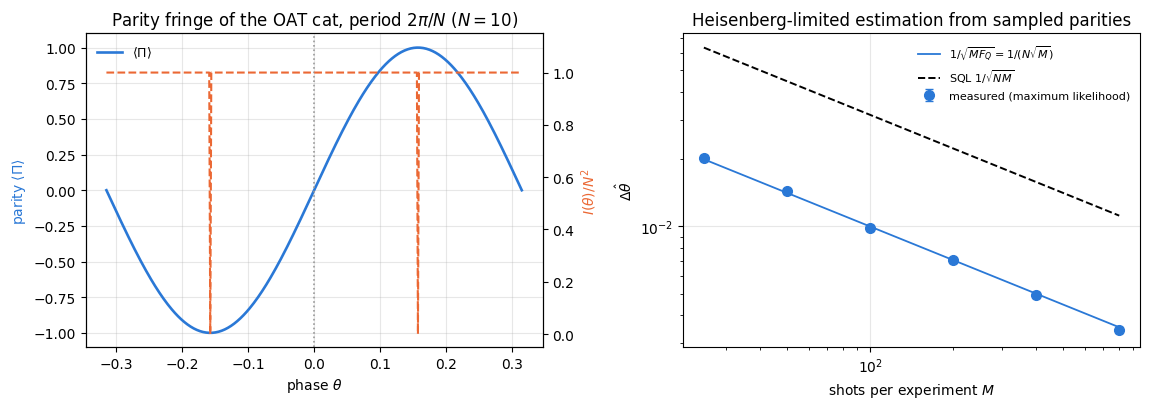

In [12]:
# ==============================================================================
# FIGURE: the parity fringe and the achieved sensitivity
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.2))

th_ax = np.linspace(-np.pi / N_RO, np.pi / N_RO, 401)
par = np.array([float(parity_probs(float(t))[0] - parity_probs(float(t))[1]) for t in th_ax])
I_ax = np.array([float(classical_fisher(parity_probs, float(t))) for t in th_ax])
axes[0].plot(th_ax, par, "-", color=PALETTE[0], lw=1.9, label=r"$\langle\Pi\rangle$")
ax0b = axes[0].twinx()
ax0b.plot(th_ax, I_ax / N_RO ** 2, "--", color=PALETTE[1], lw=1.5, label=r"$I(\theta)/N^2$")
ax0b.set_ylabel(r"$I(\theta)/N^2$", color=PALETTE[1]); ax0b.grid(False); ax0b.set_ylim(-0.05, 1.15)
axes[0].axvline(THETA_TRUE, color="0.6", ls=":", lw=1.2)
axes[0].set_xlabel(r"phase $\theta$"); axes[0].set_ylabel(r"parity $\langle\Pi\rangle$", color=PALETTE[0])
axes[0].set_title(f"Parity fringe of the OAT cat, period $2\\pi/N$ ($N={N_RO}$)")
axes[0].legend(fontsize=9, loc="upper left")

Ms = np.array(M_SHOTS, dtype=float)
v = np.array([r[2] for r in rows_ml]); e = np.array([r[3] for r in rows_ml])
axes[1].errorbar(Ms, np.sqrt(v), yerr=0.5 * e / np.sqrt(v), fmt="o", color=PALETTE[0], ms=7, capsize=3,
                 label="measured (maximum likelihood)")
axes[1].plot(Ms, 1 / np.sqrt(Ms * float(F_Q_ro)), "-", color=PALETTE[0], lw=1.3,
             label=r"$1/\sqrt{M F_Q}=1/(N\sqrt{M})$")
axes[1].plot(Ms, 1 / np.sqrt(N_RO * Ms), "k--", lw=1.4, label=r"SQL $1/\sqrt{NM}$")
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("shots per experiment $M$"); axes[1].set_ylabel(r"$\Delta\hat\theta$")
axes[1].set_title("Heisenberg-limited estimation from sampled parities"); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

The parity oscillates with period $2\pi/N$ and with **full visibility**, $\mathcal{A}=1$, so the denominator of
Eq. (7) is $1-\sin^2=\cos^2$ and cancels the numerator exactly: $I(\theta)=N^2$ at *every* phase except the two
extrema of the fringe, where $\cos^2(N\theta)=0$ and the readout carries no information at all (the dashed curve on
the right axis is flat at $1$ and drops vertically to $0$ at $\theta=\pm\pi/(2N)$). The drop occurs at a single point,
where one outcome has probability exactly $0$, the score is undefined, and $I$ need not equal the limit of its
neighbours — the irregular model of notebook 29, Section 4.7. The table confirms it: $I=100.000$
at $\theta=0$, $0.0393$ and $0.0785$, and $0$ at $\theta=\pi/(2N)$. At the working point $I/F_Q=1.00000000$ — the
parity measurement is *exactly* optimal, with no need to build the SLD basis.

The eight printed shots show what the apparatus records: strings of ten bits, of which only the parity is kept.
The sampler checkpoint is run a quarter fringe away from the working point, because at $\theta=0$ the exact
$p(\Pi=+1)=\tfrac12$ would be reproduced by any source of random parities. There, over $20\,000$ shots, the frequency
of $\Pi=+1$ is $0.8560$ against the exact $0.8536$, a deviation of $0.98$ standard deviations; the control in which the
encoding step is skipped gives $0.5004$, $141$ standard deviations off, and fails the same test as it must. Nothing
about this readout is special hardware — it is the ordinary population measurement, read modulo $2$.

The right panel closes the loop. The maximum-likelihood estimate from $M$ sampled parities shows no detectable bias:
the six values scatter around zero with no trend, all below $3\times10^{-4}$ in magnitude, i.e. within about one
Monte-Carlo error $\sqrt{\mathrm{Var}/R}$ of a mean over $R=600$ experiments ($8.3\times10^{-4}$ at $M=25$,
$1.4\times10^{-4}$ at $M=800$). Its standard deviation follows $1/(N\sqrt M)$ across the whole range, a factor
$\sqrt N=3.16$ below the standard quantum limit. The scaled variance $MF_Q\mathrm{Var}$ ranges over $0.945$–$1.033$,
within the $5.8\%$ relative error of a variance measured from $600$ experiments. (Each $M$ uses its own PRNG key,
so the six rows are statistically independent.)

> **Common pitfall.** The gain is real but the *window* is narrow: the search had to be restricted to
> $\vert\theta\vert<\pi/(2N)$, half a fringe. Outside it the likelihood has equally high peaks on neighbouring fringes
> and the estimator jumps. Heisenberg scaling in a real device therefore needs a hierarchical protocol — a coarse,
> SQL-limited estimate first, then the cat.

## 9. Noise: the machinery

Everything so far was unitary. A cat state is the most fragile object in this chapter, so the interesting question is
what survives.

### 9.1 The model

We let a single-qubit channel act on every qubit, continuously, *during* the twisting. Splitting the evolution into
$n_{\rm step}$ intervals of length $\delta\mu=\mu/n_{\rm step}$, each step is

$$\rho\;\longrightarrow\;\mathcal{E}^{\otimes N}_{p}\!\left(U_{\delta\mu}\,\rho\,U_{\delta\mu}^\dagger\right),
\qquad U_{\delta\mu}=e^{-i\delta\mu J_z^2},\qquad p=\gamma\,\delta\mu, \tag{8}$$

with $\gamma$ the dimensionless noise rate (noise probability per unit twisting angle). The unitary part is exact — it
is the same diagonal phase multiplication, now applied to both index groups of the density tensor. Only the *splitting*
between unitary and dissipative parts is first order in $\delta\mu$, and we check convergence in $n_{\rm step}$.

The density tensor has $4^N$ entries ($4096$ complex numbers at $N=6$, a rank-$12$ tensor), and every QFI evaluation
adds an $O(8^N)$ eigendecomposition of the $2^N\times2^N$ matrix. Neither is large at $N=6$–$8$; what sets the working
range $N\le6$ is the number of evaluations — $12$ sweeps of $32$ steps, the convergence check and the comparison of
Section 12 — within the time budget of the notebook.

### 9.2 The unitary step on a density tensor

$U=e^{-i\mu J_z^2}$ is diagonal: $U\vert s\rangle=e^{-i\mu m(s)^2}\vert s\rangle$. Therefore

$$\left(U\rho U^\dagger\right)[s;s']=e^{-i\mu\left(m(s)^2-m(s')^2\right)}\,\rho[s;s'],$$

one elementwise multiplication by an outer product of the phase tensor with its conjugate. No gates, no Trotter error
in the unitary part.

### 9.3 The QFI of a mixed state

For a mixed state the pure-state formula $4\mathrm{Var}(G)$ is wrong, and the correct object is the symmetric
logarithmic derivative $L$, defined by $\partial_\theta\rho=\tfrac12(L\rho+\rho L)$ and derived in
[30](../ch10_quantum_metrology_protocols/30_qfi_from_the_sld_prepare_encode_estimate.ipynb). In the eigenbasis
$\rho=\sum_m\lambda_m\vert m\rangle\langle m\vert$ and for unitary encoding $\partial_\theta\rho=-i[G,\rho]$, it gives

$$F_Q[\rho,G]=2\sum_{\substack{m,n\\ \lambda_m+\lambda_n>0}}\frac{(\lambda_m-\lambda_n)^2}{\lambda_m+\lambda_n}
 \left\vert\langle m\vert G\vert n\rangle\right\vert^2 . \tag{9}$$

Two things about Eq. (9) matter here. First, it is still a **quadratic form** in the generator direction: substituting
$G=\sum_an_aJ_a$,

$$F_Q(\mathbf n)=\sum_{a,b}n_an_b\,\Gamma_{ab},\qquad
\Gamma_{ab}=2\sum_{m,n}\frac{(\lambda_m-\lambda_n)^2}{\lambda_m+\lambda_n}\,
  \mathrm{Re}\left[\langle m\vert J_a\vert n\rangle\overline{\langle m\vert J_b\vert n\rangle}\right], \tag{10}$$

so the optimal direction is again the top eigenvector of a $3\times3$ real symmetric matrix — for mixed states as for
pure ones. Second, the kernel of $\rho$ must be excluded, which is what the guarded division below does.

We implement Eq. (9) twice: once through $L$ itself (`sld` / `qfi_from_sld`, the routines of notebook 30) and once
through the engine's `qfi_mixed`, and check that they agree.

In [13]:
# ==============================================================================
# STEP 8: noisy one-axis twisting on a density tensor, and the mixed-state QFI matrix
# ==============================================================================
def jz_tensor(N):
    """m(s) = sum_q (1/2 - s_q) as a rank-N array, assembled by BROADCASTING N tiny arrays.

    Each qubit contributes jnp.array([0.5, -0.5]) reshaped to (1,..,2,..,1); their sum broadcasts
    to the full (2,)*N tensor of J_z eigenvalues without any loop over the 2^N basis states.
    """
    return sum(jnp.array([0.5, -0.5]).reshape([2 if a == q else 1 for a in range(N)]) for q in range(N))


def oat_evolve_dm(rho, mu):
    """exp(-i mu J_z^2) acting on a density TENSOR (rank 2N: ket axes 0..N-1, bra axes N..2N-1).

    MATH   (U rho U^dag)[s; s'] = exp(-i mu (m(s)^2 - m(s')^2)) rho[s; s'] .
    COST   O(4^N), exact, no Trotter error.
    """
    N = rho.ndim // 2
    ph = jnp.exp(-1j * mu * jz_tensor(N) ** 2)
    return rho * ph.reshape(ph.shape + (1,) * N) * jnp.conj(ph).reshape((1,) * N + ph.shape)


def local_channel(rho, kraus):
    """Apply the SAME single-qubit channel to every qubit of a density tensor: O(N 4^N)."""
    for q in range(rho.ndim // 2):
        rho = apply_kraus_dm(rho, kraus, [q])
    return rho


def sld(rho_mat, drho_mat, tol=1e-12):
    """Symmetric logarithmic derivative L, from notebook 30.

    MATH   rho = sum_m lam_m |m><m| ;  L_mn = 2 <m|drho|n>/(lam_m + lam_n) where lam_m + lam_n > tol,
           and L_mn = 0 inside the kernel (a free choice that does not affect F_Q).
    JAX    a DOUBLE jnp.where so the unsafe branch is never evaluated (no inf/NaN under jit).
    """
    lam, V = jnp.linalg.eigh(rho_mat)
    D = V.conj().T @ drho_mat @ V
    den = lam[:, None] + lam[None, :]
    ok = den > tol
    L_eig = jnp.where(ok, 2.0 * D / jnp.where(ok, den, 1.0), 0.0)
    return V @ L_eig @ V.conj().T, lam, V


def qfi_from_sld(rho_mat, drho_mat, tol=1e-12):
    """F_Q = Tr(rho L^2), from notebook 30 -- valid for ANY smooth family rho_theta."""
    L, _, _ = sld(rho_mat, drho_mat, tol)
    return jnp.real(jnp.trace(rho_mat @ L @ L))


def qfi_matrix_mixed(rho_mat, Js, tol=1e-12):
    """The 3x3 QFI matrix Gamma of Eq. (10) for a MIXED state and collective generators J_x, J_y, J_z.

    MATH   Gamma[a,b] = 2 sum_{m,n} (lam_m-lam_n)^2/(lam_m+lam_n) Re[ <m|J_a|n> conj(<m|J_b|n>) ]
    COST   ONE eigendecomposition O(8^N) shared by all nine entries, plus 3 basis rotations.
    """
    lam, v = jnp.linalg.eigh(rho_mat)
    num = (lam[:, None] - lam[None, :]) ** 2
    den = lam[:, None] + lam[None, :]
    w = jnp.where(den > tol, num / jnp.where(den > tol, den, 1.0), 0.0)
    Jt = [v.conj().T @ J @ v for J in Js]
    return jnp.stack([jnp.stack([2 * jnp.real(jnp.sum(w * Jt[a] * jnp.conj(Jt[b]))) for b in range(3)])
                      for a in range(3)])


# --- CHECKPOINT 1: mixed-state machinery reduces to the pure-state answers -----------------
N_CHK = 4
Js_chk = [collective_dense(P, N_CHK) for P in (X, Y, Z)]
print(f"{'state':>26s} | {'max |Gamma - 4C|':>17s} {'|qfi_from_sld - qfi_mixed|':>28s} {'purity':>8s}")
for name, mu in (("CSS (mu=0)", 0.0), ("squeezed (mu=0.2)", 0.2), ("cat (mu=pi/2)", np.pi / 2)):
    psi = oat_evolve(product_state("+" * N_CHK), mu)
    rho = to_dm(psi)
    G = collective_dense(Z, N_CHK)
    drho = -1j * (G @ dm_matrix(rho) - dm_matrix(rho) @ G)
    e1 = max_abs(qfi_matrix_mixed(dm_matrix(rho), Js_chk) - qfi_matrix(psi))
    e2 = abs(float(qfi_from_sld(dm_matrix(rho), drho)) - float(qfi_mixed(dm_matrix(rho), G)))
    print(f"{name:>26s} | {e1:17.2e} {e2:28.2e} {float(purity(dm_matrix(rho))):8.5f}")
    assert e1 < 1e4 * TOL and e2 < 1e4 * TOL

# --- CHECKPOINT 2: the same on genuinely mixed states, and against the SLD route ------------
print()
for name, kraus in (("dephasing p=0.08", kraus_dephasing(0.08)), ("depolarising p=0.08", kraus_depolarizing(0.08)),
                    ("amp. damping g=0.08", kraus_amplitude_damping(0.08))):
    rho = local_channel(to_dm(oat_evolve(product_state("+" * N_CHK), np.pi / 2)), kraus)
    G = collective_dense(X, N_CHK)
    drho = -1j * (G @ dm_matrix(rho) - dm_matrix(rho) @ G)
    f_sld = float(qfi_from_sld(dm_matrix(rho), drho))
    f_eng = float(qfi_mixed(dm_matrix(rho), G))
    f_mat = float(np.array([1.0, 0.0, 0.0]) @ np.array(qfi_matrix_mixed(dm_matrix(rho), Js_chk))
                  @ np.array([1.0, 0.0, 0.0]))
    print(f"cat + {name:>22s} | F_Q(J_x): SLD {f_sld:10.6f}   engine {f_eng:10.6f}   "
          f"quadratic form {f_mat:10.6f}   purity {float(purity(dm_matrix(rho))):.5f}")
    assert abs(f_sld - f_eng) < 1e3 * TOL and abs(f_sld - f_mat) < 1e3 * TOL

                     state |  max |Gamma - 4C|   |qfi_from_sld - qfi_mixed|   purity


                CSS (mu=0) |          7.11e-15                     8.88e-16  1.00000
         squeezed (mu=0.2) |          1.55e-14                     2.66e-15  1.00000
             cat (mu=pi/2) |          3.55e-15                     3.55e-15  1.00000



cat +       dephasing p=0.08 | F_Q(J_x): SLD  12.434658   engine  12.434658   quadratic form  12.434658   purity 0.52892


cat +    depolarising p=0.08 | F_Q(J_x): SLD   8.080451   engine   8.080451   quadratic form   8.080451   purity 0.52948
cat +    amp. damping g=0.08 | F_Q(J_x): SLD  10.823754   engine  10.823754   quadratic form  10.823754   purity 0.73460


Three independent code paths — the SLD construction of notebook 30, the engine's closed-form sum, and the quadratic
form of Eq. (10) — give the same quantum Fisher information on mixed states, and the mixed-state QFI matrix reduces to
$4C_{ab}$ on pure ones. From here on we use `qfi_matrix_mixed`, whose single eigendecomposition serves all three
directions at once.

## 10. Fragility of the cat

### 10.1 Dephasing in the cat basis: an exact law

Take the GHZ state $\vert G\rangle=\left(\vert0\rangle^{\otimes N}+\vert1\rangle^{\otimes N}\right)/\sqrt2$ and let each
qubit dephase independently, $\mathcal{E}_p(\rho)=(1-p)\rho+pZ\rho Z$, which multiplies every single-qubit coherence
by $1-2p$. The state has exactly one coherence, $\vert0\cdots0\rangle\langle1\cdots1\vert$, and it involves *all $N$
qubits*, so it is multiplied by $(1-2p)$ once per qubit:

$$\rho_p=\frac12\Big(\vert0\rangle\langle0\vert^{\otimes N}+\vert1\rangle\langle1\vert^{\otimes N}\Big)
  +\frac{c}{2}\Big(\vert0\rangle\langle1\vert^{\otimes N}+\vert1\rangle\langle0\vert^{\otimes N}\Big),\qquad
  c=(1-2p)^N . \tag{11}$$

This $\rho_p$ has rank $2$: its eigenvectors are $\vert\pm\rangle=\left(\vert0\rangle^{\otimes N}\pm\vert1\rangle^{\otimes N}\right)/\sqrt2$
with eigenvalues $\lambda_\pm=(1\pm c)/2$. With $G=J_z$ we have $J_z\vert+\rangle=\tfrac{N}{2}\vert-\rangle$, so the only
non-zero matrix element is $\vert\langle+\vert J_z\vert-\rangle\vert^2=N^2/4$. Equation (9) then gives, counting the
pairs $(+,-)$ and $(-,+)$,

$$F_Q=2\cdot2\cdot\frac{(\lambda_+-\lambda_-)^2}{\lambda_++\lambda_-}\cdot\frac{N^2}{4}
 =N^2c^2=N^2(1-2p)^{2N}. \tag{12}$$

If the GHZ state is instead exposed to the channel of Eq. (8) for a duration $\mu$ — $n_{\rm step}$ steps of
probability $\gamma\,\delta\mu$ each — every single-qubit coherence is multiplied by
$(1-2\gamma\,\delta\mu)^{n_{\rm step}}=(1-2\gamma\mu/n_{\rm step})^{n_{\rm step}}\to e^{-2\gamma\mu}$, so
$c=e^{-2N\gamma\mu}$ in the continuum limit and

$$\boxed{\;F_Q\;=\;N^2e^{-4N\gamma\mu}\;}$$

The decay rate is proportional to $N$. This is the precise statement of "cat states are exponentially fragile": the
Heisenberg *gain* is a factor $N$, and the extra decoherence *costs* a factor $e^{-4N\gamma\mu}$, so the advantage
survives only while $N\gamma\mu\lesssim\tfrac14\ln N$. The same $N$-fold faster decoherence of the maximally entangled
state is what removes its advantage in frequency estimation under Markovian dephasing (Huelga *et al.* 1997; notebook 32,
Section 13).

### 10.2 The OAT cat lies along $\hat x$, which changes the answer

Equation (12) assumed that the noise dephases in the *same* basis in which the cat is written. The OAT cat of Eq. (3) is
a GHZ state in the $x$ basis. Local $Z$ noise therefore acts on it as a **bit flip** in its own basis — and a bit flip
does not destroy the coherence between the two branches, it moves the pair $\{\vert b\rangle,\vert\bar b\rangle\}$ to
another pair. What destroys the $x$-cat exponentially is $X$-type noise: $X\vert\pm x\rangle=\pm\vert\pm x\rangle$, so an
$X$ error flips the relative sign of the two branches, exactly as $Z$ does for the $z$-cat.

The $Z$-dephasing case can be computed exactly. A $Z$ error on a set $S$ of $k$ qubits maps the cat onto a cat on the
pair of $x$-basis strings $\{s,\bar s\}$ in which the qubits of $S$ are flipped; on that pair $J_x=\pm(N/2-k)$. The
complementary set $S^c$ leads to the *same* pair with the opposite relative sign, so the two mix into a cat with
coherence $(a_k-b_k)/(a_k+b_k)$, where $a_k=p^k(1-p)^{N-k}$ and $b_k=p^{N-k}(1-p)^k$. Since $J_x$ is diagonal in the
$x$ basis it does not connect different pairs, and the QFI is the weighted sum over pairs:

$$F_Q(J_x)=\sum_{k=0}^{N}\frac{1}{2}\binom Nk\frac{(a_k-b_k)^2}{a_k+b_k}\,(N-2k)^2
 \;\approx\;\big(N(1-2p)\big)^2+4Np(1-p). \tag{13}$$

The approximation drops $b_k$ (of order $p^{N/2}$ or smaller where it matters) and evaluates the binomial average of
$(N-2k)^2$. The loss is polynomial in $p$: the cat survives, with its two branches shortened from $\pm N/2$ to
$\pm N(1-2p)/2$ on average. We verify all three statements: the bit-flip channel applied to the OAT cat must reproduce
Eq. (12), $Z$-dephasing must reproduce Eq. (13), and generators perpendicular to $\hat x$ must keep $F_Q=N$ under
bit flips, because $X$ leaves each branch $\vert\pm x\rangle^{\otimes N}$ unchanged and each branch on its own is a
coherent spin state.

In [14]:
# ==============================================================================
# STEP 9: the exponential fragility law, Eq. (12), and the role of the noise axis
# ==============================================================================
# PARAMETERS ------------------------------------------------------------------
N_FRAG = (4, 5, 6)
P_FRAG = (0.0, 0.02, 0.05, 0.10, 0.20)
# -----------------------------------------------------------------------------
print("GHZ along z + dephasing about z    vs    Eq. (12)  F_Q = N^2 (1-2p)^{2N}")
print(f"{'N':>4s} {'p':>6s} | {'F_Q (SLD)':>12s} {'Eq. (12)':>12s} {'error':>10s}")
for N in N_FRAG:
    Js = [collective_dense(P, N) for P in (X, Y, Z)]
    for p in P_FRAG:
        rho = local_channel(to_dm(ghz_state(N)), kraus_dephasing(p))
        F = float(np.array([0, 0, 1.0]) @ np.array(qfi_matrix_mixed(dm_matrix(rho), Js)) @ np.array([0, 0, 1.0]))
        pred = N ** 2 * (1 - 2 * p) ** (2 * N)
        print(f"{N:4d} {p:6.2f} | {F:12.6f} {pred:12.6f} {abs(F - pred):10.2e}")
        assert abs(F - pred) < 1e3 * TOL

import math


def zdeph_xcat_fq(N, p):
    """F_Q(J_x) of the x-cat after Z-dephasing of every qubit -- the closed form of Section 10.2.

    MATH  a Z error on the set S of qubits (|S| = k) maps the x-cat onto a cat on the pair {s, s-bar},
          on which J_x = +-(N/2 - k).  S and its complement land on the SAME pair, with opposite relative
          sign, so they mix into a cat of coherence (a-b)/(a+b), a = p^k(1-p)^(N-k), b = p^(N-k)(1-p)^k:
              F = sum_k binom(N,k)/2 * (a-b)^2/(a+b) * (N-2k)^2 .
    """
    k = np.arange(N + 1)
    a, b = p ** k * (1 - p) ** (N - k), p ** (N - k) * (1 - p) ** k
    binom = np.array([math.comb(N, int(j)) for j in k])
    tot = a + b
    w = np.where(tot > 0, (a - b) ** 2 / np.where(tot > 0, tot, 1.0), 0.0)   # at p = 0 only k = 0, N survive
    return float(np.sum(binom / 2 * w * (N - 2 * k) ** 2))


print("\nOAT cat along x: X-type noise (bit flip) follows the same law; Z-dephasing does not")
print(f"{'N':>4s} {'p':>6s} | {'bit flip F_Q':>13s} {'Eq. (12)':>11s} {'F_Q perp':>9s} | {'dephasing F_Q':>14s} "
      f"{'ratio to Eq. (12)':>18s} {'Eq. (13)':>10s} {'(N(1-2p))^2+4Np(1-p)':>22s}")
for N in (4, 6):
    Js = [collective_dense(P, N) for P in (X, Y, Z)]
    cat = to_dm(oat_evolve(product_state("+" * N), np.pi / 2))
    for p in (0.0, 0.02, 0.05, 0.10):
        wb = np.array(jnp.linalg.eigvalsh(qfi_matrix_mixed(dm_matrix(local_channel(cat, kraus_bit_flip(p))), Js)))
        Fb, Fb_perp = float(wb[-1]), float(wb[-2])
        Fd = float(jnp.linalg.eigvalsh(qfi_matrix_mixed(dm_matrix(local_channel(cat, kraus_dephasing(p))), Js))[-1])
        pred = N ** 2 * (1 - 2 * p) ** (2 * N)
        f13 = zdeph_xcat_fq(N, p)
        approx = (N * (1 - 2 * p)) ** 2 + 4 * N * p * (1 - p)
        print(f"{N:4d} {p:6.2f} | {Fb:13.6f} {pred:11.6f} {Fb_perp:9.4f} | {Fd:14.6f} {Fd / pred:18.3f} "
              f"{f13:10.6f} {approx:22.4f}")
        assert abs(Fb - max(pred, N)) < 1e3 * TOL       # Eq. (12), or the floor N once Eq. (12) drops below it
        assert abs(Fb_perp - N) < 1e3 * TOL              # perpendicular generators: F_Q = N at every p
        assert abs(Fd - f13) < 1e3 * TOL                 # Eq. (13), the Z-dephasing closed form

GHZ along z + dephasing about z    vs    Eq. (12)  F_Q = N^2 (1-2p)^{2N}
   N      p |    F_Q (SLD)     Eq. (12)      error


   4   0.00 |    16.000000    16.000000   1.07e-14
   4   0.02 |    11.542233    11.542233   3.55e-15
   4   0.05 |     6.887475     6.887475   1.69e-14
   4   0.10 |     2.684355     2.684355   4.44e-15
   4   0.20 |     0.268739     0.268739   3.33e-16


   5   0.00 |    25.000000    25.000000   1.42e-14
   5   0.02 |    16.620816    16.620816   1.07e-14
   5   0.05 |     8.716961     8.716961   3.02e-14
   5   0.10 |     2.684355     2.684355   4.00e-15
   5   0.20 |     0.151165     0.151165   3.33e-16


   6   0.00 |    36.000000    36.000000   1.42e-14
   6   0.02 |    22.057551    22.057551   2.49e-14
   6   0.05 |    10.167463    10.167463   3.02e-14
   6   0.10 |     2.473901     2.473901   5.33e-15


   6   0.20 |     0.078364     0.078364   1.67e-16

OAT cat along x: X-type noise (bit flip) follows the same law; Z-dephasing does not
   N      p |  bit flip F_Q    Eq. (12)  F_Q perp |  dephasing F_Q  ratio to Eq. (12)   Eq. (13)   (N(1-2p))^2+4Np(1-p)


   4   0.00 |     16.000000   16.000000    4.0000 |      16.000000              1.000  16.000000                16.0000
   4   0.02 |     11.542233   11.542233    4.0000 |      15.058688              1.305  15.058688                15.0592
   4   0.05 |      6.887475    6.887475    4.0000 |      13.712021              1.991  13.712021                13.7200
   4   0.10 |      4.000000    2.684355    4.0000 |      11.616703              4.328  11.616703                11.6800
   6   0.00 |     36.000000   36.000000    6.0000 |      36.000000              1.000  36.000000                36.0000
   6   0.02 |     22.057551   22.057551    6.0000 |      33.647962              1.525  33.647962                33.6480


   6   0.05 |     10.167463   10.167463    6.0000 |      30.298534              2.980  30.298534                30.3000
   6   0.10 |      6.000000    2.473901    6.0000 |      25.177198             10.177  25.177198                25.2000


The first table confirms Eq. (12) to $3\times10^{-14}$ at every $N$ and every $p$: $F_Q=N^2(1-2p)^{2N}$ holds exactly,
for small and large $p$ alike. The decay is fast — at $N=6$ and only $5\%$ dephasing per qubit, the quantum Fisher
information for the generator $J_z$ has fallen from $36$ to $10.17$, barely above the standard quantum limit $N=6$; at
$p=0.2$ it is $0.078$, thirteen times *below* the $F_Q=1$ of a single unentangled qubit. This is the information about
a rotation about the cat axis. The same dephased state keeps $F_Q=N$ for a generator perpendicular to that axis
(the bit-flip column of the second table shows the corresponding floor for the OAT cat).

The second table shows why the *axis* of the noise matters. The bit-flip channel applied to the $x$-oriented OAT cat
reproduces Eq. (12) exactly at small $p$ — it is dephasing in the cat's own basis, by the same algebra — and departs
from it only once the formula falls below the floor $F_Q=N$ of the perpendicular generators (column `F_Q perp`,
exactly $N$ at every $p$): $6.0$ against the predicted $2.47$ at $N=6$, $p=0.1$. Plain $Z$-dephasing on the same
state is far gentler: at $N=6$, $p=0.1$ it leaves $F_Q=25.18$, ten times the prediction of Eq. (12), and equal to
Eq. (13) to machine precision; the simple form $(N(1-2p))^2+4Np(1-p)=25.20$ is already within $0.1\%$. Which noise is deadly depends entirely on how the cat is oriented relative to it — and one-axis twisting orients
it perpendicular to the $J_z^2$ interaction axis, which is often the very axis along which laboratory dephasing acts.

> **Physics insight.** This is the practical argument behind decoherence-free encodings: a cat is fragile with respect
> to noise that distinguishes its two branches, and robust with respect to noise that moves them together. The same
> $N$-fold enhancement that makes the phase accumulate $N$ times faster makes the *distinguishing* noise act $N$ times
> faster; nothing can change that, but choosing the axis can change which noise is "distinguishing".

## 11. Noise during the twisting, and when to stop

### 11.1 The sweep

We now run the Trotterised evolution of Eq. (8) with three channels — dephasing, depolarising and amplitude damping —
at several rates $\gamma$, and record $F_Q^{\max}(\mu)$, the largest eigenvalue of the mixed-state QFI matrix, at every
step. The question is where the maximum of that curve lies: at the cat ($\mu=\pi/2$), or earlier.

In [15]:
# ==============================================================================
# STEP 10: noisy OAT sweeps -- F_Q^max along the evolution for three channels
# ==============================================================================
# PARAMETERS ------------------------------------------------------------------
N_NOISE  = 6                                    # density tensor: 4^6 = 4096 entries
N_STEP   = 32                                   # Trotter steps from mu = 0 to mu = pi/2
GAMMAS   = (0.0, 0.05, 0.20, 0.50)              # noise probability per unit twisting angle
CHANNELS = (("dephasing", kraus_dephasing), ("depolarising", kraus_depolarizing),
            ("amplitude damping", kraus_amplitude_damping))
# -----------------------------------------------------------------------------
Js_noise = [collective_dense(P, N_NOISE) for P in (X, Y, Z)]
rho_init = to_dm(product_state("+" * N_NOISE))
MU_NOISE = np.linspace(0.0, np.pi / 2, N_STEP + 1)
d_mu = float(np.pi / 2 / N_STEP)


@jax.jit
def fq_max_dm(rho):
    """Largest eigenvalue of the mixed-state QFI matrix: the best collective generator for this rho."""
    return jnp.linalg.eigvalsh(qfi_matrix_mixed(dm_matrix(rho), Js_noise))[-1]


def noisy_sweep(kraus_fn, gamma):
    """F_Q^max at every step of the Trotterised noisy evolution of Eq. (8)."""
    K = kraus_fn(gamma * d_mu)
    step = jax.jit(lambda r: local_channel(oat_evolve_dm(r, d_mu), K))
    rho, out = rho_init, [float(fq_max_dm(rho_init))]
    for _ in range(N_STEP):
        rho = step(rho)
        out.append(float(fq_max_dm(rho)))
    return np.array(out)


t0 = time.time()
sweeps = {(name, g): noisy_sweep(fn, g) for name, fn in CHANNELS for g in GAMMAS}
print(f"({len(sweeps)} sweeps of {N_STEP} steps at N = {N_NOISE} in {time.time() - t0:.1f} s)\n")

# --- CHECKPOINT: at gamma = 0 the density-tensor sweep must reproduce the pure-state QFI ------
# (independent code path: oat_evolve on a state vector + the 3x3 covariance matrix of Section 6)
F_pure = np.array([float(optimal_direction(oat_evolve(product_state("+" * N_NOISE), float(m)))[0]) for m in MU_NOISE])
err_pure = max(float(np.max(np.abs(sweeps[(name, 0.0)] - F_pure))) for name, _ in CHANNELS)
print(f"gamma = 0: max |F_Q(density tensor) - F_Q(pure state)| over the sweep = {err_pure:.2e}\n")
assert err_pure < 1e4 * TOL

print(f"{'channel':>18s} {'gamma':>6s} | {'max F_Q':>9s} {'at mu':>7s} {'mu/(pi/2)':>10s} "
      f"{'F_Q(pi/2)':>10s} {'F_Q(0)':>8s} {'gain over SQL':>14s} {'xi_R^2 at mu*, no noise':>24s}")
for (name, g), v in sweeps.items():
    i = int(np.argmax(v))
    # Wineland parameter of the NOISELESS state at the optimal stopping angle (undefined near the cat: <J> -> 0)
    xi_txt = f"{float(track_step(N_NOISE, float(MU_NOISE[i]))[2]):.3f}" if MU_NOISE[i] < 1.0 else "- (cat region)"
    print(f"{name:>18s} {g:6.2f} | {v[i]:9.4f} {MU_NOISE[i]:7.4f} {MU_NOISE[i] / (np.pi / 2):10.3f} "
          f"{v[-1]:10.4f} {v[0]:8.4f} {v[i] / N_NOISE:14.3f} {xi_txt:>24s}")

# --- CHECKPOINT: Trotter convergence of the unitary/dissipative splitting ------------------
# The splitting of Eq. (8) is FIRST order in d_mu, so the error should halve when the number of
# steps doubles.  Richardson: with F(n) = F_inf - C/n, F_inf ~ 2 F(2n) - F(n).
ref = sweeps[("depolarising", 0.20)][-1]
conv = {N_STEP: ref}
for n_fine in (64, 128):
    dm_fine = float(np.pi / 2 / n_fine)
    K_fine = kraus_depolarizing(0.2 * dm_fine)
    step = jax.jit(lambda r: local_channel(oat_evolve_dm(r, dm_fine), K_fine))
    rho = rho_init
    for _ in range(n_fine):
        rho = step(rho)
    conv[n_fine] = float(fq_max_dm(rho))
print("\nTrotter convergence of the splitting (depolarising, gamma = 0.2, F_Q at mu = pi/2):")
for n, val in conv.items():
    print(f"   {n:4d} steps -> F_Q = {val:.6f}")
rich = 2 * conv[128] - conv[64]
print(f"   Richardson extrapolation (first order): F_Q(d_mu -> 0) = {rich:.6f}")
print(f"   relative error of the {N_STEP}-step value used in the sweeps: "
      f"{abs(conv[N_STEP] - rich) / rich:.1%}")
ratio_conv = (conv[64] - conv[N_STEP]) / (conv[128] - conv[64])
print(f"   ratio of successive differences (2 for a first-order error): {ratio_conv:.3f}")
assert 1.7 < ratio_conv < 2.3

(12 sweeps of 32 steps at N = 6 in 8.2 s)



gamma = 0: max |F_Q(density tensor) - F_Q(pure state)| over the sweep = 4.97e-14

           channel  gamma |   max F_Q   at mu  mu/(pi/2)  F_Q(pi/2)   F_Q(0)  gain over SQL  xi_R^2 at mu*, no noise
         dephasing   0.00 |   36.0000  1.5708      1.000    36.0000   6.0000          6.000           - (cat region)
         dephasing   0.05 |   27.8906  1.5217      0.969    27.8886   6.0000          4.648           - (cat region)
         dephasing   0.20 |   14.1725  1.4726      0.937    13.8087   6.0000          2.362           - (cat region)
         dephasing   0.50 |    8.0564  0.1963      0.125     3.1499   6.0000          1.343                    0.455
      depolarising   0.00 |   36.0000  1.5708      1.000    36.0000   6.0000          6.000           - (cat region)
      depolarising   0.05 |   21.9054  1.4726      0.937    21.5464   6.0000          3.651           - (cat region)
      depolarising   0.20 |   13.5666  0.3927      0.250     4.4741   6.0000          2.261        


Trotter convergence of the splitting (depolarising, gamma = 0.2, F_Q at mu = pi/2):
     32 steps -> F_Q = 4.474135
     64 steps -> F_Q = 4.616013
    128 steps -> F_Q = 4.688300
   Richardson extrapolation (first order): F_Q(d_mu -> 0) = 4.760587
   relative error of the 32-step value used in the sweeps: 6.0%
   ratio of successive differences (2 for a first-order error): 1.963


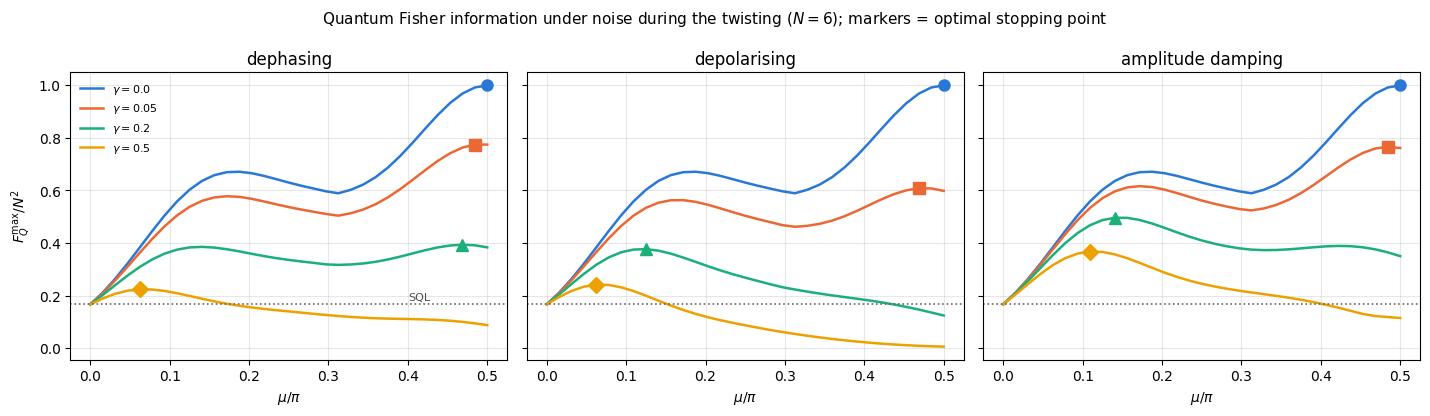

In [16]:
# ==============================================================================
# FIGURE: noisy one-axis twisting -- where to stop
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(14.4, 4.2), sharey=True)
for ax, (name, _) in zip(axes, CHANNELS):
    for k, g in enumerate(GAMMAS):
        v = sweeps[(name, g)]
        ax.plot(MU_NOISE / np.pi, v / N_NOISE ** 2, "-", color=PALETTE[k], lw=1.8,
                label=rf"$\gamma={g}$")
        i = int(np.argmax(v))
        ax.plot(MU_NOISE[i] / np.pi, v[i] / N_NOISE ** 2, MARKERS[k], color=PALETTE[k], ms=8)
    ax.axhline(1.0 / N_NOISE, color="0.4", ls=":", lw=1.2)
    ax.set_xlabel(r"$\mu/\pi$"); ax.set_title(name)
axes[0].set_ylabel(r"$F_Q^{\max}/N^2$")
axes[0].text(0.40, 1.0 / N_NOISE + 0.015, "SQL", fontsize=8, color="0.3")
axes[0].legend(fontsize=8, loc="upper left")
fig.suptitle(f"Quantum Fisher information under noise during the twisting ($N={N_NOISE}$); "
             f"markers = optimal stopping point", fontsize=11)
fig.tight_layout(); plt.show()

The noiseless curves ($\gamma=0$) climb to $F_Q/N^2=1$ at $\mu=\pi/2$, as in Section 6. Adding noise changes the shape
qualitatively, and differently for each channel.

* **Dephasing** ($Z$ noise) barely moves the optimum: as Section 10.2 explained, the cat is oriented along $\hat x$ and
  $Z$ noise is not the noise that separates its branches. At $\gamma=0.05$ the best stopping point is $\mu=1.52$ and at
  $\gamma=0.2$ it is $\mu=1.47$, both within $7\%$ of the cat time. Only at $\gamma=0.5$ does the optimum collapse to
  $\mu=0.196$, deep in the squeezing regime.
* **Depolarising** noise contains $X$ and $Y$ components, so it *does* dephase the cat in its own basis. Already at
  $\gamma=0.2$ the maximum has moved to $\mu=0.393$ — a quarter of the way to the cat — and the value at $\mu=\pi/2$
  has collapsed to $4.47$, below the standard quantum limit $N=6$. At $\gamma=0.5$ the cat retains $F_Q=0.20$: the
  state that was best in the ideal world is worse than doing nothing at all.
* **Amplitude damping** sits in between, with the optimum at $\mu=0.442$ for $\gamma=0.2$ and $\mu=0.344$ for
  $\gamma=0.5$.

This is the central practical message of the chapter. Once the noise reaches the cat's own basis, the optimal
preparation is an intermediate, partially squeezed state instead of the Heisenberg-limited cat: it gives up a factor of
a few in the ideal $F_Q$ and buys back much more in robustness. The marker on each curve is the optimal stopping point;
for the two channels whose noise reaches the cat's own basis it sits in the squeezing regime as soon as
$\gamma\ge0.2$. The last column of the table makes "squeezing regime" quantitative: the noiseless state at every such
stopping angle has a Wineland parameter $\xi_R^2<1$ ($0.455$ to $0.760$), and is therefore entangled (Sørensen *et al.*
2001).

> **Numerical practice.** Report the splitting error. Splitting Eq. (8) into a unitary and a dissipative half
> is first order in $\delta\mu$, and the printed convergence shows it (the ratio of successive differences is
> $1.96$, close to $2$): at $\gamma=0.2$ the depolarising value of
> $F_Q(\pi/2)$ moves from $4.474$ ($32$ steps) to $4.616$ ($64$) to $4.688$ ($128$), with the Richardson
> extrapolation at $4.761$ — so the $32$-step value used in the sweeps is about $6\%$ low. That is large enough to
> report and too small to change any conclusion here, because every curve in the figure is computed with the same
> $\delta\mu$ and the comparison is between them. (For the dephasing channel the split is exact, because $Z$ errors
> commute with $e^{-i\delta\mu J_z^2}$; the error there comes only from compounding $n_{\rm step}$ discrete channels.)

In [17]:
# ==============================================================================
# STEP 11: how the fragility grows with N  --  the cat under depolarising noise
# ==============================================================================
print(f"{'N':>4s} | " + " ".join(f"{'g=' + format(g, '.2f'):>10s}" for g in (0.0, 0.02, 0.05, 0.10))
      + f" | {'N^2':>6s} {'N':>4s} | {'2nd eigenvalue, g=0.10':>23s}")
frag_rows = []
for N in (3, 4, 5, 6):
    Js = [collective_dense(P, N) for P in (X, Y, Z)]
    cat = to_dm(oat_evolve(product_state("+" * N), np.pi / 2))
    vals = []
    for g in (0.0, 0.02, 0.05, 0.10):
        rho = local_channel(cat, kraus_depolarizing(g))
        w = np.array(jnp.linalg.eigvalsh(qfi_matrix_mixed(dm_matrix(rho), Js)))
        vals.append(float(w[-1]))
    frag_rows.append((N, vals))
    # w still holds the g = 0.10 spectrum: its second eigenvalue belongs to a generator PERPENDICULAR to the cat axis
    print(f"{N:4d} | " + " ".join(f"{v:10.4f}" for v in vals) + f" | {N ** 2:6d} {N:4d} | {float(w[-2]):23.4f}")

print("\nratio F_Q(g)/F_Q(0), the exponential fit  F_Q/N^2 = exp(-kappa N),  and kappa from Eq. (14a):")
for j, g in enumerate((0.02, 0.05, 0.10)):
    r = np.array([row[1][j + 1] / row[1][0] for row in frag_rows])
    Nv = np.array([row[0] for row in frag_rows], dtype=float)
    kappa = -np.polyfit(Nv, np.log(r), 1)[0]
    kappa_th = -np.log((1 - 4 * g / 3) ** 2 / (1 - 2 * g / 3))
    print(f"   gamma = {g:.2f}:  ratios " + " ".join(f"{x:.4f}" for x in r)
          + f"   ->  decay exp(-{kappa:.4f} N) per qubit;   Eq. (14a): kappa = {kappa_th:.4f}")
    assert abs(kappa - kappa_th) < 0.02 * kappa_th


def depol_cat_exact(N, g):
    """Eq. (14): F_Q(J_cat)/N^2 = (1-4g/3)^(2N) / [ (1-2g/3)^N + (2g/3)^N ]  (exact, every N and g)."""
    return (1 - 4 * g / 3) ** (2 * N) / ((1 - 2 * g / 3) ** N + (2 * g / 3) ** N)


print("\nEq. (14) (exact) and the geometric law Eq. (14a) against the computed F_Q^max / N^2:")
print(f"{'N':>4s} {'gamma':>6s} | {'F_Q/N^2 computed':>17s} {'Eq. (14)':>12s} {'|diff|':>9s} | "
      f"{'Eq. (14a)':>12s} {'rel. diff':>10s} {'[2g/(3-2g)]^N':>14s}")
for N, vals in frag_rows:
    for j, g in enumerate((0.02, 0.05, 0.10)):
        Fn = vals[j + 1] / N ** 2
        ex, geo = depol_cat_exact(N, g), ((1 - 4 * g / 3) ** 2 / (1 - 2 * g / 3)) ** N
        print(f"{N:4d} {g:6.2f} | {Fn:17.12f} {ex:12.9f} {abs(Fn - ex):9.1e} | {geo:12.9f} "
              f"{(geo - Fn) / Fn:10.2e} {(2 * g / (3 - 2 * g)) ** N:14.2e}")
        assert abs(Fn - ex) < 1e-10                                 # Eq. (14) is exact
        assert abs((geo - Fn) / Fn - (2 * g / (3 - 2 * g)) ** N) < 1e-8   # Eq. (14a) misses exactly this term

   N |     g=0.00     g=0.02     g=0.05     g=0.10 |    N^2    N |  2nd eigenvalue, g=0.10


   3 |     9.0000     7.9671     6.5859     4.6891 |      9    3 |                  1.9986
   4 |    16.0000    13.5997    10.5513     6.7109 |     16    4 |                  2.9154


   5 |    25.0000    20.4035    14.8568     8.4387 |     25    5 |                  3.6994


   6 |    36.0000    28.2110    19.2789     9.7793 |     36    6 |                  4.5037

ratio F_Q(g)/F_Q(0), the exponential fit  F_Q/N^2 = exp(-kappa N),  and kappa from Eq. (14a):
   gamma = 0.02:  ratios 0.8852 0.8500 0.8161 0.7836   ->  decay exp(-0.0406 N) per qubit;   Eq. (14a): kappa = 0.0406
   gamma = 0.05:  ratios 0.7318 0.6595 0.5943 0.5355   ->  decay exp(-0.1041 N) per qubit;   Eq. (14a): kappa = 0.1041
   gamma = 0.10:  ratios 0.5210 0.4194 0.3375 0.2716   ->  decay exp(-0.2171 N) per qubit;   Eq. (14a): kappa = 0.2172

Eq. (14) (exact) and the geometric law Eq. (14a) against the computed F_Q^max / N^2:
   N  gamma |  F_Q/N^2 computed     Eq. (14)    |diff| |    Eq. (14a)  rel. diff  [2g/(3-2g)]^N
   3   0.02 |    0.885232071117  0.885232071   1.1e-16 |  0.885234256   2.47e-06       2.47e-06
   3   0.05 |    0.731766668185  0.731766668   1.1e-16 |  0.731796672   4.10e-05       4.10e-05
   3   0.10 |    0.521007515348  0.521007515   1.3e-15 |  0.521197387   3.64e-04   

The ratio $F_Q(\gamma)/F_Q(0)$ at the cat time falls geometrically with $N$: each additional qubit multiplies the
surviving Fisher information by the same factor. The factor follows from the error bookkeeping of Section 10.2. For the
$x$-cat, a depolarising $X$ error (probability $\gamma/3$) flips the relative sign of the branches, a $Z$ error
($\gamma/3$) moves the cat onto another pair of strings, and a $Y\propto ZX$ error ($\gamma/3$) does both. Once a qubit
has suffered a $Y$ or a $Z$ error, the two equally likely signs cancel the coherence of that pair completely, so only
the strings with no $Y$ or $Z$ error contribute to the coherence. Per qubit the error-free and the $X$ terms add with
opposite signs, so the coherence between the two branches is multiplied by exactly $1-\tfrac{4\gamma}{3}$ per qubit,
i.e. by $(1-\tfrac{4\gamma}{3})^N$ in total. The *population* of the original pair has two parts: the strings with no
$Y$ or $Z$ error, probability $(1-\tfrac{2\gamma}{3})^N$, and the strings in which *every* qubit has a $Y$ or a $Z$
error, probability $(\tfrac{2\gamma}{3})^N$, which move the pair onto itself with the branches exchanged (this is the
complementary set $S^c=$ all qubits of Section 10.2). The second part carries no net coherence, because its $Y$ and
$Z$ contributions cancel qubit by qubit. All other strings land on other pairs, carry no coherence there, and do not
contribute, since $J_{\mathbf n_{\rm cat}}$ is diagonal in the cat basis. The two-level formula $F_Q=N^2C^2/t$ of
notebook 32, Eq. (16a), with coherence $C=(1-\tfrac{4\gamma}{3})^N$ and pair weight $t$, then gives the exact result

$$\frac{F_Q(J_{\mathbf n_{\rm cat}})}{N^2}
  =\frac{(1-\tfrac{4\gamma}{3})^{2N}}{(1-\tfrac{2\gamma}{3})^N+(\tfrac{2\gamma}{3})^N}. \tag{14}$$

The depolarising channel is isotropic, so the same expression holds for the $x$-cat of this notebook and the $z$-cat of
notebook 32. Dropping the second term of the denominator gives the geometric law

$$\frac{F_Q(J_{\mathbf n_{\rm cat}})}{N^2}\simeq\left[\frac{(1-\tfrac{4\gamma}{3})^2}{1-\tfrac{2\gamma}{3}}\right]^N
  \equiv e^{-\kappa N}, \tag{14a}$$

which overestimates Eq. (14) by the relative amount $\big[2\gamma/(3-2\gamma)\big]^N$. Equation (14a) is therefore exact
only at $\gamma=0$ and is otherwise an asymptotic law, accurate to $3.7\times10^{-4}$ or better for all entries of
the table ($N\ge3$, $\gamma\le0.1$); the second table confirms Eq. (14) to machine precision and resolves the
deviation of Eq. (14a) at exactly the predicted size. Equation (14a) is the $(1-2p)^{2N}$ of Eq. (12) with the
depolarising error budget. It gives $\kappa=0.0406$, $0.1041$, $0.2172$
for $\gamma=0.02$, $0.05$, $0.10$, and the fits to the four sizes reproduce these values (the cell asserts agreement to
$2\%$). At $5\%$ depolarising noise the cat retains $73\%$ of its ideal $F_Q$ at $N=3$ and $54\%$ at $N=6$; at $10\%$
the per-qubit factor is $e^{-0.217}=0.80$ and only $27\%$ survives at $N=6$.

The exponential law describes the cat axis only. The last column is the second eigenvalue of the QFI matrix at
$\gamma=0.10$, which belongs to a generator perpendicular to the cat axis; there the two branches act as two
depolarised coherent spin states, and the value grows linearly, $4.50$ at $N=6$, close to $N(1-\tfrac{4\gamma}{3})^2=0.751N$
(the Bloch vector of every qubit shrinks by $1-\tfrac{4\gamma}{3}$). Extrapolating Eq. (14a) to $N=30$ at $\gamma=0.1$ leaves
$F_Q\approx900\,e^{-0.217\times30}\approx1.3$ along the cat axis, while the perpendicular direction offers about
$0.75\times30\approx22$; the two cross near $N\approx13$. Beyond that size the best this state offers is a degraded
standard-quantum-limit measurement: the Heisenberg advantage of the cat is gone entirely.

## 12. The four protocols side by side

We can now put the whole chapter on one axis. For each $N$ and each preparation we compute $F_Q$ with the optimal
collective generator and convert it into the phase uncertainty of a single-shot experiment,

$$\Delta\theta\sqrt M=\frac{1}{\sqrt{F_Q}},$$

which is the quantum Cramér–Rao bound and, for the readouts of notebooks 31, 32 and Section 8, also the achieved value.

* **Ramsey** (nb 31): $\vert+x\rangle^{\otimes N}$, $F_Q=N$, $\Delta\theta\sqrt M=1/\sqrt N$.
* **Squeezed** (nb 33): the OAT state at the optimal $\mu$, $F_Q\ge N/\xi_R^2$ with $\xi_R^2\sim N^{-2/3}$.
* **Ideal GHZ** (nb 32): $F_Q=N^2$, $\Delta\theta\sqrt M=1/N$.
* **OAT cat** (this notebook): the same $F_Q=N^2$, prepared by letting the *same* interaction run to $\mu=\pi/2$.
* **Noisy cat and noisy squeezed**: the same quantities with depolarising noise of rate $\gamma$ acting during the
  twisting, evaluated for $N\le6$ where the density tensor fits.

In [18]:
# ==============================================================================
# STEP 12: the comparison table and figure
# ==============================================================================
# PARAMETERS ------------------------------------------------------------------
N_CMP  = (4, 6, 8, 10, 12, 14, 16)     # pure-state comparison
N_CMP_NOISY = (3, 4, 5, 6)             # density-tensor comparison
GAMMA_CMP = 0.10                       # depolarising rate for the noisy curves
# -----------------------------------------------------------------------------
ideal = {"Ramsey (CSS)": [], "squeezed (OAT, optimal $\\mu$)": [], "GHZ / OAT cat": []}
mu_best = {}
for N in N_CMP:
    ideal["Ramsey (CSS)"].append(float(N))
    grid = np.linspace(0.45, 2.0, 21) * 3 ** (1 / 6) * N ** (-2 / 3)
    vals = np.array([[float(x) for x in track_step(N, float(m))[::2]] for m in grid])
    mu_best[N] = refine_argmin(grid, vals[:, 1])
    ideal["squeezed (OAT, optimal $\\mu$)"].append(float(track_step(N, mu_best[N])[0]))
    ideal["GHZ / OAT cat"].append(float(N ** 2))

mu_stop = {}
noisy = {"noisy cat ($\\mu=\\pi/2$)": [], "noisy squeezed ($\\mu_{\\rm opt}$)": [], "best stopping point": []}
for N in N_CMP_NOISY:
    Js = [collective_dense(P, N) for P in (X, Y, Z)]
    fq = jax.jit(lambda r: jnp.linalg.eigvalsh(qfi_matrix_mixed(dm_matrix(r), Js))[-1])
    n_st, rho = 32, to_dm(product_state("+" * N))
    dmu = float(np.pi / 2 / n_st)
    K = kraus_depolarizing(GAMMA_CMP * dmu)
    step = jax.jit(lambda r: local_channel(oat_evolve_dm(r, dmu), K))
    mus_n, curve = [0.0], [float(fq(rho))]
    for s in range(n_st):
        rho = step(rho)
        mus_n.append((s + 1) * dmu)
        curve.append(float(fq(rho)))
    curve, mus_n = np.array(curve), np.array(mus_n)
    grid = np.linspace(0.45, 2.0, 21) * 3 ** (1 / 6) * N ** (-2 / 3)
    vals = np.array([[float(x) for x in track_step(N, float(m))[::2]] for m in grid])
    mu_sq = refine_argmin(grid, vals[:, 1])
    noisy["noisy cat ($\\mu=\\pi/2$)"].append(curve[-1])
    noisy["noisy squeezed ($\\mu_{\\rm opt}$)"].append(float(np.interp(mu_sq, mus_n, curve)))
    noisy["best stopping point"].append(float(curve.max()))
    mu_stop[N] = (float(mus_n[int(np.argmax(curve))]), mu_sq,
                  float(track_step(N, float(mus_n[int(np.argmax(curve))]))[0]))   # noiseless F_Q there

print(f"quantum Fisher information (ideal, pure states)\n{'N':>4s} | "
      + " ".join(f"{k:>30s}" for k in ideal) + f" {'N':>6s} {'N^2':>6s}")
for i, N in enumerate(N_CMP):
    print(f"{N:4d} | " + " ".join(f"{ideal[k][i]:30.3f}" for k in ideal) + f" {N:6d} {N ** 2:6d}")

print(f"\nwith depolarising noise, gamma = {GAMMA_CMP}, acting during the twisting\n{'N':>4s} | "
      + " ".join(f"{k:>34s}" for k in noisy) + f" {'SQL N':>7s}")
for i, N in enumerate(N_CMP_NOISY):
    print(f"{N:4d} | " + " ".join(f"{noisy[k][i]:34.3f}" for k in noisy) + f" {N:7d}")
print(f"\n{'N':>4s} | {'best stopping mu':>17s} {'Wineland mu_opt':>16s} {'noiseless F_Q at best stopping mu':>34s}")
for N in N_CMP_NOISY:
    print(f"{N:4d} | {mu_stop[N][0]:17.4f} {mu_stop[N][1]:16.4f} {mu_stop[N][2]:34.3f}")

quantum Fisher information (ideal, pure states)
   N |                   Ramsey (CSS)  squeezed (OAT, optimal $\mu$)                  GHZ / OAT cat      N    N^2
   4 |                          4.000                          8.983                         16.000      4     16
   6 |                          6.000                         17.087                         36.000      6     36
   8 |                          8.000                         27.323                         64.000      8     64
  10 |                         10.000                         39.581                        100.000     10    100
  12 |                         12.000                         53.774                        144.000     12    144
  14 |                         14.000                         69.829                        196.000     14    196
  16 |                         16.000                         87.639                        256.000     16    256

with depolarising noise, gamma = 0.1, a

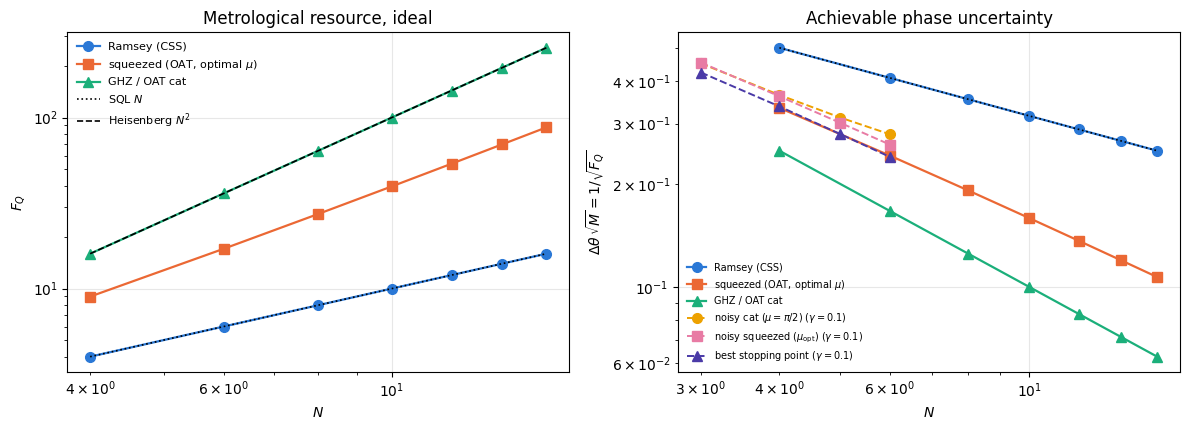

In [19]:
# ==============================================================================
# FIGURE: sensitivity of every protocol of Chapter 10 versus N
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.4))
Nc = np.array(N_CMP, dtype=float)
Nn = np.array(N_CMP_NOISY, dtype=float)

for k, (name, vals) in enumerate(ideal.items()):
    axes[0].loglog(Nc, np.array(vals), MARKERS[k] + "-", color=PALETTE[k], ms=7, lw=1.6, label=name)
axes[0].loglog(Nc, Nc, "k:", lw=1.2, label=r"SQL $N$")
axes[0].loglog(Nc, Nc ** 2, "k--", lw=1.2, label=r"Heisenberg $N^2$")
axes[0].set_xlabel("$N$"); axes[0].set_ylabel(r"$F_Q$")
axes[0].set_title("Metrological resource, ideal"); axes[0].legend(fontsize=8)

for k, (name, vals) in enumerate(ideal.items()):
    axes[1].loglog(Nc, 1 / np.sqrt(np.array(vals)), MARKERS[k] + "-", color=PALETTE[k], ms=7, lw=1.6, label=name)
for k, (name, vals) in enumerate(noisy.items()):
    axes[1].loglog(Nn, 1 / np.sqrt(np.array(vals)), MARKERS[k] + "--", color=PALETTE[k + 3], ms=7, lw=1.4,
                   label=name + rf" ($\gamma={GAMMA_CMP}$)")
axes[1].loglog(Nc, 1 / np.sqrt(Nc), "k:", lw=1.2)
axes[1].set_xlabel("$N$"); axes[1].set_ylabel(r"$\Delta\theta\,\sqrt{M}=1/\sqrt{F_Q}$")
axes[1].set_title("Achievable phase uncertainty"); axes[1].legend(fontsize=7)
fig.tight_layout(); plt.show()

The left panel is the chapter in one picture. The Ramsey line has slope $1$ on the log–log axes (the standard quantum
limit $F_Q=N$), the GHZ and OAT-cat line has slope $2$ (the Heisenberg limit $F_Q=N^2$), and the squeezed line runs in
between, with the exponent $1.668$ that Section 6 fitted over $6\le N\le16$ (an average of local slopes rising from
$1.63$ to $1.70$; the asymptotic exponent is $5/3$).

The right panel converts that into the number an experimentalist quotes, $\Delta\theta\sqrt M=1/\sqrt{F_Q}$, and adds
the noisy points. Under $10\%$ depolarising noise acting throughout, the whole hierarchy compresses: at $N=3$ the
noisy cat ($F_Q=4.94$) and the noisy squeezed state ($4.88$) are indistinguishable, both about $60\%$ above the
Ramsey value $3$; by $N=6$ the noisy squeezed state ($14.73$) has overtaken the noisy cat ($12.83$), and the best
stopping point of the noisy evolution ($17.39$) beats both. The last table locates it: at $N=6$ the noisy curve peaks
at $\mu=0.442$, well beyond the Wineland optimum $\mu_{\rm opt}=0.2685$ and far before the cat. The noiseless state there
would have $F_Q=22.91$ (the QFI keeps growing past the squeezing optimum, Section 6); the noise accumulated up to that
angle removes about a quarter of it. That the remainder ($17.39$) is close to the noiseless value at $\mu_{\rm opt}$
($17.09$) is a coincidence of these parameters. The compromise is found automatically by maximising $F_Q$ over $\mu$,
which is what an experiment does when it calibrates its interaction time.

> **Physics insight.** The gap between the two panels is the central difficulty of quantum metrology. In the ideal
> world the answer is "make a cat". With noise the answer is "make the largest $F_Q$ that survives your noise", and
> for every channel that reaches the cat's own basis at the strengths studied here that is a moderately twisted state
> with $\xi_R^2<1$. This is consistent with the experimental record summarised by Pezzè *et al.* (2018, Fig. 2): the
> Heisenberg limit has been reached only with up to about ten trapped ions, while large atomic ensembles, with their
> entanglement witnessed by spin squeezing or by the Fisher information, show gains of up to about $100$.

## 13. The readouts actually used: classical Fisher information versus $F_Q$

Every number of Sections 6–12 is a quantum Fisher information, a bound over *all* measurements. An experiment performs
one particular measurement, and what it achieves is the classical Fisher information of that measurement's outcome
distribution. This section computes it for the two readouts available in a spin ensemble, counting and parity, along
the whole twisting evolution, and compares it with $F_Q$ of the same state.

### 13.1 Fisher information of a projective measurement

A projective measurement $\{P_x\}$ of the encoded state $\rho_\theta=e^{-i\theta G}\rho\,e^{i\theta G}$ produces the
outcome $x$ with probability $p_x(\theta)=\mathrm{Tr}(P_x\rho_\theta)$. The information that one outcome carries about
$\theta$ is the score $\partial_\theta\ln p_x$, and the classical Fisher information is its mean square
(notebook 29, Eq. (13)):

$$F_C(\theta)=\sum_xp_x\left(\frac{\partial_\theta p_x}{p_x}\right)^2=\sum_{x:\,p_x>0}\frac{(\partial_\theta p_x)^2}{p_x}. \tag{15}$$

Only the probabilities and their derivatives enter. The code obtains $\partial_\theta p_x$ exactly with `jax.jacfwd`,
through the whole chain encode $\to$ rotate $\to$ $\vert\psi\vert^2$, which is what `classical_fisher` of Step 6 does.
The Braunstein–Caves inequality, proved in notebook 29, Section 5.3, states $F_C\le F_Q$ for every measurement. We
test it below on every readout and on random measurements.

A second inequality organises the comparison between readouts. Suppose the recorded outcome $y=f(x)$ is a function of a
finer outcome $x$ (the parity is a function of the count, a thresholded count is a function of the count). Then
$p_y=\sum_{x\in y}p_x$, and by the Cauchy–Schwarz inequality
$(\sum_{x\in y}\partial p_x)^2=(\sum_{x\in y}\sqrt{p_x}\,\partial p_x/\sqrt{p_x})^2\le p_y\sum_{x\in y}(\partial p_x)^2/p_x$,
so that

$$F_C[\,y\,]=\sum_y\frac{(\partial_\theta p_y)^2}{p_y}\;\le\;\sum_x\frac{(\partial_\theta p_x)^2}{p_x}=F_C[\,x\,]. \tag{16}$$

Discarding information about the outcome can only lose Fisher information. In particular, the parity measured along an
axis $\mathbf s$ can never beat full spin counting along the same axis at the same phase.

### 13.2 The two readouts

For a measurement axis $\mathbf s$, *spin counting* records the number $k$ of spins found in the $-1$ eigenstate of
$\mathbf s\cdot\boldsymbol\sigma$, i.e. $J_{\mathbf s}=N/2-k$; in the laboratory it is a collective rotation carrying
$\mathbf s$ to $\hat z$ followed by the ordinary population measurement. The *parity* along $\mathbf s$ is
$\Pi_{\mathbf s}=\prod_q(\mathbf s\cdot\boldsymbol\sigma)_q=(-1)^k$, the readout of Section 8 for $\mathbf s=\hat z$.
The encoding uses the optimal generator $G=\mathbf n_{\rm opt}\cdot\mathbf J$ of Section 6, and $\mathbf s$ is taken on
the circle perpendicular to $\mathbf n_{\rm opt}$ (measuring along $\mathbf n_{\rm opt}$ itself gives $F_C=0$,
because the distribution of $G$ does not depend on $\theta$).

**Parity along the mean spin as $\theta\to0$.** Before the eigenvalue crossing of Section 6 ($\mu\lesssim0.30\pi$) the optimal
generator is transverse, $G=n_yJ_y+n_zJ_z$. Take the parity along the mean spin, $\Pi_x=\prod_qX_q$. Two facts hold
exactly: $\Pi_x$ commutes with $J_z^2$ and leaves $\vert+x\rangle^{\otimes N}$ invariant, so $\Pi_x\vert\psi(\mu)\rangle=\vert\psi(\mu)\rangle$;
and $\Pi_x$ anticommutes with every transverse generator, $\Pi_xG\Pi_x=-G$, so $\Pi_xe^{-i\theta G}=e^{+i\theta G}\Pi_x$.
Then $\langle\Pi_x\rangle_\theta=\langle\psi\vert e^{i\theta G}\Pi_xe^{-i\theta G}\vert\psi\rangle=\langle\psi\vert e^{2i\theta G}\vert\psi\rangle$,
and the same symmetry gives $\langle G\rangle=0$. Expanding to second order,

$$p(\Pi_x=-1)=\frac{1-\langle\Pi_x\rangle_\theta}{2}=\theta^2\langle G^2\rangle+O(\theta^4),\qquad
  F_C=\frac{(\partial_\theta p_-)^2}{p_-(1-p_-)}\;\xrightarrow[\theta\to0]{}\;4\langle G^2\rangle=4\,\mathrm{Var}(G)=F_Q. \tag{17}$$

(The $O(\theta^3)$ term vanishes because $\langle\Pi_x\rangle$ is real.) So the parity along the mean spin saturates the
quantum Fisher information of every state of the squeezing side of the evolution, but only in the limit $\theta\to0$,
where the informative outcome $\Pi_x=-1$ becomes rare. After the crossing the optimal generator is $J_x$, which
*commutes* with $\Pi_x$, and the same readout carries no information at all. At the cat the parity along $\hat z$ takes
over (Section 8). Counting along $\hat x$ is a refinement of $\Pi_x$ (the parity is $(-1)^k$), so by Eq. (16) it also
reaches $F_Q$ as $\theta\to0$ before the crossing.

The derivation of Eq. (17) does not use the parity of $N$; the crossing does. The crossing, and with it everything said
below about the region after it, belongs to even $N$, the case computed here ($N=8$). For odd $N$ the cat lies along
$\hat y$ (Section 4.2), the optimal generator stays transverse all the way to $\mu=\pi/2$, there is no crossing, and
Eq. (17) applies at every twisting angle: setting `N_RD = 7` in Step 13 gives $F_C(\Pi_x)/F_Q=1$ at all $41$ angles,
the cat included.

### 13.3 Counting and parity along the twisting evolution at $N=8$

For $N=8$ and $41$ twisting angles from $0$ to $\pi/2$ the cell computes $F_Q$ and $\mathbf n_{\rm opt}$, and then
the classical Fisher information of: spin counting along the best axis of the perpendicular circle (a $7.5^\circ$ grid)
at the best working point in $\vert\theta\vert\le\pi/N$ ($17$ phases); parity along the best axis, on the same grid;
parity along the mean spin $\hat x$ at $\theta=10^{-3}$ (Eq. 17); and parity along $\hat z$, the readout of Section 8.
The checks are Eq. (16) at every grid point, $F_C\le F_Q$ for every readout, Eq. (17) before the crossing and $F_C=0$
for $\Pi_x$ after it. As the deliberately non-optimal control we measure $20$ random *product* bases at each of five
states (each qubit along its own random axis, all $2^N$ outcomes kept): they must stay below $F_Q$. A test that cannot
fail proves nothing, so the cell also checks that the same comparison against a wrongly normalised bound, $\mathrm{Var}(G)$
instead of $4\mathrm{Var}(G)$, is violated.

In [20]:
# ==============================================================================
# STEP 13: classical Fisher information of counting and parity along the OAT evolution
# ==============================================================================
# PARAMETERS ------------------------------------------------------------------
N_RD     = 8                                         # qubits (2^8 = 256 amplitudes)
MU_RD    = np.linspace(0.0, np.pi / 2, 41)           # twisting angles
BETA_RD  = np.linspace(0.0, np.pi, 25)[:-1]          # measurement axis on the circle perpendicular to n_opt
THETA_RD = np.linspace(-np.pi / N_RD, np.pi / N_RD, 17)   # working points
TH_SMALL = 1e-3                                      # "theta -> 0" for Eq. (17) and the echo of Section 14
N_RANDOM = 20                                        # random product bases per control state
# -----------------------------------------------------------------------------
_W_RD = jnp.asarray(np.eye(N_RD + 1)[[bin(i).count("1") for i in range(2 ** N_RD)]])   # basis index -> k (one-hot)
_PAR_K = jnp.asarray((-1.0) ** np.arange(N_RD + 1))                                  # parity (-1)^k
X_AXIS, Z_AXIS = jnp.array([1.0, 0.0, 0.0]), jnp.array([0.0, 0.0, 1.0])


def axis_to_z(s):
    """(angle, axis) of the rotation that carries the unit vector s onto +z.

    MATH   rotate about s x z by the angle arccos(s_z); for s = -z any perpendicular axis works (x is used).
    """
    s = jnp.asarray(s, dtype=RDTYPE)
    ax = jnp.cross(s, Z_AXIS)
    nrm = jnp.linalg.norm(ax)
    ax = jnp.where(nrm > 1e-12, ax / jnp.where(nrm > 1e-12, nrm, 1.0), X_AXIS)
    return jnp.arccos(jnp.clip(s[2], -1.0, 1.0)), ax


def count_probs(psi, s):
    """Spin counting along s: p(k) = probability that k spins are found in the -1 eigenstate of s.sigma.

    MATH   rotate s -> z collectively, then p(k) = sum_{basis states with k ones} |psi|^2  (one matrix-vector product).
    """
    ang, ax = axis_to_z(s)
    return (jnp.abs(collective_rotation(psi, ang, ax).reshape(-1)) ** 2) @ _W_RD


def parity_probs_k(p):
    """Coarse-grain a count distribution p(k) into the parity (-1)^k: [p(+1), p(-1)]."""
    pe = jnp.sum(jnp.where(_PAR_K > 0, p, 0.0))
    return jnp.stack([pe, 1.0 - pe])


def perp_circle(n, betas):
    """Unit vectors cos(b) a + sin(b) c on the great circle perpendicular to n."""
    n = np.asarray(n, dtype=float)
    a = np.cross(n, [0.0, 0.0, 1.0]) if abs(n[2]) < 0.9 else np.cross(n, [1.0, 0.0, 0.0])
    a /= np.linalg.norm(a)
    c = np.cross(n, a)
    return jnp.asarray(np.cos(betas)[:, None] * a + np.sin(betas)[:, None] * c)


@jax.jit
def fisher_grids(psi, n, S, thetas):
    """F_C of counting and of parity on the grid (axis S[i], working point thetas[j]); both share the same p(k)."""
    def one(s, th):
        cnt = lambda t: count_probs(collective_rotation(psi, t, n), s)
        return classical_fisher(cnt, th), classical_fisher(lambda t: parity_probs_k(cnt(t)), th)
    return jax.vmap(jax.vmap(one, in_axes=(None, 0)), in_axes=(0, None))(S, thetas)


@jax.jit
def fisher_parity_axis(psi, n, s, theta):
    """F_C of the parity along a FIXED axis s at the phase theta."""
    return classical_fisher(lambda t: parity_probs_k(count_probs(collective_rotation(psi, t, n), s)), theta)


@jax.jit
def fisher_echo(psi, n, mu, theta):
    """Echo readout of Section 14: encode, un-twist with exp(+i mu J_z^2), count along x (J_x)."""
    return classical_fisher(lambda t: count_probs(oat_evolve(collective_rotation(psi, t, n), -mu), X_AXIS), theta)


def local_basis_probs(psi, S):
    """All 2^N outcome probabilities when qubit q is measured along its own axis S[q] (a product basis)."""
    for q in range(psi.ndim):
        ang, ax = axis_to_z(S[q])
        U = jnp.cos(ang / 2) * I2 - 1j * jnp.sin(ang / 2) * pauli_direction(ax)
        psi = apply_gate(psi, U, [q])
    return jnp.abs(psi.reshape(-1)) ** 2


@jax.jit
def fisher_product_basis(psi, n, S, theta):
    return classical_fisher(lambda t: local_basis_probs(collective_rotation(psi, t, n), S), theta)


t0 = time.time()
rd = {key: [] for key in ("FQ", "nx", "count", "parity", "parity_x", "parity_z", "echo", "gen")}
psi_rd0 = product_state("+" * N_RD)
thetas_rd = jnp.asarray(THETA_RD)
for mu in MU_RD:
    psi = oat_evolve(psi_rd0, float(mu))
    F, n = optimal_direction(psi)
    F = float(F)
    fc, fp = (np.array(a) for a in fisher_grids(psi, n, perp_circle(n, BETA_RD), thetas_rd))
    assert np.all(fp <= fc + 1e-9 * F)                         # Eq. (16): parity is a coarse-graining of the count
    f_pz = max(float(fisher_parity_axis(psi, n, Z_AXIS, float(t))) for t in THETA_RD)
    vals = dict(FQ=F, nx=abs(float(n[0])), count=fc.max(), parity=fp.max(),
                parity_x=float(fisher_parity_axis(psi, n, X_AXIS, TH_SMALL)), parity_z=f_pz,
                echo=float(fisher_echo(psi, n, float(mu), TH_SMALL)),
                gen=float(classical_fisher(lambda t: count_probs(collective_rotation(psi, t, n), n), 0.3)))
    for key, v in vals.items():
        rd[key].append(v)
rd = {key: np.array(v) for key, v in rd.items()}
print(f"(41 twisting angles x {len(BETA_RD)} axes x {len(THETA_RD)} phases, N = {N_RD}, "
      f"in {time.time() - t0:.1f} s)\n")

print(f"{'mu':>7s} {'mu/pi':>6s} {'F_Q':>8s} | {'count, best':>11s} {'parity, best':>13s} "
      f"{'Pi_x, th->0':>12s} {'Pi_z (Sec. 8)':>14s} {'echo J_x':>9s}   (all as F_C / F_Q)")
for i in range(0, len(MU_RD), 4):
    F = rd["FQ"][i]
    print(f"{MU_RD[i]:7.4f} {MU_RD[i] / np.pi:6.3f} {F:8.3f} | {rd['count'][i] / F:11.5f} "
          f"{rd['parity'][i] / F:13.5f} {rd['parity_x'][i] / F:12.5f} {rd['parity_z'][i] / F:14.5f} "
          f"{rd['echo'][i] / F:9.5f}")

before = rd["nx"] < 1e-6                     # optimal generator transverse (before the crossing)
after = rd["nx"] > 1 - 1e-6                  # optimal generator = J_x (after the crossing)
assert np.all(before | after)                # the x block decouples: one of the two always holds
ratios = {key: rd[key] / rd["FQ"] for key in ("count", "parity", "parity_x", "parity_z", "echo")}
for key, r in ratios.items():
    assert np.all(r <= 1 + 1e-9), key        # Braunstein-Caves: F_C <= F_Q for every readout
assert np.all(np.abs(ratios["parity_x"][before] - 1) < 1e-4)   # Eq. (17)
assert np.all(ratios["parity_x"][after] < 1e-8)                # Pi_x commutes with J_x: no information
assert np.all(np.abs(ratios["echo"] - 1) < 1e-4)               # Eq. (18) of Section 14
assert np.all(rd["gen"] < 1e-10 * rd["FQ"])                     # counting along the generator: F_C = 0
assert abs(rd["parity_z"][-1] - N_RD ** 2) < 1e-6 * N_RD ** 2   # Section 8 at the cat
mu_cross = MU_RD[np.argmax(after)] if after.any() else None    # odd N: no crossing (cat along y)
if mu_cross is None:
    print(f"\noptimal generator transverse at all {len(MU_RD)} angles: no eigenvalue crossing (odd N)")
else:
    print(f"\noptimal generator transverse for mu <= {MU_RD[before].max() / np.pi:.3f} pi, along x from "
          f"mu = {mu_cross / np.pi:.3f} pi")
print(f"before the crossing: max |F_C(Pi_x, theta=1e-3)/F_Q - 1| = {np.max(np.abs(ratios['parity_x'][before] - 1)):.1e}"
      + (f";  after: max F_C(Pi_x)/F_Q = {np.max(ratios['parity_x'][after]):.1e}" if after.any() else ""))
print(f"before the crossing: best-axis counting >= {ratios['count'][before].min():.5f}, best-axis parity in "
      f"[{ratios['parity'][before].min():.5f}, {ratios['parity'][before].max():.5f}], "
      f"parity Pi_z <= {ratios['parity_z'][before].max():.4f}")
print(f"best-axis counting: min F_C/F_Q over the evolution = {ratios['count'].min():.4f} "
      f"at mu/pi = {MU_RD[np.argmin(ratios['count'])] / np.pi:.3f}")
if after.any():
    print(f"best-axis parity  : min F_C/F_Q after the crossing = {ratios['parity'][after].min():.4f} "
          f"at mu/pi = {MU_RD[after][np.argmin(ratios['parity'][after])] / np.pi:.3f}")
print(f"echo J_x at theta = 1e-3: max |F_C/F_Q - 1| = {np.max(np.abs(ratios['echo'] - 1)):.1e}")

# --- CONTROL: random product bases (deliberately non-optimal) must stay below F_Q ---------------
print(f"\nrandom product bases ({N_RANDOM} per state, random phase in |theta| < pi/N):")
key_rd = jax.random.PRNGKey(34)
worst_ratio = 0.0
for i in (0, 8, 16, 28, 40):
    psi = oat_evolve(psi_rd0, float(MU_RD[i]))
    F, n = optimal_direction(psi)
    k1, k2, key_rd = jax.random.split(key_rd, 3)
    axes_r = jax.random.normal(k1, (N_RANDOM, N_RD, 3))
    axes_r = axes_r / jnp.linalg.norm(axes_r, axis=-1, keepdims=True)
    ths = jax.random.uniform(k2, (N_RANDOM,), minval=-np.pi / N_RD, maxval=np.pi / N_RD)
    fr = np.array([float(fisher_product_basis(psi, n, axes_r[j], ths[j])) for j in range(N_RANDOM)])
    worst_ratio = max(worst_ratio, float(fr.max() / F))
    print(f"   mu/pi = {MU_RD[i] / np.pi:5.3f}  F_Q = {float(F):7.3f}   F_C/F_Q: mean {fr.mean() / float(F):.3f}, "
          f"max {fr.max() / float(F):.3f}")
    assert np.all(fr <= float(F) * (1 + 1e-9))
# --- WRONG CONTROL: the same test against a wrongly normalised bound, Var(G) = F_Q/4, must fail ----
violations = int(np.sum(rd["parity_z"] > rd["FQ"] / 4 * (1 + 1e-9)) + np.sum(rd["count"] > rd["FQ"] / 4 * (1 + 1e-9)))
print(f"largest F_C/F_Q over all random product bases: {worst_ratio:.3f}  (<= 1, as required)")
print(f"wrong control: comparing with Var(G) instead of 4 Var(G) flags {violations} of {2 * len(MU_RD)} "
      f"readout values as violations -> the test can fail")
assert violations > 0

(41 twisting angles x 24 axes x 17 phases, N = 8, in 26.2 s)

     mu  mu/pi      F_Q | count, best  parity, best  Pi_x, th->0  Pi_z (Sec. 8)  echo J_x   (all as F_C / F_Q)
 0.0000  0.000    8.000 |     1.00000       0.99906      1.00000        0.00001   1.00000
 0.1571  0.050   20.550 |     0.99999       0.99858      0.99999        0.00005   1.00000
 0.3142  0.100   34.369 |     0.99997       0.99867      1.00000        0.01686   1.00000
 0.4712  0.150   39.916 |     0.99995       0.99881      1.00000        0.05511   1.00000
 0.6283  0.200   38.746 |     0.99980       0.99860      0.99999        0.13293   1.00000
 0.7854  0.250   36.849 |     0.99981       0.99844      0.99999        0.35021   1.00000
 0.9425  0.300   36.100 |     0.99982       0.99869      1.00000        0.17165   1.00000
 1.0996  0.350   37.154 |     0.97637       0.37681      0.00000        0.37681   1.00000
 1.2566  0.400   43.851 |     0.99617       0.72292      0.00000        0.72292   1.00000
 1.4137  0.450   

   mu/pi = 0.000  F_Q =   8.000   F_C/F_Q: mean 0.515, max 0.744


   mu/pi = 0.100  F_Q =  34.369   F_C/F_Q: mean 0.151, max 0.273


   mu/pi = 0.200  F_Q =  38.746   F_C/F_Q: mean 0.141, max 0.490


   mu/pi = 0.350  F_Q =  37.154   F_C/F_Q: mean 0.127, max 0.236


   mu/pi = 0.500  F_Q =  64.000   F_C/F_Q: mean 0.066, max 0.269
largest F_C/F_Q over all random product bases: 0.744  (<= 1, as required)
wrong control: comparing with Var(G) instead of 4 Var(G) flags 62 of 82 readout values as violations -> the test can fail


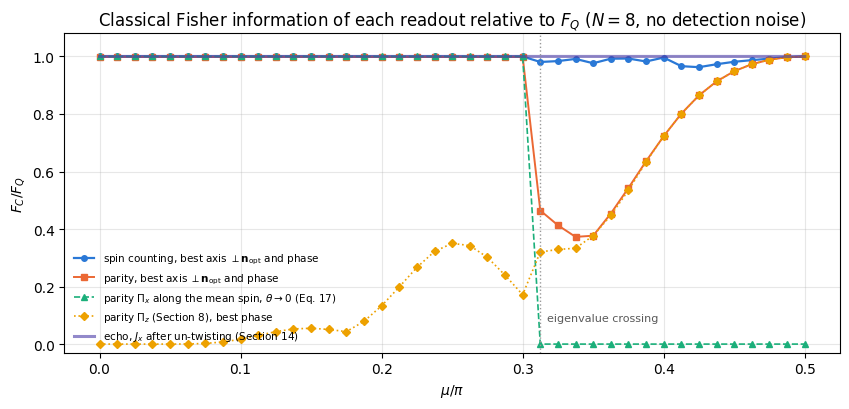

In [21]:
# ==============================================================================
# FIGURE: which readout reaches F_Q where
# ==============================================================================
fig, ax = plt.subplots(figsize=(8.6, 4.2))
x = MU_RD / np.pi
ax.plot(x, ratios["count"], "o-", color=PALETTE[0], ms=4, lw=1.6, label=r"spin counting, best axis $\perp\mathbf{n}_{\rm opt}$ and phase")
ax.plot(x, ratios["parity"], "s-", color=PALETTE[1], ms=4, lw=1.4, label=r"parity, best axis $\perp\mathbf{n}_{\rm opt}$ and phase")
ax.plot(x, ratios["parity_x"], "^--", color=PALETTE[2], ms=4, lw=1.2,
        label=r"parity $\Pi_x$ along the mean spin, $\theta\to0$ (Eq. 17)")
ax.plot(x, ratios["parity_z"], "D:", color=PALETTE[3], ms=4, lw=1.2, label=r"parity $\Pi_z$ (Section 8), best phase")
ax.plot(x, ratios["echo"], "-", color=PALETTE[5], lw=2.2, alpha=0.6, label=r"echo, $J_x$ after un-twisting (Section 14)")
if mu_cross is not None:                     # even N only
    ax.axvline(mu_cross / np.pi, color="0.6", ls=":", lw=1.0)
    ax.text(mu_cross / np.pi + 0.005, 0.08, "eigenvalue crossing", fontsize=8, color="0.35")
ax.set_xlabel(r"$\mu/\pi$"); ax.set_ylabel(r"$F_C/F_Q$"); ax.set_ylim(-0.03, 1.08)
ax.set_title(f"Classical Fisher information of each readout relative to $F_Q$ ($N={N_RD}$, no detection noise)")
ax.legend(fontsize=7.5, loc="lower left")
fig.tight_layout(); plt.show()

The table and the figure separate the evolution into three regions, with the eigenvalue crossing at
$\mu\approx0.31\pi$ (transverse optimal generator up to $0.300\pi$, $J_x$ from the next grid point, $0.3125\pi$).

* **Squeezing side, $\mu\le0.30\pi$.** Every readout except $\Pi_z$ is essentially optimal. The parity along the mean
  spin reaches $F_C/F_Q=1$ to $6\times10^{-6}$ at $\theta=10^{-3}$, as Eq. (17) requires, from the coherent state
  ($F_Q=8$) through the squeezed states to the edge of the plateau ($F_Q=36.1$ at $\mu=0.30\pi$). On the finite phase
  grid, whose smallest non-zero $\vert\theta\vert$ is $\pi/(8N)$, the best-axis parity stays at $0.998$–$0.999$, and best-axis
  counting is at least $0.9997$; both shortfalls are set by the grid, since $\Pi_x$, and by Eq. (16) counting along
  $\hat x$, reach $F_Q$ as $\theta\to0$. The parity along $\hat z$, the readout that is optimal at the cat, captures at most
  $35\%$ of $F_Q$ here.
* **Plateau, $0.31\pi\lesssim\mu<\pi/2$.** The optimal generator is now $J_x$, which commutes with $\Pi_x$, and the
  mean-spin parity carries no information ($F_C/F_Q<10^{-30}$). Among the axes of the perpendicular circle, just after
  the crossing a tilted axis gives the best parity, and from $\mu\approx0.35\pi$ on it is the parity along $\hat z$;
  the best parity on the grid falls to $0.373$ of $F_Q$ at $\mu=0.338\pi$ and is $0.377$ at $0.35\pi$. These two
  numbers belong to the restricted search: parity axes with a component along $\mathbf n_{\rm opt}$ and phases outside
  $\vert\theta\vert\le\pi/N$ were not searched and can do better. Counting along the best axis does
  much better but no longer saturates the bound: its minimum on the grid is $0.963$ at $\mu=0.425\pi$. The
  multi-component states of Section 7 spread their information over many outcomes and many directions, and a single
  axis captures most but not all of it.
* **Cat, $\mu=\pi/2$.** Parity along $\hat z$ and counting both give $F_C=N^2=F_Q$, the result of Section 8.

Equation (16) holds at every one of the $41\times24\times17$ grid points, and $F_C\le F_Q$ holds for every readout. The
random product bases are far from optimal (mean $F_C/F_Q$ between $0.07$ and $0.52$, largest single value $0.744$, at
the coherent state) and all stay below $F_Q$, while the same comparison against the wrongly normalised bound
$\mathrm{Var}(G)$ flags $62$ of the $82$ readout values, so the test has the power to fail. Counting along the
generator itself gives $F_C=0$ (asserted).

The purple line along $F_C/F_Q=1$ (partly hidden under the others before the crossing) is the echo readout of the
next section. It is the only readout in the figure that reaches $F_Q$ at
every twisting angle, but like $\Pi_x$ it does so in the limit $\theta\to0$. The next section shows when this limit
survives detection noise.

## 14. Interaction-based readout: the echo

### 14.1 The echo protocol and its Fisher information as $\theta\to0$

Section 13 found readouts that saturate $F_Q$, among them $\Pi_x$ at $\theta\to0$, which relies on the rare outcome
$\Pi_x=-1$, and $\Pi_z$ at the cat, a product over all $N$ spins. The interaction-based readout uses the twisting a second time: after the
encoding, the interaction is applied with the opposite sign, which undoes the entangling step, and the spins are then
counted along the direction of the initial coherent state,

$$\vert+x\rangle^{\otimes N}\;\xrightarrow{\;U_\mu\;}\;\vert\psi\rangle\;\xrightarrow{\;e^{-i\theta G}\;}\;
  \xrightarrow{\;U_\mu^\dagger\;}\;\vert\phi_\theta\rangle=U_\mu^\dagger e^{-i\theta G}U_\mu\vert+x\rangle^{\otimes N}
  =e^{-i\theta\tilde G}\vert+x\rangle^{\otimes N},\qquad \tilde G=U_\mu^\dagger GU_\mu ,$$

with $U_\mu=e^{-i\mu J_z^2}$ and a measurement of $J_x$, i.e. of the number $k$ of spins found in $\vert-x\rangle$.
Echo protocols of this kind were proposed by Davis, Bentsen and Schleier-Smith (2016), whose abstract states that the
one-axis-twisting interaction "can also amplify the output signal of an entanglement-enhanced interferometer to
facilitate readout", and by Macrì, Smerzi and Pezzè (2016), who show that a Loschmidt echo extracts the quantum Fisher
information of arbitrary pure states and is stable against detection errors. Colombo *et al.* (2022) realised the
reversal experimentally by changing the sign of an optically engineered interaction in an ensemble of $350$
${}^{171}$Yb atoms.

The outcome $k=0$ means that the state has returned to $\vert+x\rangle^{\otimes N}$. Its probability is a fidelity,
and the same expansion as in Eq. (17) gives
$p_0(\theta)=\vert\langle+x\vert^{\otimes N}e^{-i\theta\tilde G}\vert+x\rangle^{\otimes N}\vert^2
=1-\theta^2\,\mathrm{Var}_{+x}(\tilde G)+O(\theta^4)$, with $\mathrm{Var}_{+x}(\tilde G)=\mathrm{Var}_\psi(G)=F_Q/4$.
The two-outcome readout "returned / not returned" has Fisher information
$(\partial_\theta p_0)^2/[p_0(1-p_0)]\to(\theta F_Q/2)^2/(\theta^2F_Q/4)=F_Q$. Counting $k$ is a refinement of that
readout, so by Eq. (16) its Fisher information is at least as large, and by the Braunstein–Caves inequality it is at
most $F_Q$. Hence

$$\lim_{\theta\to0}F_C^{\rm echo}(\theta)=F_Q(\mu)\qquad\text{for every twisting angle }\mu. \tag{18}$$

Step 13 confirmed Eq. (18) at all $41$ angles (the purple curve of the last figure). At the cat time more is true. For
even $N$, $U_{\pi/2}$ maps $\mathrm{span}\{\vert+x\rangle^{\otimes N},\vert-x\rangle^{\otimes N}\}$ into itself: by
Eq. (3), $U\vert+x\rangle^{\otimes N}=\alpha\vert+x\rangle^{\otimes N}+\beta\vert-x\rangle^{\otimes N}$ with
$\alpha=e^{-i\pi/4}/\sqrt2$, $\beta=(-1)^{N/2}e^{i\pi/4}/\sqrt2$, and since $\prod_qZ_q$ commutes with $U$ and swaps the
two product states, $U\vert-x\rangle^{\otimes N}=\alpha\vert-x\rangle^{\otimes N}+\beta\vert+x\rangle^{\otimes N}$. The
encoding $e^{-i\theta J_x}$ multiplies the two branches by $e^{\mp iN\theta/2}$, and the amplitude of
$\vert+x\rangle^{\otimes N}$ after $U^\dagger$ is $\vert\alpha\vert^2e^{-iN\theta/2}+\vert\beta\vert^2e^{iN\theta/2}=\cos(N\theta/2)$. The
echo therefore produces only $k=0$ or $k=N$,

$$p_0=\cos^2\frac{N\theta}{2},\qquad p_N=\sin^2\frac{N\theta}{2},\qquad
  F_C^{\rm echo}=\frac{(\partial_\theta p_0)^2}{p_0p_N}=N^2\quad(\theta\ne0\bmod\pi/N). \tag{19}$$

The derivation uses the even-$N$ propagator of Eq. (3). For odd $N$ the cat lies along $\hat y$ and the generator is
$J_y$; the same two-outcome result holds numerically: with `N_RD = 7` the checks at the start of Step 14 (only $k=0$
and $k=N$ occur, $p_0=\cos^2(N\theta/2)$) pass unchanged.

### 14.2 Detection noise

Model the detector as misreading each spin independently with probability $\epsilon$. A true count $k$ is then recorded
as $k-j+l$, with $j\sim\mathrm{Bin}(k,\epsilon)$ of the $k$ spins found in the $-1$ state misread and $l\sim\mathrm{Bin}(N-k,\epsilon)$
of the others, so the recorded distribution is $\tilde p=Tp$ with

$$T_{k'k}=\sum_{j,l\,:\,k-j+l=k'}\binom kj\binom{N-k}{l}\epsilon^{j+l}(1-\epsilon)^{N-j-l}. \tag{20}$$

The effect on an observable depends on its weight. A single-spin outcome $\sigma=\pm1$ is recorded with mean
$(1-2\epsilon)\sigma$, and independent misreads multiply, so the mean of a product of $w$ single-spin outcomes is
multiplied by $(1-2\epsilon)^w$. The parity has weight $N$: its visibility in Eq. (7) becomes
$\mathcal A=(1-2\epsilon)^N$, and the best Fisher information over the phase is

$$F_C^{\rm parity}=N^2(1-2\epsilon)^{2N}. \tag{21}$$

For the echo at the cat, the two noiseless outcomes $k=0$ and $k=N$ become the two binomial distributions
$a_k=\mathrm{Bin}(k;N,\epsilon)$ and $b_k=a_{N-k}$, and $\tilde p_k=p_0a_k+p_Nb_k$. Writing $m_k=p_0a_k+p_Nb_k$ and
using $a_k-b_k=(a_k-m_k)/p_N=(m_k-b_k)/p_0$, a two-line rearrangement of Eq. (15) gives the exact result

$$F_C^{\rm echo}=\frac{(\partial_\theta p_0)^2}{p_0p_N}\Big[1-\sum_k\frac{a_kb_k}{p_0a_k+p_Nb_k}\Big]
  =N^2\Big[1-\sum_k\frac{a_kb_k}{p_0a_k+p_Nb_k}\Big], \tag{22}$$

and since $p_0a_k+p_Nb_k\ge2\sqrt{p_0p_Na_kb_k}$, the loss is bounded by the overlap of the two binomials,

$$1-\frac{F_C^{\rm echo}}{N^2}\;\le\;\frac{\sum_k\sqrt{a_kb_k}}{2\sqrt{p_0p_N}}
  =\frac{\big[2\sqrt{\epsilon(1-\epsilon)}\big]^N}{2\sqrt{p_0p_N}}
  \;\overset{p_0=p_N=1/2}{=}\;\big[4\epsilon(1-\epsilon)\big]^{N/2}. \tag{23}$$

This is the mechanism of the robustness. Un-twisting moves the phase information from the relative phase of two
branches, readable only through a weight-$N$ observable, into the *sign* of the collective spin $J_x$, i.e. into the
populations of two outcomes that differ by $N$ spin flips. A misread spin changes the parity, but it changes $k$ by
one, and confusing $k=0$ with $k=N$ needs about $N/2$ misreads. Equation (21) decays like $(1-2\epsilon)^{2N}$;
the loss in Eq. (23) is of order $\epsilon^{N/2}$.

At every twisting angle the noiseless echo has $p_k(0)=0$ for $k\ge1$ and $p_0(0)=1$, so every $p_k(\theta)$ is
extremal at $\theta=0$ and $\partial_\theta p_k(0)=0$. With $\epsilon>0$ every
recorded probability $\tilde p_k(0)=T_{k0}$ is positive while every derivative still vanishes, hence

$$F_C^{\rm echo}(\theta)\;=\;O(\theta^2)\;\xrightarrow[\theta\to0]{}\;0\qquad(\epsilon>0). \tag{24}$$

At the cat this costs nothing, because the fringe of Eq. (19) offers the mid-fringe working point, where the two
outcomes are $N$ misreads apart. For $\mu<\pi/2$ the limit of Eq. (18) is lost, the working point must move to a
finite $\theta$, and there the signal populates small $k$, one or two misreads away from the background. Step 14
measures how much survives.

In [22]:
# ==============================================================================
# STEP 14: the echo readout with detection noise, against parity and direct counting
# ==============================================================================
# PARAMETERS ------------------------------------------------------------------
EPS_RD   = np.linspace(0.0, 0.15, 16)                 # probability of misreading one spin
MU_MID   = 0.3                                        # an intermediate twisting angle
TH_ECHO_CAT = np.linspace(0.0, np.pi / N_RD, 65)[1:-1]     # working points inside one echo fringe (mid point included)
TH_PAR_CAT  = np.linspace(-np.pi / (2 * N_RD), np.pi / (2 * N_RD), 33)   # parity: zero crossing included
TH_ECHO_MID = np.linspace(TH_SMALL, np.pi / 2, 160)
# -----------------------------------------------------------------------------


def detection_matrix(N, eps):
    """T[k', k] of Eq. (20): probability to record k' when k spins are truly in |1>."""
    T = np.zeros((N + 1, N + 1))
    for k in range(N + 1):
        for j in range(k + 1):
            for l in range(N - k + 1):
                T[k - j + l, k] += (math.comb(k, j) * math.comb(N - k, l)
                                    * eps ** (j + l) * (1 - eps) ** (N - j - l))
    return jnp.asarray(T)


@jax.jit
def noisy_fisher_echo(psi, n, mu, T, thetas):
    f = lambda th: classical_fisher(
        lambda t: T @ count_probs(oat_evolve(collective_rotation(psi, t, n), -mu), X_AXIS), th)
    return jax.vmap(f)(thetas)


@jax.jit
def noisy_fisher_grids(psi, n, S, T, thetas):
    """Counting and parity with detection noise, on the (axis, phase) grid of Step 13."""
    def one(s, th):
        cnt = lambda t: T @ count_probs(collective_rotation(psi, t, n), s)
        return classical_fisher(cnt, th), classical_fisher(lambda t: parity_probs_k(cnt(t)), th)
    return jax.vmap(jax.vmap(one, in_axes=(None, 0)), in_axes=(0, None))(S, thetas)


# --- the cat: two-level structure of the echo, Eq. (19) --------------------------------------
psi_c = oat_evolve(psi_rd0, np.pi / 2)
F_c, n_c = optimal_direction(psi_c)
for th in (0.05, np.pi / (2 * N_RD), 0.3):
    p = count_probs(oat_evolve(collective_rotation(psi_c, th, n_c), -np.pi / 2), X_AXIS)
    assert float(jnp.sum(p[1:N_RD])) < 1e4 * TOL                       # only k = 0 and k = N occur
    assert abs(float(p[0]) - np.cos(N_RD * th / 2) ** 2) < 1e4 * TOL     # p_0 = cos^2(N theta / 2)
print(f"cat, N = {N_RD}: echo populates only k = 0 and k = N, with p_0 = cos^2(N theta/2)  (checked at 3 phases)\n")

psi_m = oat_evolve(psi_rd0, MU_MID)
F_m, n_m = optimal_direction(psi_m)
S_m = perp_circle(n_m, BETA_RD)
t0 = time.time()
rows_eps = []
for eps in EPS_RD:
    T = detection_matrix(N_RD, float(eps))
    # cat: parity (Section 8 readout) and echo
    f_par = max(float(classical_fisher(lambda t: parity_probs_k(T @ count_probs(collective_rotation(psi_c, t, n_c),
                                                                                    Z_AXIS)), float(th)))
                for th in TH_PAR_CAT)
    fe_c = np.array(noisy_fisher_echo(psi_c, n_c, np.pi / 2, T, jnp.asarray(TH_ECHO_CAT)))
    # Eq. (22) at mid-fringe (p_0 = p_N = 1/2), and the bound Eq. (23)
    a = np.array([math.comb(N_RD, k) * eps ** k * (1 - eps) ** (N_RD - k) for k in range(N_RD + 1)])
    eq22 = N_RD ** 2 * (1 - np.sum(np.where(a + a[::-1] > 0, a * a[::-1] / np.where(a + a[::-1] > 0, 0.5 * (a + a[::-1]), 1.0), 0.0)))
    f_mid = fe_c[len(TH_ECHO_CAT) // 2]
    # intermediate twisting angle: echo (best phase and theta -> 0), direct counting and parity (best axis and phase)
    fe_m = np.array(noisy_fisher_echo(psi_m, n_m, MU_MID, T, jnp.asarray(TH_ECHO_MID)))
    fcm, fpm = (np.array(x) for x in noisy_fisher_grids(psi_m, n_m, S_m, T, thetas_rd))
    rows_eps.append(dict(eps=float(eps), par_c=f_par, eq21=N_RD ** 2 * (1 - 2 * eps) ** (2 * N_RD),
                         echo_c=fe_c.max(), echo_mid=f_mid, eq22=eq22,
                         bound=N_RD ** 2 * (1 - (4 * eps * (1 - eps)) ** (N_RD / 2)),
                         echo_m=fe_m.max(), th_m=float(TH_ECHO_MID[np.argmax(fe_m)]), echo_m0=float(fe_m[0]),
                         echo_m_pin=fe_m[TH_ECHO_MID <= np.pi / N_RD].max(),
                         count_m=fcm.max(), par_m=fpm.max()))
print(f"(detection-noise scan: {len(EPS_RD)} values of epsilon in {time.time() - t0:.1f} s)\n")

print(f"cat (mu = pi/2), N = {N_RD}, F_Q = {float(F_c):.3f}")
print(f"{'eps':>6s} | {'parity':>9s} {'Eq. (21)':>9s} | {'echo, best':>10s} {'echo, mid':>10s} {'Eq. (22)':>10s} "
      f"{'Eq. (23) bound':>15s}")
for r in rows_eps:
    print(f"{r['eps']:6.3f} | {r['par_c']:9.4f} {r['eq21']:9.4f} | {r['echo_c']:10.4f} {r['echo_mid']:10.4f} "
          f"{r['eq22']:10.4f} {r['bound']:15.4f}")
    assert abs(r["par_c"] - r["eq21"]) < 1e-8 * N_RD ** 2              # Eq. (21)
    assert abs(r["echo_mid"] - r["eq22"]) < 1e-8 * N_RD ** 2           # Eq. (22)
    assert r["echo_mid"] >= r["bound"] - 1e-9                          # Eq. (23)
    assert r["echo_c"] <= float(F_c) * (1 + 1e-9) and r["par_c"] <= float(F_c) * (1 + 1e-9)

print(f"\nmu = {MU_MID}, N = {N_RD}, F_Q = {float(F_m):.3f}   (best axis and phase for counting and parity)")
print(f"{'eps':>6s} | {'echo, best':>10s} {'at theta':>9s} {'echo, theta=1e-3':>17s} | {'counting':>9s} {'parity':>9s}")
for r in rows_eps:
    print(f"{r['eps']:6.3f} | {r['echo_m']:10.4f} {r['th_m']:9.4f} {r['echo_m0']:17.3e} | {r['count_m']:9.4f} "
          f"{r['par_m']:9.4f}")
    assert max(r["echo_m"], r["count_m"], r["par_m"]) <= float(F_m) * (1 + 1e-9)
    if r["eps"] > 0:
        assert r["echo_m0"] < 1e-2 * float(F_m)                       # Eq. (24): the theta -> 0 limit is lost

# where the signal sits: noiseless echo distribution at the noisy optimum (eps = 0.05)
r05 = min(rows_eps, key=lambda r: abs(r["eps"] - 0.05))
print(f"\necho at eps = 0.05 with the working point restricted to theta <= pi/N = {np.pi / N_RD:.3f}: "
      f"{r05['echo_m_pin']:.4f}  (unrestricted: {r05['echo_m']:.4f} at theta = {r05['th_m']:.3f})")
p_opt = np.array(count_probs(oat_evolve(collective_rotation(psi_m, r05["th_m"], n_m), -MU_MID), X_AXIS))
print(f"\nnoiseless echo distribution p(k) at mu = {MU_MID}, theta = {r05['th_m']:.3f} (the eps = 0.05 optimum): "
      + " ".join(f"{x:.3f}" for x in p_opt))

cat, N = 8: echo populates only k = 0 and k = N, with p_0 = cos^2(N theta/2)  (checked at 3 phases)



(detection-noise scan: 16 values of epsilon in 91.0 s)

cat (mu = pi/2), N = 8, F_Q = 64.000
   eps |    parity  Eq. (21) | echo, best  echo, mid   Eq. (22)  Eq. (23) bound
 0.000 |   64.0000   64.0000 |    64.0000    64.0000    64.0000         64.0000
 0.010 |   46.3231   46.3231 |    64.0000    64.0000    64.0000         63.9998
 0.020 |   33.3058   33.3058 |    63.9993    63.9993    63.9993         63.9976
 0.030 |   23.7808   23.7808 |    63.9965    63.9965    63.9965         63.9883
 0.040 |   16.8572   16.8572 |    63.9889    63.9889    63.9889         63.9644
 0.050 |   11.8593   11.8593 |    63.9733    63.9733    63.9733         63.9166
 0.060 |    8.2776    8.2776 |    63.9451    63.9451    63.9451         63.8342
 0.070 |    5.7300    5.7300 |    63.8995    63.8995    63.8995         63.7057
 0.080 |    3.9323    3.9323 |    63.8306    63.8306    63.8306         63.5192
 0.090 |    2.6742    2.6742 |    63.7320    63.7320    63.7320         63.2629
 0.100 |    1.8014    1.801

In [23]:
# ==============================================================================
# STEP 14b: the noise model and the Fisher numbers checked on sampled data (cat, eps = 0.05)
# ==============================================================================
# PARAMETERS ------------------------------------------------------------------
EPS_CHK  = 0.05
M_CHK    = 20_000             # shots for the histogram check of Eq. (20)
M_EST, R_EST = 200, 400        # shots per experiment, experiments per readout (maximum likelihood)
# -----------------------------------------------------------------------------
T_chk = detection_matrix(N_RD, EPS_CHK)
th_mid = np.pi / (2 * N_RD)
phi_mid = oat_evolve(collective_rotation(psi_c, th_mid, n_c), -np.pi / 2)        # echo output state
ang_x, ax_x = axis_to_z(X_AXIS)
k_bits, k_flip = jax.random.split(jax.random.PRNGKey(2027))
bits = np.array(sample_bitstrings(k_bits, collective_rotation(phi_mid, ang_x, ax_x), M_CHK))   # x-basis shots
flips = np.array(jax.random.bernoulli(k_flip, EPS_CHK, bits.shape)).astype(int)
k_noisy, k_clean = (bits ^ flips).sum(axis=1), bits.sum(axis=1)
p_pred = np.array(T_chk @ count_probs(phi_mid, X_AXIS))
ok = M_CHK * p_pred >= 20                                                           # bins with >= 20 expected counts
hist_n = np.bincount(k_noisy, minlength=N_RD + 1)
hist_c = np.bincount(k_clean, minlength=N_RD + 1)
z_n = (hist_n - M_CHK * p_pred) / np.sqrt(M_CHK * p_pred * (1 - p_pred))
z_c = (hist_c - M_CHK * p_pred) / np.sqrt(M_CHK * p_pred * (1 - p_pred))
print(f"{M_CHK} sampled echo shots at the cat, theta = pi/(2N), each spin misread with probability {EPS_CHK}:")
print(f"   {'k':>3s} " + " ".join(f"{k:8d}" for k in range(N_RD + 1)))
print(f"   {'Tp':>3s} " + " ".join(f"{M_CHK * x:8.1f}" for x in p_pred))
print(f"   {'obs':>3s} " + " ".join(f"{x:8d}" for x in hist_n))
print(f"largest |z| over the {int(ok.sum())} bins with >= 20 expected counts: {np.max(np.abs(z_n[ok])):.2f}")
print(f"wrong control (misreads not applied): largest |z| = {np.max(np.abs(z_c[ok])):.0f}  -> must fail")
assert np.max(np.abs(z_n[ok])) < 4.0
assert np.max(np.abs(z_c[ok])) > 10.0


def ml_spread(prob_fn, theta_true, grid, key):
    """R_EST experiments of M_EST noisy shots each; maximum-likelihood estimate on `grid`; returns the estimates."""
    logp = jnp.log(jnp.clip(jax.vmap(prob_fn)(grid), 1e-300, None))           # (grid, outcomes)
    lp_true = jnp.log(jnp.clip(prob_fn(theta_true), 1e-300, None))

    def one(k):
        counts = jnp.bincount(jax.random.categorical(k, lp_true, shape=(M_EST,)), length=lp_true.shape[0])
        return grid[jnp.argmax(logp @ counts)]

    return np.array(jax.vmap(one)(jax.random.split(key, R_EST)))


echo_noisy = lambda t: T_chk @ count_probs(oat_evolve(collective_rotation(psi_c, t, n_c), -np.pi / 2), X_AXIS)
par_noisy = lambda t: parity_probs_k(T_chk @ count_probs(collective_rotation(psi_c, t, n_c), Z_AXIS))
k_e, k_p = jax.random.split(jax.random.PRNGKey(2028))
est_e = ml_spread(echo_noisy, th_mid, jnp.linspace(0.0, np.pi / N_RD, 801), k_e)
est_p = ml_spread(par_noisy, 0.0, jnp.linspace(-th_mid, th_mid, 801), k_p)
se_rel = np.sqrt(2 / (R_EST - 1))
print(f"\nmaximum likelihood, {R_EST} experiments x {M_EST} shots, eps = {EPS_CHK} (relative s.e. of a variance "
      f"{se_rel:.3f}):")
for name, est, th_true, fn in (("echo  ", est_e, th_mid, echo_noisy), ("parity", est_p, 0.0, par_noisy)):
    Fc = float(classical_fisher(fn, th_true))
    v = float(np.var(est))
    print(f"   {name}: F_C = {Fc:7.3f}   bias {np.mean(est) - th_true:+.5f} +- {np.sqrt(v / R_EST):.5f}   "
          f"Delta theta = {np.sqrt(v):.5f}   1/sqrt(M F_C) = {1 / np.sqrt(M_EST * Fc):.5f}   M F_C Var = {M_EST * Fc * v:.3f}")
    assert abs(M_EST * Fc * v - 1) < 4 * se_rel
print(f"   measured variance ratio parity/echo = {np.var(est_p) / np.var(est_e):.2f}   "
      f"(Fisher prediction {float(classical_fisher(echo_noisy, th_mid)) / float(classical_fisher(par_noisy, 0.0)):.2f})")

20000 sampled echo shots at the cat, theta = pi/(2N), each spin misread with probability 0.05:
     k        0        1        2        3        4        5        6        7        8
    Tp   6634.2   2793.3    514.6     54.3      7.1     54.3    514.6   2793.3   6634.2
   obs     6598     2768      538       52        3       49      539     2744     6709
largest |z| over the 8 bins with >= 20 expected counts: 1.12
wrong control (misreads not applied): largest |z| = 57  -> must fail



maximum likelihood, 400 experiments x 200 shots, eps = 0.05 (relative s.e. of a variance 0.071):


   echo  : F_C =  63.973   bias +0.00028 +- 0.00044   Delta theta = 0.00888   1/sqrt(M F_C) = 0.00884   M F_C Var = 1.008


   parity: F_C =  11.859   bias +0.00055 +- 0.00103   Delta theta = 0.02055   1/sqrt(M F_C) = 0.02053   M F_C Var = 1.001


   measured variance ratio parity/echo = 5.36   (Fisher prediction 5.39)


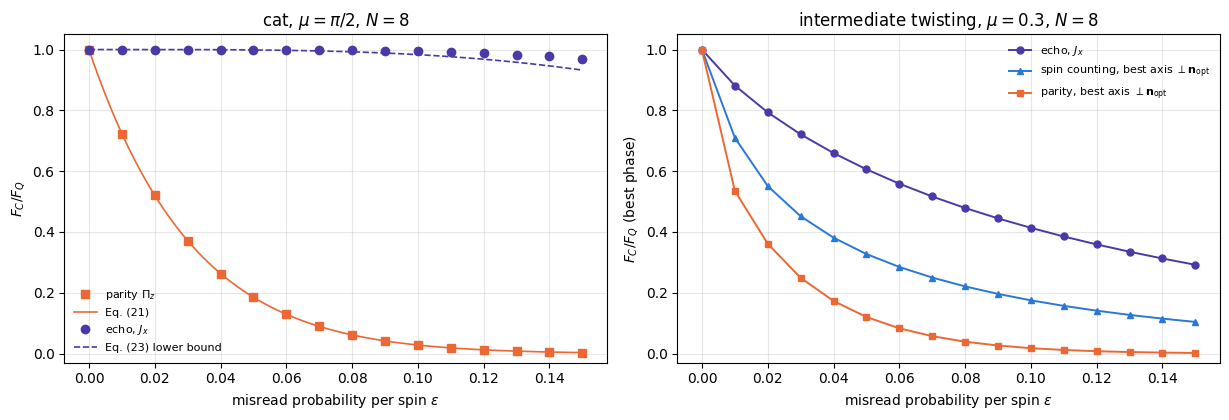

In [24]:
# ==============================================================================
# FIGURE: detection noise -- parity against the echo
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.3))
e = np.array([r["eps"] for r in rows_eps])
ef = np.linspace(0, EPS_RD[-1], 200)
axes[0].plot(e, [r["par_c"] / N_RD ** 2 for r in rows_eps], "s", color=PALETTE[1], ms=6, label="parity $\\Pi_z$")
axes[0].plot(ef, (1 - 2 * ef) ** (2 * N_RD), "-", color=PALETTE[1], lw=1.2, label="Eq. (21)")
axes[0].plot(e, [r["echo_c"] / N_RD ** 2 for r in rows_eps], "o", color=PALETTE[5], ms=6, label="echo, $J_x$")
axes[0].plot(ef, 1 - (4 * ef * (1 - ef)) ** (N_RD / 2), "--", color=PALETTE[5], lw=1.2, label="Eq. (23) lower bound")
axes[0].set_xlabel(r"misread probability per spin $\epsilon$"); axes[0].set_ylabel(r"$F_C/F_Q$")
axes[0].set_title(f"cat, $\\mu=\\pi/2$, $N={N_RD}$"); axes[0].legend(fontsize=8); axes[0].set_ylim(-0.03, 1.05)
for key, lab, mk, col in (("echo_m", "echo, $J_x$", "o-", PALETTE[5]), ("count_m", r"spin counting, best axis $\perp\mathbf{n}_{\rm opt}$", "^-",
                                                                         PALETTE[0]),
                          ("par_m", r"parity, best axis $\perp\mathbf{n}_{\rm opt}$", "s-", PALETTE[1])):
    axes[1].plot(e, [r[key] / float(F_m) for r in rows_eps], mk, color=col, ms=5, lw=1.4, label=lab)
axes[1].set_xlabel(r"misread probability per spin $\epsilon$"); axes[1].set_ylabel(r"$F_C/F_Q$ (best phase)")
axes[1].set_title(f"intermediate twisting, $\\mu={MU_MID}$, $N={N_RD}$"); axes[1].legend(fontsize=8)
axes[1].set_ylim(-0.03, 1.05)
fig.tight_layout(); plt.show()

The two tables of Step 14 and the sampling checks of Step 14b give the following.

* **The cat is protected.** At $\epsilon=0.05$ the parity has lost $81\%$ of its Fisher information, $11.86$
  against $64$, exactly Eq. (21), while the echo keeps $63.97$, exactly Eq. (22) and above the bound $63.92$ of
  Eq. (23). At $\epsilon=0.15$ the parity is down to $0.21$, below the value $1$ of a single unentangled spin,
  and the echo still delivers $62.1$, $97\%$ of the Heisenberg limit. The best echo working point is the
  mid-fringe $\theta=\pi/(2N)$ at every $\epsilon$ (the best and mid-fringe columns coincide).
* **Away from the cat the echo degrades.** At $\mu=0.3$ ($F_Q=33.39$) the echo falls to $20.23$ at $\epsilon=0.05$
  and $9.75$ at $\epsilon=0.15$. As Eq. (24) predicts, its value at $\theta=10^{-3}$ collapses ($1.2\times10^{-3}$ at
  $\epsilon=0.05$), and the best working point moves out to $\theta\approx0.42$, i.e. $N\theta\approx3.3$. The noiseless
  distribution printed at that point shows where the signal sits: $p(k=1)=0.55$ and $p(k=0)=0.17$, so most of the
  information is in outcomes one misread away from each other. The echo is still the best of the three readouts
  at this angle: direct counting along the best axis gives $10.93$ and the best parity $4.02$ at $\epsilon=0.05$.
  (Restricting the echo working point to $\theta\le\pi/N=0.393$, the phase range of the other two readouts, gives
  $20.09$ on the same grid instead of $20.23$, because the optimum lies just outside it; the echo remains the best
  readout.)
* **The noise model and the Fisher numbers survive sampling.** The histogram of $20\,000$ simulated noisy shots matches
  $Tp$ of Eq. (20) in all eight bins with at least $20$ expected counts (largest deviation $1.1$ standard
  deviations); the same shots without misreads deviate by $57$ standard deviations from the noisy prediction. Maximum
  likelihood on $400$ experiments of $200$ noisy shots each gives $MF_C\,\mathrm{Var}=1.008$ for the echo and $1.001$
  for the parity, both within one standard error ($0.071$) of the Cramér–Rao value, with no detectable bias. The
  measured variance ratio parity/echo is $5.36$ against the Fisher prediction $5.39$: at $5\%$ misreads the parity
  readout needs about $5.4$ times more repetitions for the same error bar.

> **Physics insight.** The cat stores its phase in a coherence between two branches that differ on every spin, and only
> an observable that touches every spin, the parity, can read it directly; that observable inherits a factor
> $1-2\epsilon$ from each spin. Running the interaction backwards converts the coherence into a population difference
> between $\vert+x\rangle^{\otimes N}$ and $\vert-x\rangle^{\otimes N}$, which a coarse detector resolves easily. The
> protection is specific to the cat time: at intermediate twisting the echo still beats the other readouts, but the
> signal lands on small $k$, next to the bright outcome $k=0$, and the misreads blur it.

## 15. Key takeaways

* $e^{-i\frac{\pi}{2}J_z^2}$ acting on a coherent spin state produces a **GHZ-like cat**, exactly. For even $N$ the
  propagator collapses to $\frac{e^{-i\pi/4}}{\sqrt2}\mathbb 1+\frac{e^{i\pi/4}}{\sqrt2}(-1)^{N/2}\prod_qZ_q$ and the cat
  lies along $\hat x$, Eq. (3); for odd $N$ the half-integer spectrum makes the phase $4$-periodic in $m$, the
  propagator becomes $\frac{e^{-i\pi/8}}{\sqrt2}\left(e^{i\frac{\pi}{2}J_z}+e^{-i\frac{\pi}{2}J_z}\right)$, and the cat
  lies along $\hat y$, Eq. (5). Both were verified by fidelity $1$ including the global phase.
* The diagonal propagator and the circuit of $N(N-1)/2$ commuting $R_{ZZ}(\mu)$ gates agree to $10^{-15}$: no Trotter
  error, because all the terms are diagonal.
* The $3\times3$ QFI matrix tracks the state along the evolution. $F_Q^{\max}$ goes $N$ (at $\mu=0$) $\to$
  $\simeq N+3^{1/3}N^{5/3}$ at the squeezing optimum (fitted exponent $1.668$ over $6\le N\le16$, local slopes
  $1.63$–$1.70$) $\to$ a plateau at $0.577$ ($N=8$), $0.543$ ($N=12$), $0.531$ ($N=16$) times $N^2$, close to the lobe
  model $\tfrac12+\tfrac1{2N}$ $\to$ exactly $N^2$ at $\mu=\pi/2$; its eigenvector jumps onto the cat axis $\hat x$ at
  $\mu\approx0.30\pi$ and stays there.
* At $\mu=\pi/q$ the state is a $q$-component cat — an automatic lobe count on the Husimi equator finds exactly
  $2,3,4,5$ lobes for $q=2,3,4,5$ at $N=12$, and fewer beyond that because the components start to overlap. Two
  antipodal lobes give $F_Q=N^2$; $q\ge3$ lobes around a circle give $F_Q/N^2$ between $0.54$ and $0.58$, the origin
  of the plateau.
* Encoding with the cat axis and measuring the **parity** $\prod_qZ_q$ gives a fringe of period $2\pi/N$ with full
  visibility, whose classical Fisher information equals $F_Q=N^2$ at every phase but the two fringe extrema. Maximum
  likelihood on sampled parities reaches $\Delta\theta=1/(N\sqrt M)$ over the whole range $M=25$ to $M=800$ — but only
  inside a search window of half a fringe.
* Local dephasing in the cat's own basis gives the exact law $F_Q=N^2(1-2p)^{2N}\simeq N^2e^{-4N\gamma\mu}$, verified
  to $3\times10^{-14}$: the decoherence rate of the $N$-body coherence is $N$ times the single-qubit rate. Which
  laboratory noise is deadly depends on the cat's orientation — the OAT cat lies along $\hat x$, and at $N=6$ its
  $F_Q$ under $Z$ dephasing beats the value under $X$-type noise by a factor $1.5$ at $p=0.02$, $3.0$ at $p=0.05$
  and $4.2$ at $p=0.10$, following the polynomial law of Eq. (13) instead of the exponential law of Eq. (12).
  Under depolarising noise the cat-axis QFI follows Eq. (14) exactly, and the geometric law $e^{-\kappa N}$ of Eq. (14a) up to a relative correction $[2\gamma/(3-2\gamma)]^N$.
* With depolarising or amplitude-damping noise at $\gamma\ge0.2$ the maximum of $F_Q(\mu)$ moves out of the cat and
  into the squeezing regime ($\xi_R^2<1$ at the stopping angle). Measured at $N=6$, $\gamma=0.2$: the depolarising optimum sits at $\mu=0.393$ with
  $F_Q=13.6$, while the cat at $\mu=\pi/2$ has fallen to $4.47$, below the standard quantum limit $N=6$.
* The unitary/dissipative splitting is first order in $\delta\mu$; the $32$-step value used in the sweeps is about
  $6\%$ below the Richardson extrapolation.
* The readouts actually used, $N=8$: before the eigenvalue crossing the parity along the mean spin saturates $F_Q$ as
  $\theta\to0$ (Eq. 17, verified to $6\times10^{-6}$); on the plateau no parity on the searched axes does (down to
  $0.37\,F_Q$ on the grid) and the best
  single-axis count reaches $0.96$–$1.00\,F_Q$; at the cat parity and counting both give $N^2$. Every readout, and
  $20$ random product bases at each of five states, obeys $F_C\le F_Q$.
* The echo readout (twist, encode, un-twist, count $J_x$) reaches $F_Q$ at every twisting angle as $\theta\to0$
  (Eq. 18). At the cat it maps the phase onto the two outcomes $k=0$ and $k=N$ (Eq. 19), and detection noise costs at
  most $[4\epsilon(1-\epsilon)]^{N/2}$ of it (Eqs. 22–23): $63.97$ against $11.86$ for the parity at $\epsilon=0.05$,
  confirmed by maximum likelihood on sampled noisy data (variance ratio $5.36$, predicted $5.39$). At $\mu=0.3$ the echo
  is still the best readout but degrades, $33.39\to20.23$ at $\epsilon=0.05$, because the limit of Eq. (18) does not
  survive detection noise (Eq. 24).

## 16. Exercises

1. **(★)** Evaluate $e^{-i\mu J_z^2}$ at $\mu=\pi$ for even $N$ and show, from the argument of Section 3.2, that the
   state is again a coherent spin state. Which one? Verify numerically with the Husimi map.
2. **(★)** For $N=6$ and $N=7$, compute the entanglement entropy of the cat state across the cut $\{0,1,2\}$ versus the
   rest, and confirm that it is exactly one bit while $F_Q=N^2$.
3. **(★★)** For even $N$, derive the coefficients of the $q$-component cat at $\mu=\pi/3$ by the Fourier method of
   Section 4.2 (show first that $e^{-i\frac{\pi}{3}m^2}$ changes sign under $m\to m+3$, so only the three modes
   $e^{i\pi(2p+1)m/3}$ appear), and check the resulting superposition of three rotated coherent states against the
   simulated state by fidelity.
4. **(★★)** *Extend the code.* Replace the parity $\prod_qZ_q$ by a population readout: after the encoding apply a
   $\pi/2$ pulse about $\hat y$, which maps the cat axis $\hat x$ onto the $z$ axis, and record only the number $k$ of
   qubits found in $\vert1\rangle$. Compute the classical Fisher information of $p(k\vert\theta)$ for the even-$N$ cat.
   How much of $F_Q=N^2$ does it capture, and why? Then drop the pulse and record $k$ directly: what changes, and how
   is the answer related to the parity readout?
5. **(★★)** Reconstruct the noisy curves of Section 11 with quantum trajectories
   ([17 — Monte-Carlo wave function](../ch06_open_quantum_systems/17_monte_carlo_wave_function.ipynb)) instead of the
   density tensor. The QFI is *not* a linear function of $\rho$, so you cannot average it over trajectories — you must
   average $\rho$ first. How many trajectories are needed at $N=6$ to reproduce $F_Q$ to $1\%$?
6. **(★★)** *Physics.* The lobe model of Section 6 gives $F_Q/N^2=\tfrac12+\tfrac1{2N}$ for $q\ge3$ and neglects
   the overlap between neighbouring lobes. (a) Redo the calculation for $q=2$ and show that the result depends on the
   angle between $\mathbf n$ and the cat axis, with maximum $N^2$. (b) Compute $F_Q^{\max}/N^2$ at $\mu=\pi/3$ and
   $\mu=\pi/4$ for $N=8,10,\dots,20$ and plot its deviation from $\tfrac12+\tfrac1{2N}$ against $N$. Compare with the
   overlap of two neighbouring coherent states, $\vert\langle\mathbf e_p\vert\mathbf e_{p+1}\rangle\vert^2
   =\cos^{2N}(\pi/q)$, and decide whether the deviation decays at the same rate (the answer differs between $q=3$
   and $q=4$; at $N=20$ the state has $2^{20}$ amplitudes, still cheap for `oat_evolve` and `spin_moments`).
7. **(★★★)** Optimal stopping as an optimisation. For a given channel and $\gamma$, use `jax.grad` through the
   Trotterised noisy evolution to find $\mu^\star=\arg\max_\mu F_Q(\mu)$ by gradient ascent rather than by scanning.
   Compare the cost with the scan, and check that the eigenvalue derivative is well behaved when the top eigenvalue of
   the QFI matrix is nearly degenerate.
8. **(★★★)** Imperfect time reversal. Section 14 assumed that the un-twisting exactly inverts the twisting. Replace
   $U_\mu^\dagger$ by $e^{+i(1+\delta)\mu J_z^2}$ at the cat time $\mu=\pi/2$, $N=8$. (a) Show that the output state is
   $e^{+i\delta\mu J_z^2}$ applied to the two-level state of Eq. (19), so that the outcomes are no longer restricted to
   $k\in\{0,N\}$. (b) Compute the best $F_C$ of the $J_x$ count over $\theta\in(0,\pi/N)$ for $\delta$ between $0$ and
   $0.3$, without detection noise and with $\epsilon=0.05$, and explain why the noiseless value stays close to $N^2$
   for small $\delta$. (c) Find the $\delta$ at which the echo with $\epsilon=0.05$ falls to the parity value with
   $\epsilon=0.01$ of Step 14, $46.3$, i.e. how precisely the interaction must be reversed for the echo to be worth it.

## References

* M. Kitagawa and M. Ueda, *Squeezed spin states*, Physical Review A **47**, 5138 (1993).
* G. S. Agarwal, R. R. Puri and R. P. Singh, *Atomic Schrödinger cat states*, Physical Review A **56**, 2249 (1997).
* K. Mølmer and A. Sørensen, *Multiparticle entanglement of hot trapped ions*, Physical Review Letters **82**, 1835 (1999).
* A. Sørensen, L.-M. Duan, J. I. Cirac and P. Zoller, *Many-particle entanglement with Bose–Einstein condensates*,
  Nature **409**, 63 (2001).
* S. F. Huelga, C. Macchiavello, T. Pellizzari, A. K. Ekert, M. B. Plenio and J. I. Cirac, *Improvement of frequency
  standards with quantum entanglement*, Physical Review Letters **79**, 3865 (1997).
* D. J. Wineland, J. J. Bollinger, W. M. Itano and D. J. Heinzen, *Squeezed atomic states and projection noise in
  spectroscopy*, Physical Review A **50**, 67 (1994).
* S. L. Braunstein and C. M. Caves, *Statistical distance and the geometry of quantum states*, Physical Review Letters
  **72**, 3439 (1994).
* L. Pezzè and A. Smerzi, *Entanglement, nonlinear dynamics, and the Heisenberg limit*, Physical Review Letters **102**,
  100401 (2009).
* J. Ma, X. Wang, C. P. Sun and F. Nori, *Quantum spin squeezing*, Physics Reports **509**, 89 (2011).
* L. Pezzè, A. Smerzi, M. K. Oberthaler, R. Schmied and P. Treutlein, *Quantum metrology with nonclassical states of
  atomic ensembles*, Reviews of Modern Physics **90**, 035005 (2018).
* E. Davis, G. Bentsen and M. Schleier-Smith, *Approaching the Heisenberg limit without single-particle detection*,
  Physical Review Letters **116**, 053601 (2016).
* T. Macrì, A. Smerzi and L. Pezzè, *Loschmidt echo for quantum metrology*, Physical Review A **94**, 010102(R) (2016).
* S. Colombo, E. Pedrozo-Peñafiel, A. F. Adiyatullin, Z. Li, E. Mendez, C. Shu and V. Vuletić, *Time-reversal-based
  quantum metrology with many-body entangled states*, Nature Physics **18**, 925 (2022).
* W. H. Press, S. A. Teukolsky, W. T. Vetterling and B. P. Flannery, *Numerical Recipes: The Art of Scientific
  Computing*, 3rd ed., Cambridge University Press (2007) — Section 10.3 for the parabolic refinement of a
  discrete minimum used in Step 4, and Section 17.3 for Richardson's deferred approach to the limit used in the
  Trotter convergence check of Step 10.

---
Marcin Płodzień, PhD

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/